# ETHUSDT HFT v2: Cost-Aware Base-XGB + ScenarioQ-TCN + PnL-RL (Colab L4)

V1의 인과성 파이프라인(실제 Binance USD-M aggTrades → 1초 causal state → Base-XGB / ScenarioQ-TCN,
purged expanding walk-forward)은 그대로 두고, **코드 리뷰 A–K**와 **리서치 보고서의 즉시적용(P0/P1) 항목**을
전부 반영했다.
본 글은 공개 데이터와 개인 연구용 모델 실험을 바탕으로 한 분석이며, 특정 자산의 매수·매도 추천이나 투자 자문을 목적으로 하지 않습니다.

## 무엇이 바뀌었나

| # | 문제 | 이 노트북의 처리 | 셀 |
|---|---|---|---|
| **A** | gate가 1.0틱에 고정돼 sigmoid가 포화 → hybrid가 TCN 복사본 | gate 중심·폭을 `move_fit` 구간의 예측 move 분위수로 **horizon별** 추정, 포화 진단표를 매 fold 출력 | 8, 9 |
| **B** | 왕복비용 1.0bp = taker 실비의 1/10 | 기본 **8.0bp**(taker), sweep 0–20bp, funding 추가 | 5 |
| **C** | 베이스라인이 전부 "항상 시장 안" | `Always-Long/Short`, `Past-Reversal`, `EdgeThreshold`, `Hysteresis`, `OneStep-MPC` 추가 | 9 |
| **D** | `flat_deadzone_ticks=0.5`가 `delta==0`과 산술적 동치 | 문턱을 **bp**로 (`flat_deadzone_bps`), 퇴화 여부를 assert | 5, 3 |
| **E** | PnL 경로 시뮬레이션이 행마다 pandas `.iloc` | 정수 스캔 + 배열 연산 (**약 33×**), 원본 대비 동등성 계약 테스트 | 8 |
| **F** | TCN 7.6만 파라미터·8 epoch·상수 LR | channels 96, epochs 40, patience 6, dropout 0.10, **warmup + cosine** | 5, 6 |
| **G** | Double-DQN 타깃 argmax에 dropout이 켜짐 | `online.eval()`로 감싼 결정론적 argmax | 7, 8 |
| **H** | 단일 seed·단일 γ, 체크포인트를 PnL 합의 최댓값으로 선택 | **γ sweep × 다중 seed**, 선택 기준 = `블록부트스트랩 LCB − w·MDD − w·turnover`, 중앙 seed 보고 | 5, 8 |
| **I** | purge 300s < 피처 참조창 3600s | `purge = max(lookback, feature_reference)`와 경계 invariant assert | 5, 4 |
| **J** | outer-test에서 best model을 골라 CI를 사전선언처럼 출력 | 주 모델을 **Base-XGB로 사전 고정**, 나머지는 페어드 차이로만 | 11, 14 |
| **K** | last-trade 가격이 bid-ask bounce를 수익으로 셈 | 틱룰 **mid 근사**로 라벨·PnL을 병행 계산해 나란히 보고 | 2, 3, 13 |
| **P0** | RL의 상한도, regret도 알 수 없음 | **정확한 DP optimal-switching teacher** (후향 재귀) → 상한·regret·BC pretraining | 8 |
| **P0** | `E[sign]×E[move]`는 `E[R]`가 아님 | **SignedReturn-XGB** 직접 회귀 + 분위 head, Duan smearing으로 Jensen 편향 보정 | 8 |
| **P0** | γ=0.99는 5초 stride에서 반감기 345초 | γ ∈ {0.90, 0.95, 0.97, 0.99} sweep | 5, 8 |
| **P0** | 강제청산 turnover가 장부에 안 잡힘 | 경계 청산도 turnover에 가산 (BE-cost 일관성) | 8 |
| **P1** | 평균 Q만 학습 → 하방위험 무시 | **QR-DQN** 분위 critic + CVaR 기준 행동선택 | 8 |
| **P1** | 선택된 거래의 edge 신뢰도 미측정 | 예측 edge decile별 실현수익 표 | 13 |
| **P2** | inventory penalty가 사실상 0 | `−λ σ² p² Δt` (인과 실현분산 기반) | 5, 8 |
| — | 5.5 하드코딩 상수 | strength floor·edge buffer·hysteresis 밴드를 `policy_train`에서 선택하고 로그에 기록 | 9 |
| — | 3.5 horizon 5배 복제 | `min_child_weight`를 horizon 수만큼 스케일 | 5 |
| — | 2.3 틱 민감도표 무의미 | 실현 move **분위수** 기준으로 재정의 | 11 |
| — | 4.4 헤드라인이 미래 조건부 | `Always-FLAT` 대비 3분류 lift를 헤드라인에 병기 | 11, 14 |

> **중요**: order book, 실제 bid/ask fill, latency, queue position이 없으므로 결과는 여전히
> **configurable transaction-cost를 적용한 research PnL proxy**다. 실거래 체결손익을 주장하지 않는다.
> 보고서의 중기·장기 항목(L1/L2 수집, execution simulator, IQL/CQL, hierarchical execution)은
> **새 데이터가 필요해 이 노트북 범위 밖**이며, 마지막 셀에 로드맵으로 정리했다.

## 모델 비교 계약

- **예측 계층**: Base-XGB와 ScenarioQ-TCN은 `DOWN / FLAT / UP` 확률을 낸다. `FLAT`은 이제
  "가격이 정확히 같다"가 아니라 **`±flat_deadzone_bps` 안에 있다**는 뜻이다.
- **예측 OOS**: train → purge → validation → purge → calibration → purge → untouched outer-test.
  purge 폭은 `max(lookback_seconds, feature_reference_seconds)`이며 경계마다 assert로 검증한다.
- **정책 내부 분할**: 각 fold의 calibration을 시간순 4등분해
  `temperature_fit → move_fit → policy_train → policy_validation`으로 쓴다.
  gate 위치, 하이브리드 상수, hysteresis 밴드, γ, seed, 체크포인트가 **전부 이 안에서** 정해진다.
  outer-test는 meta/RL fitting과 상수 선택에 한 번도 쓰이지 않는다.
- **Edge 정의**: 두 가지를 모두 계산한다.
  `edge_factorized = hybrid_score × Ê|move|` (V1 방식, Jensen 보정 포함)와
  `edge_direct = Ê[R]` (직접 회귀). 둘 중 어느 쪽을 거래 규칙에 쓸지는 `policy_train`에서 고른다.
- **RL action**: 5초마다 목표 포지션 `SHORT(-1) / HOLD(0) / LONG(+1)`. 같은 포지션 유지에는
  turnover cost가 없다. 이것은 SMDP가 아니라 **고정시간 MDP**다.
- **RL reward**: `position × 다음 5초 수익(bps) − one-way_cost × |Δposition| − funding × |p| − λ σ² p² Δt`.
- **시장 충격 없음**: agent 주문이 시장을 바꾸지 않는 historical exogenous-market 연구다.
  따라서 9개 (이전 포지션 × 행동) counterfactual immediate reward가 **전부 정확하며**,
  같은 이유로 **정확한 DP 최적 스위칭 해**를 후향 재귀로 구할 수 있다.
  이 가정은 action이 execution(지정가·수량·취소)으로 확장되는 순간 깨진다.
- **판정 순서**: ① 방향 정확도(진단), ② **break-even 왕복비용**, ③ net PnL per turnover,
  ④ DP oracle 대비 regret. 보고서 권고대로 정확도는 헤드라인에서 내렸다.

## 실행 방법과 예상 자원

1. Colab에서 **NVIDIA L4** runtime을 선택한다.
2. 위에서 아래로 전부 실행한다. Binance public daily archive를 API key 없이 사용한다.
3. 기본 실험은 45일, 1초 clock, 5초 decision, 3개 outer-test fold다.
4. V1 대비 늘어난 비용: TCN 예산 확대(약 3–4×), γ sweep × seed 앙상블(4×5=20 학습/fold, QR 포함 40),
   SignedReturn 분위 head 5개. 대신 PnL 경로 시뮬레이션이 약 33× 빨라져 그만큼 상쇄된다.
   빠르게 보려면 `pnl_rl_gamma_grid`와 `pnl_rl_seeds`를 줄이면 된다.
5. 빠른 end-to-end 검사는 `use_synthetic=True`. synthetic 결과는 연구 성능으로 해석하지 않는다.

In [ ]:
# Colab runtime preparation.  PyTorch is supplied by the L4 runtime.
import importlib.util, subprocess, sys
from importlib.metadata import PackageNotFoundError, version

required = []
try:
    xgb_major = int(version("xgboost").split(".")[0])
except (PackageNotFoundError, ValueError):
    xgb_major = 0
if xgb_major < 2:
    required.append("xgboost>=2.0")
if importlib.util.find_spec("pyarrow") is None:
    required.append("pyarrow>=14")
if importlib.util.find_spec("psutil") is None:
    required.append("psutil")
if required:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required])
print("Dependency check complete", required or "(already installed)")

Dependency check complete (already installed)


In [ ]:
import contextlib
import copy
import gc
import hashlib
import io
import json
import math
import os
import platform
import random
import shutil
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import requests
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, log_loss,
    matthews_corrcoef, roc_auc_score, confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 20260814
RNG_ROOT = np.random.default_rng(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("Python", platform.python_version())
print("numpy", np.__version__, "pandas", pd.__version__, "sklearn", sklearn.__version__)
print("xgboost", xgb.__version__, "torch", torch.__version__)
print("CUDA", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU fallback")
print("RAM GB", round(psutil.virtual_memory().total / 2**30, 1), "UTC", pd.Timestamp.now(tz="UTC"))

Python 3.12.13
numpy 2.0.2 pandas 2.2.2 sklearn 1.6.1
xgboost 3.3.0 torch 2.11.0+cu128
CUDA True NVIDIA L4
RAM GB 53.0 UTC 2026-08-14 06:06:03.959520+00:00


In [ ]:
@dataclass
class HFTConfig:
    # ---------------------------------------------------------------- data
    # API-key-free Binance USD-M aggregate trades
    symbols: tuple[str, ...] = ("ETHUSDT", "BTCUSDT")
    history_days: int = 45
    archive_lag_days: int = 2
    min_history_days: int = 42
    max_download_gb: float = 15.0
    download_workers: int = 4
    csv_chunk_rows: int = 1_000_000
    keep_raw_archives: bool = False
    cache_dir: str = "/content/eth_hft_cache"
    output_dir: str = "/content/eth_hft_costaware_pnl_rl_v2_outputs"
    use_synthetic: bool = False
    synthetic_days: float = 4.0

    # ---------------------------------------------------------------- clock and labels
    bar_seconds: int = 1
    decision_stride_seconds: int = 5
    lookback_seconds: int = 300
    horizons_seconds: tuple[int, ...] = (5, 15, 30, 60, 300)
    endpoint_max_trade_age_seconds: int = 2  # causal reference last-trade staleness cap
    sequence_max_trade_age_seconds: int = 10
    max_future_gap_quarantine_share: float = 0.005
    # Reporting unit only.  Nothing that gates a decision is expressed in ticks any more.
    tick_size: float = 0.01
    tick_size_by_symbol: tuple[tuple[str, float], ...] = (("ETHUSDT", 0.01), ("BTCUSDT", 0.1))

    # D (review 2.1).  V1 used `flat_deadzone_ticks = 0.5`.  Trade prices live on a
    # 0.01 grid, so |delta| <= 0.005 was arithmetically identical to delta == 0 and any
    # value in (0, 1) produced the same labels.  FLAT therefore meant "the last trade
    # price is unchanged", not "the move is too small to trade".  The threshold is now
    # in basis points and defaults to half the assumed round-trip cost, which puts the
    # label on the same axis as the P&L.
    flat_deadzone_bps: float = 1.0
    shock_z_threshold: float = 2.5

    # I (review 3.1).  The purge at every split boundary must cover the longest causal
    # window any feature reads, not just the sequence lookback.  `shock_score` uses a
    # 3600s rolling reference, so a 300s purge left up to 3300s of shared reference
    # between adjacent splits.
    feature_reference_seconds: int = 3600

    # ---------------------------------------------------------------- walk-forward
    # Expanding: train is everything before the first tail, so this is a *floor*, not a
    # window length (review 3.2 -- V1 called it `train_days` and that was misleading).
    min_train_days: float = 21.0
    validation_days: float = 4.0
    calibration_days: float = 4.0
    test_days: float = 4.0
    max_folds: int = 3

    # ---------------------------------------------------------------- Base-XGB
    xgb_estimators: int = 800
    xgb_learning_rate: float = 0.05
    xgb_max_depth: int = 7
    xgb_min_child_weight: float = 64.0   # per decision; scaled by n_horizons at fit time
    xgb_early_stopping: int = 50

    # ---------------------------------------------------------------- Scenario-Q
    # F (review 5.1).  V1 ran 76k parameters for 8 epochs at a constant LR against a
    # 200-tree GBDT and concluded "TCN is worse".  That was a budget comparison, not an
    # architecture comparison.
    run_mlp_ablation: bool = False
    nn_channels: int = 96                # was 48
    nn_batch_size: int = 1024
    nn_epochs: int = 40                  # was 15
    nn_patience: int = 6                 # was 3
    nn_learning_rate: float = 3e-4
    nn_min_learning_rate: float = 3e-5   # cosine floor
    nn_warmup_epochs: int = 2
    nn_weight_decay: float = 1e-4
    nn_dropout: float = 0.10             # was 0.05
    enable_torch_compile: bool = False

    # ---------------------------------------------------------------- legacy SMDP DDQN (off)
    run_double_dqn: bool = False
    rl_hidden: int = 256
    rl_updates: int = 4_000
    rl_batch_size: int = 4_096
    rl_replay_capacity: int = 500_000
    rl_prefill: int = 100_000
    rl_collect_every: int = 20
    rl_collect_batch: int = 4_096
    rl_learning_rate: float = 2e-4
    rl_weight_decay: float = 1e-4
    rl_gamma_per_stride: float = 0.99
    rl_target_update: int = 250
    rl_validation_every: int = 500
    rl_min_updates: int = 2_000
    rl_patience: int = 4
    rl_epsilon_start: float = 1.0
    rl_epsilon_end: float = 0.05
    rl_epsilon_decay_fraction: float = 0.70

    # ---------------------------------------------------------------- edge models
    run_pnl_ddqn: bool = True
    move_xgb_estimators: int = 500
    move_xgb_learning_rate: float = 0.05
    move_xgb_max_depth: int = 5
    move_xgb_min_child_weight: float = 64.0
    move_xgb_early_stopping: int = 40
    move_target_clip_quantile: float = 0.995
    # Review 5.4 / research P0.  Fitting squared error on log1p(|move|) estimates
    # E[log1p(|move|)]; expm1 of that is a systematic *under*-estimate of E[|move|].
    # Duan's smearing factor is estimated on the held-out part of the move-fit window.
    move_smearing_correction: bool = True

    # Research P0: `directional_score x E|move|` is not E[R | X] unless direction and
    # magnitude are independent and the up/down magnitudes are symmetric.  A direct
    # signed-return regression estimates the object the trading rule actually needs.
    # Both are computed; `policy_train` decides which one the threshold rule uses.
    run_signed_return_model: bool = True
    signed_xgb_estimators: int = 500
    signed_xgb_learning_rate: float = 0.05
    signed_xgb_max_depth: int = 5
    signed_xgb_min_child_weight: float = 64.0
    signed_xgb_early_stopping: int = 40
    signed_return_clip_quantile: float = 0.995
    # Quantile heads give the uncertainty gate and the CVaR-style diagnostics.
    signed_return_quantiles: tuple[float, ...] = (0.05, 0.25, 0.50, 0.75, 0.95)

    # ---------------------------------------------------------------- research cost model
    # B (review 4.1).  Binance USD-M VIP 0 is maker 0.0200% / taker 0.0500%, i.e. a
    # 4 bp maker round trip and a 10 bp taker round trip before spread and slippage.
    # V1's 1.0 bp default was about a tenth of any real taker cost, which made the
    # hybrid entry threshold 1.1 bp and guaranteed over-trading.
    research_round_trip_cost_bps: float = 8.0        # taker assumption; 4.0 for maker-only
    cost_sensitivity_roundtrip_bps: tuple[float, ...] = (0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0)
    # Review 4.5: perpetual funding is a real carry on time-in-market.  Charged per
    # decision pro rata; the default is a research assumption, not a measured rate.
    funding_bps_per_8h: float = 1.0
    charge_funding_in_reward: bool = True
    # Research P2: flat `-lambda*|p|` ignores that the same unit position is riskier in
    # a shock.  Scaled by causal realised variance so shock regimes cost more to hold.
    inventory_penalty_lambda: float = 0.0            # 0 reproduces V1; see the sweep below
    inventory_penalty_lambda_grid: tuple[float, ...] = (0.0, 0.01, 0.025, 0.05, 0.10)

    # ---------------------------------------------------------------- cost-aware hybrid
    # A (review 2.2).  V1 hard-coded the gate at 1.0 tick with a 0.5 tick scale.  With
    # |move| running to hundreds of ticks the sigmoid was pinned at 1.0, so
    # `CostAware-Hybrid` was a copy of `ScenarioQ-TCN`.  Centre and scale are now
    # estimated from the predicted-move distribution on the move-fit window.
    hybrid_gate_center_quantile: float = 0.50
    hybrid_gate_scale_iqr_fraction: float = 0.50
    hybrid_gate_min_scale_ticks: float = 1e-3
    # Review 5.5: these were unexplained constants.  Now selected on `policy_train`.
    hybrid_strength_floor_grid: tuple[float, ...] = (0.05, 0.15, 0.25, 0.50)
    hybrid_edge_buffer_grid_bps: tuple[float, ...] = (0.0, 0.10, 0.25, 0.50, 1.0)

    # ---------------------------------------------------------------- rule baselines
    # Research ablation E/F.  If a hysteresis band or a one-step MPC matches the RL,
    # the RL is not earning its complexity.
    hysteresis_enter_multiple_grid: tuple[float, ...] = (0.5, 1.0, 1.5, 2.0)
    hysteresis_exit_multiple_grid: tuple[float, ...] = (0.0, 0.25, 0.50)

    # ---------------------------------------------------------------- PnL policy layer
    pnl_rl_hidden: int = 128
    pnl_rl_dropout: float = 0.05
    pnl_rl_updates: int = 3_000
    pnl_rl_batch_size: int = 2_048
    pnl_rl_learning_rate: float = 2e-4
    pnl_rl_weight_decay: float = 1e-4
    pnl_rl_target_update: int = 200
    pnl_rl_validation_every: int = 250
    pnl_rl_min_updates: int = 1_000
    pnl_rl_patience: int = 5
    pnl_reward_scale_bps: float = 2.0

    # Research P0: gamma = 0.99 at a 5s stride is a 345s reward half-life, far beyond
    # where this alpha lives.  Swept on `policy_validation`, never on test.
    pnl_rl_gamma: float = 0.97
    pnl_rl_gamma_grid: tuple[float, ...] = (0.90, 0.95, 0.97, 0.99)

    # H (review 3.4) + research P1.  V1 kept the single checkpoint with the highest
    # validation P&L *sum* and required a 0.25 bp improvement on a quantity whose own
    # standard error is hundreds of bp.  Fold 0 ended up shipping a checkpoint whose
    # best validation P&L was -77.8 bp.  Selection now uses a bootstrap lower bound net
    # of drawdown and turnover, and the reported policy is the median over seeds.
    pnl_rl_seeds: int = 5
    # Two-stage: sweep the discount cheaply, then spend the full seed budget on the
    # discount that survives.  4x2 + 1x5 = 13 fits per algorithm per fold instead of 20.
    pnl_rl_gamma_sweep_seeds: int = 2
    # The policy windows are ~1 day, so 6h blocks would leave only four of them to
    # resample.  Selection uses a finer block than the headline confidence intervals.
    pnl_rl_selection_block_hours: int = 1
    pnl_rl_selection_bootstrap_blocks: int = 200
    pnl_rl_selection_drawdown_weight: float = 0.10
    pnl_rl_selection_turnover_weight: float = 0.02
    pnl_rl_min_improvement_tstat: float = 0.10

    # Research P1: a distributional critic lets the policy act on the lower tail
    # instead of the mean.  `beta` = 0 reproduces risk-neutral behaviour.
    run_quantile_dqn: bool = True
    qr_dqn_quantiles: int = 51
    qr_dqn_kappa: float = 1.0
    qr_dqn_cvar_alpha: float = 0.10
    qr_dqn_risk_beta: float = 0.50

    # Research P0: the market path is exogenous to a 1x research agent, so the optimal
    # switching problem can be solved exactly by backward recursion.  That gives a
    # hindsight ceiling, a regret metric, and a behaviour-cloning teacher.
    run_dp_teacher: bool = True
    dp_teacher_pretrain_updates: int = 1_000

    # ---------------------------------------------------------------- evaluation
    calibration_temperatures: tuple[float, ...] = (
        0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80,
        0.90, 1.0, 1.15, 1.30, 1.50, 1.75, 2.0, 2.5, 3.0,
        4.0, 5.0, 7.5, 10.0, 15.0, 20.0,
    )
    bootstrap_draws: int = 2000
    bootstrap_block_hours: int = 6
    # Review 2.3: absolute tick cut-offs of 0.5/1/2/5 all selected essentially the same
    # rows.  Quantiles of the realised move adapt to whatever the instrument does.
    move_sensitivity_quantiles: tuple[float, ...] = (0.0, 0.25, 0.50, 0.75, 0.90)
    edge_reliability_bins: int = 10


CFG = HFTConfig()

# Fast, deterministic end-to-end demonstration.  Set use_synthetic=True above.
if CFG.use_synthetic:
    CFG = replace(
        CFG,
        history_days=4, min_history_days=3, synthetic_days=4,
        lookback_seconds=60, horizons_seconds=(5, 15, 30),
        feature_reference_seconds=600,
        min_train_days=1.5, validation_days=0.5, calibration_days=0.5,
        test_days=0.5, max_folds=1,
        xgb_estimators=120, xgb_early_stopping=15,
        nn_channels=32, nn_batch_size=512, nn_epochs=4, nn_patience=2, nn_warmup_epochs=1,
        rl_hidden=64, rl_updates=100, rl_batch_size=256,
        rl_replay_capacity=20_000, rl_prefill=5_000,
        rl_collect_every=10, rl_collect_batch=512,
        rl_target_update=25, rl_validation_every=25,
        rl_min_updates=50, rl_patience=2,
        move_xgb_estimators=80, move_xgb_early_stopping=10,
        signed_xgb_estimators=80, signed_xgb_early_stopping=10,
        pnl_rl_hidden=48, pnl_rl_updates=120, pnl_rl_batch_size=256,
        pnl_rl_target_update=20, pnl_rl_validation_every=20,
        pnl_rl_min_updates=40, pnl_rl_patience=2,
        pnl_rl_seeds=2, pnl_rl_gamma_grid=(0.95, 0.99),
        dp_teacher_pretrain_updates=100,
        qr_dqn_quantiles=21,
        bootstrap_draws=200, pnl_rl_selection_bootstrap_blocks=50,
    )

assert CFG.bar_seconds == 1
assert all(h % CFG.bar_seconds == 0 for h in CFG.horizons_seconds)
assert max(CFG.horizons_seconds) <= CFG.lookback_seconds
assert CFG.decision_stride_seconds >= 1
# The fixed-stride PnL layer reads the horizon whose length equals one decision step,
# so that horizon must exist.  V1 assumed index 0 implicitly in one helper.
assert CFG.decision_stride_seconds in CFG.horizons_seconds, (
    "horizons_seconds must contain decision_stride_seconds; the PnL layer steps one stride at a time"
)
assert CFG.min_history_days <= CFG.history_days
assert CFG.min_train_days + CFG.validation_days + CFG.calibration_days \
    + CFG.max_folds * CFG.test_days <= CFG.history_days
assert 0 < CFG.rl_gamma_per_stride < 1
assert CFG.rl_min_updates <= CFG.rl_updates
assert CFG.pnl_rl_min_updates <= CFG.pnl_rl_updates
assert all(0 < g < 1 for g in CFG.pnl_rl_gamma_grid)
assert CFG.research_round_trip_cost_bps >= 0
assert CFG.flat_deadzone_bps >= 0
assert CFG.pnl_rl_seeds >= 1
assert 0 < CFG.qr_dqn_cvar_alpha < 1

# The purge that actually gets applied at every split boundary.
PURGE_SECONDS = max(CFG.lookback_seconds, CFG.feature_reference_seconds)

CACHE = Path(CFG.cache_dir)
OUTPUT = Path(CFG.output_dir)
CACHE.mkdir(parents=True, exist_ok=True)
# Only the exact dedicated default is cleared.  Raw archive/Parquet cache is
# separate and retained; custom user paths are never recursively removed.
if OUTPUT == Path("/content/eth_hft_costaware_pnl_rl_v2_outputs") and OUTPUT.exists():
    shutil.rmtree(OUTPUT)
OUTPUT.mkdir(parents=True, exist_ok=True)
display(pd.Series(asdict(CFG), name="value").to_frame())
print(f"Purge at every split boundary: {PURGE_SECONDS}s "
      f"(lookback {CFG.lookback_seconds}s, longest feature reference {CFG.feature_reference_seconds}s)")
print(f"Assumed round-trip cost: {CFG.research_round_trip_cost_bps:.2f} bp "
      f"(one-way {0.5 * CFG.research_round_trip_cost_bps:.2f} bp); "
      f"FLAT dead-zone: +/-{CFG.flat_deadzone_bps:.2f} bp")
if not torch.cuda.is_available() and not CFG.use_synthetic:
    print("WARNING: GPU is unavailable. In Colab choose Runtime > Change runtime type > NVIDIA L4 before continuing.")

,value
symbols,"(ETHUSDT, BTCUSDT)"
history_days,45
archive_lag_days,2
min_history_days,42
max_download_gb,15.0
...,...
calibration_temperatures,"(0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,..."
bootstrap_draws,2000
bootstrap_block_hours,6
move_sensitivity_quantiles,"(0.0, 0.25, 0.5, 0.75, 0.9)"


Purge at every split boundary: 3600s (lookback 300s, longest feature reference 3600s)
Assumed round-trip cost: 8.00 bp (one-way 4.00 bp); FLAT dead-zone: +/-1.00 bp


## 1. 공식 공개 aggTrades 다운로드와 일별 streaming 집계

표준 원천은 Binance Data Vision의 USD-M `aggTrades` 일별 ZIP이다. 스키마·daily/monthly 공개주기·checksum 계약은 [Binance Public Data README](https://github.com/binance/binance-public-data/blob/master/README.md), 압축 체결의 의미는 [USD-M Compressed Aggregate Trades](https://developers.binance.com/en/docs/derivatives/usds-margined-futures/market-data/rest-api/Compressed-Aggregate-Trades-List)를 따른다.

```text
https://data.binance.vision/data/futures/um/daily/aggTrades/
  ETHUSDT/ETHUSDT-aggTrades-YYYY-MM-DD.zip
```

각 ZIP의 `.CHECKSUM`을 검증한다. 전체 raw CSV를 합치지 않고, 일별 ZIP을 최대 100만 행 chunk로 읽어 1초 통계로 축약한 뒤 Parquet로 저장한다. `is_buyer_maker=True`는 buyer가 maker이므로 공격적 **매도**, `False`는 공격적 **매수**다.

과거 L2를 임의로 만들지 않는다. 따라서 `spread`, `depth imbalance`, `microprice`, `cancel`, `queue position`은 피처에 없다.

In [ ]:
DATA_BASE = "https://data.binance.vision/data/futures/um"
AGG_CANON = [
    "agg_trade_id", "price", "quantity", "first_trade_id",
    "last_trade_id", "transact_time", "is_buyer_maker",
]


def daily_archive_url(symbol, day, kind="aggTrades"):
    ds = pd.Timestamp(day).strftime("%Y-%m-%d")
    return f"{DATA_BASE}/daily/{kind}/{symbol}/{symbol}-{kind}-{ds}.zip"


def normalize_name(value):
    return "".join(ch for ch in str(value).lower() if ch.isalnum())


AGG_ALIASES = {
    "agg_trade_id": {"aggtradeid", "aggregatetradeid", "a"},
    "price": {"price", "p"},
    "quantity": {"quantity", "qty", "q"},
    "first_trade_id": {"firsttradeid", "f"},
    "last_trade_id": {"lasttradeid", "l"},
    "transact_time": {"transacttime", "timestamp", "time", "t"},
    "is_buyer_maker": {"isbuyermaker", "wasbuyerthemaker", "m"},
}


def request_with_retry(method, url, attempts=5, stream=False, timeout=60, extra_headers=None):
    headers = {"User-Agent": "eth-hft-scenario-q/1.0"}
    headers.update(extra_headers or {})
    for attempt in range(attempts):
        response = requests.request(method, url, headers=headers, timeout=timeout, stream=stream)
        if response.status_code in {200, 206, 404}:
            return response
        if response.status_code in {418, 429} or response.status_code >= 500:
            wait = float(response.headers.get("Retry-After", min(2 ** attempt, 20)))
            time.sleep(wait)
            continue
        raise RuntimeError(f"HTTP {response.status_code}: {url}")
    raise RuntimeError(f"Request failed after {attempts} attempts: {url}")


def probe_archive(symbol, day):
    url = daily_archive_url(symbol, day)
    response = request_with_retry("HEAD", url, attempts=3, timeout=30)
    size = int(response.headers.get("Content-Length", 0) or 0)
    if response.status_code == 200 and size == 0:
        ranged = request_with_retry(
            "GET", url, attempts=3, stream=True, timeout=30,
            extra_headers={"Range": "bytes=0-0"},
        )
        content_range = ranged.headers.get("Content-Range", "")
        if "/" in content_range:
            size = int(content_range.rsplit("/", 1)[-1])
        elif ranged.status_code == 200:
            size = int(ranged.headers.get("Content-Length", 0) or 0)
        ranged.close()
    return {
        "symbol": symbol, "day": pd.Timestamp(day).date().isoformat(),
        "url": url, "status": int(response.status_code), "bytes": size,
    }


def longest_recent_contiguous_days(probe, symbols, wanted, minimum, budget_gb):
    table = pd.DataFrame(probe)
    ok = table.loc[table.status.eq(200)].pivot(index="day", columns="symbol", values="bytes")
    ok = ok.dropna(subset=list(symbols)).sort_index()
    if ok.empty:
        raise RuntimeError("No common ETH/BTC daily aggTrades archives were found.")
    days = pd.to_datetime(ok.index)
    runs, current = [], []
    for day in days:
        if current and day - current[-1] != pd.Timedelta(days=1):
            runs.append(current); current = []
        current.append(day)
    if current:
        runs.append(current)
    eligible = [run for run in runs if len(run) >= minimum]
    run = max(eligible, key=lambda x: x[-1]) if eligible else max(runs, key=len)
    run = run[-wanted:]
    budget = budget_gb * (1000 ** 3)
    while len(run) >= minimum:
        selected = ok.loc[[d.date().isoformat() for d in run], list(symbols)]
        known = float(selected.to_numpy().sum())
        # Missing Content-Length must not silently defeat the cap.  It is shown
        # as unknown and the streaming downloader also enforces the hard cap.
        if known <= budget or known == 0:
            break
        run = run[1:]
    if len(run) < minimum:
        raise RuntimeError(f"Only {len(run)} contiguous days fit availability/budget; need {minimum}.")
    return [d.date().isoformat() for d in run], ok


def sha256_file(path, chunk=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            blob = handle.read(chunk)
            if not blob:
                break
            digest.update(blob)
    return digest.hexdigest()


def official_checksum(url):
    response = request_with_retry("GET", url + ".CHECKSUM", attempts=4, timeout=30)
    if response.status_code == 404:
        return None
    return response.text.strip().split()[0].lower()


def download_verified(symbol, day, cfg):
    url = daily_archive_url(symbol, day)
    target = Path(cfg.cache_dir) / "archives" / symbol / url.rsplit("/", 1)[-1]
    target.parent.mkdir(parents=True, exist_ok=True)
    expected = official_checksum(url)
    if target.exists():
        actual = sha256_file(target)
        if expected is None or actual == expected:
            return {"symbol": symbol, "day": day, "path": str(target), "bytes": target.stat().st_size, "source": "cache", "sha256": actual}
        target.unlink()
    part = target.with_suffix(target.suffix + ".part")
    response = request_with_retry("GET", url, attempts=5, stream=True, timeout=90)
    if response.status_code == 404:
        raise FileNotFoundError(url)
    digest, total = hashlib.sha256(), 0
    with open(part, "wb") as handle:
        for blob in response.iter_content(chunk_size=8 * 1024 * 1024):
            if not blob:
                continue
            handle.write(blob); digest.update(blob); total += len(blob)
            if total > cfg.max_download_gb * 1000 ** 3:
                raise RuntimeError("A single archive exceeded max_download_gb")
    actual = digest.hexdigest()
    if expected and actual.lower() != expected:
        part.unlink(missing_ok=True)
        raise ValueError(f"Checksum mismatch: {url}")
    os.replace(part, target)
    return {"symbol": symbol, "day": day, "path": str(target), "bytes": total, "source": "download", "sha256": actual}


def _header_mapping(columns):
    normalized = {normalize_name(c): c for c in columns}
    mapping = {}
    for canonical, aliases in AGG_ALIASES.items():
        hits = [normalized[a] for a in aliases if a in normalized]
        if hits:
            mapping[hits[0]] = canonical
    if set(mapping.values()) != set(AGG_CANON):
        raise ValueError(f"Unknown aggTrades header: {list(columns)}")
    return mapping


def normalize_agg_chunk(chunk, headered):
    if headered:
        chunk = chunk.rename(columns=_header_mapping(chunk.columns))[AGG_CANON].copy()
    else:
        if chunk.shape[1] != 7:
            raise ValueError(f"Headerless aggTrades must have exactly 7 columns, got {chunk.shape[1]}")
        chunk.columns = AGG_CANON
    for col in ["agg_trade_id", "first_trade_id", "last_trade_id", "transact_time"]:
        chunk[col] = pd.to_numeric(chunk[col], errors="raise").astype("int64")
    for col in ["price", "quantity"]:
        chunk[col] = pd.to_numeric(chunk[col], errors="raise").astype("float64")
    maker = chunk["is_buyer_maker"]
    if maker.dtype == bool:
        chunk["is_buyer_maker"] = maker
    else:
        parsed = maker.astype(str).str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False})
        if parsed.isna().any():
            raise ValueError("Unknown is_buyer_maker value")
        chunk["is_buyer_maker"] = parsed.astype(bool)
    # Futures archives are milliseconds; tolerate a future microsecond migration.
    if chunk["transact_time"].median() >= 10 ** 14:
        chunk["transact_time"] //= 1000
    if not (chunk.price.gt(0).all() and chunk.quantity.gt(0).all()):
        raise ValueError("Non-positive aggTrade price/quantity")
    return chunk


def aggregate_sorted_seconds(x):
    if x.empty:
        return pd.DataFrame()
    x = x.sort_values(["transact_time", "agg_trade_id"], kind="stable").copy()
    x["second"] = x.transact_time // 1000
    x["notional"] = x.price * x.quantity
    x["aggressor"] = np.where(x.is_buyer_maker, -1.0, 1.0)
    x["buy_notional"] = np.where(x.aggressor > 0, x.notional, 0.0)
    x["sell_notional"] = np.where(x.aggressor < 0, x.notional, 0.0)
    x["raw_trade_count_part"] = (x.last_trade_id - x.first_trade_id + 1).clip(lower=1)
    x["side_switch"] = (
        x.second.eq(x.second.shift()) & x.aggressor.ne(x.aggressor.shift())
    ).astype("int32")
    grouped = x.groupby("second", sort=True, observed=True)
    out = grouped.agg(
        open=("price", "first"), high=("price", "max"), low=("price", "min"), close=("price", "last"),
        base_volume=("quantity", "sum"), quote_volume=("notional", "sum"),
        buy_notional=("buy_notional", "sum"), sell_notional=("sell_notional", "sum"),
        agg_count=("agg_trade_id", "size"), raw_trade_count=("raw_trade_count_part", "sum"),
        max_notional=("notional", "max"), first_event_ms=("transact_time", "first"),
        last_event_ms=("transact_time", "last"), first_agg_id=("agg_trade_id", "first"),
        last_agg_id=("agg_trade_id", "last"), side_switches=("side_switch", "sum"),
        # K (review 4.2): aggressor side of the *last* print in the second.  This is
        # the only extra field the tick-rule mid reconstruction needs.
        last_aggressor=("aggressor", "last"),
    )
    pxq = grouped["notional"].sum()
    qty = grouped["quantity"].sum()
    out["vwap"] = pxq / qty.replace(0, np.nan)
    out["signed_notional"] = out.buy_notional - out.sell_notional
    out["trade_flow_imbalance"] = out.signed_notional / (out.buy_notional + out.sell_notional + 1e-12)
    out["mean_notional"] = out.quote_volume / out.agg_count.clip(lower=1)
    out["mean_interarrival_ms"] = (out.last_event_ms - out.first_event_ms) / (out.agg_count - 1).clip(lower=1)
    out.index = out.index.astype("int64")
    return out.reset_index()


def aggregate_archive_to_seconds(path, symbol, day, cfg):
    output = Path(cfg.cache_dir) / "seconds" / symbol / f"{symbol}-seconds-{day}.parquet"
    output.parent.mkdir(parents=True, exist_ok=True)
    if output.exists():
        cached = pd.read_parquet(output)
        return cached, {"symbol": symbol, "day": day, "rows_1s": len(cached), "source": "second-cache"}
    pieces, carry, previous_new_id = [], pd.DataFrame(), None
    raw_rows = duplicates = id_gaps = 0
    with zipfile.ZipFile(path) as zf:
        names = [name for name in zf.namelist() if not name.endswith("/")]
        if len(names) != 1:
            raise ValueError(f"Expected one CSV in {path}, found {names}")
        with zf.open(names[0]) as handle:
            first = handle.readline().decode("utf-8", errors="replace").strip().split(",")
        headered = not first[0].strip().lstrip("-").isdigit()
        kwargs = {"chunksize": cfg.csv_chunk_rows, "low_memory": False}
        if not headered:
            kwargs.update({"header": None})
        with zf.open(names[0]) as handle:
            for raw in pd.read_csv(handle, **kwargs):
                x = normalize_agg_chunk(raw, headered)
                raw_rows += len(x)
                x = x.sort_values(["agg_trade_id", "transact_time"], kind="stable")
                duplicate_mask = x.agg_trade_id.duplicated(keep="first")
                duplicates += int(duplicate_mask.sum())
                x = x.loc[~duplicate_mask]
                if previous_new_id is not None:
                    overlap = x.agg_trade_id.le(previous_new_id)
                    duplicates += int(overlap.sum())
                    x = x.loc[~overlap]
                if x.empty:
                    continue
                ids = x.agg_trade_id.to_numpy()
                if previous_new_id is not None and ids[0] > previous_new_id + 1:
                    id_gaps += 1
                id_gaps += int(np.sum(np.diff(ids) > 1))
                previous_new_id = int(ids[-1])
                combined = pd.concat([carry, x], ignore_index=True) if len(carry) else x
                combined = combined.sort_values(["transact_time", "agg_trade_id"], kind="stable")
                last_second = int(combined.transact_time.iloc[-1] // 1000)
                seconds = combined.transact_time // 1000
                complete = combined.loc[seconds < last_second]
                carry = combined.loc[seconds == last_second].copy()
                if len(complete):
                    pieces.append(aggregate_sorted_seconds(complete))
    if len(carry):
        pieces.append(aggregate_sorted_seconds(carry))
    result = pd.concat(pieces, ignore_index=True).sort_values("second").reset_index(drop=True)
    if result.second.duplicated().any():
        raise AssertionError("Chunk boundary produced duplicate seconds")
    result.to_parquet(output, index=False, compression="zstd")
    meta = {
        "symbol": symbol, "day": day, "raw_rows": raw_rows, "rows_1s": len(result),
        "duplicate_agg_ids": duplicates, "agg_id_gap_count": id_gaps,
        "first_second": int(result.second.min()), "last_second": int(result.second.max()),
        "maker_share": float(result.sell_notional.sum() / max(result.quote_volume.sum(), 1e-12)),
        "source": "parsed",
    }
    if not 0.01 < meta["maker_share"] < 0.99:
        raise ValueError(f"Implausible aggressor-side share: {meta}")
    return result, meta


# Contract fixture: buyer-maker=True is an aggressive sell, False is a buy.
_maker_fixture = pd.DataFrame({
    "agg_trade_id": [1, 2], "price": [10.0, 10.0], "quantity": [1.0, 2.0],
    "first_trade_id": [1, 2], "last_trade_id": [1, 2],
    "transact_time": [1_700_000_000_100, 1_700_000_000_200],
    "is_buyer_maker": [False, True],
})
_maker_second = aggregate_sorted_seconds(_maker_fixture).iloc[0]
assert _maker_second.buy_notional == 10.0 and _maker_second.sell_notional == 20.0
assert _maker_second.signed_notional == -10.0
# The last print of the fixture second is an aggressive sell, so the tick rule
# says the trade happened at the bid and the mid sits half a spread above it.
assert _maker_second.last_aggressor == -1.0
del _maker_fixture, _maker_second
print("PASS: aggregate-trade aggressor-side and last-aggressor fixture")

PASS: aggregate-trade aggressor-side and last-aggressor fixture


In [ ]:
def make_synthetic_second_bundle(cfg):
    # Causal toy market with nonlinear flow/lead-lag patterns for a fast demo.
    n = int(round(cfg.synthetic_days * 86400))
    seconds = np.arange(pd.Timestamp("2025-01-01", tz="UTC").value // 10**9,
                        pd.Timestamp("2025-01-01", tz="UTC").value // 10**9 + n,
                        dtype="int64")
    rng = np.random.default_rng(SEED)

    def ar_flow(scale=1.0):
        innovations = rng.normal(0, scale, n)
        flow = np.zeros(n, dtype="float64")
        for i in range(1, n):
            flow[i] = 0.88 * flow[i - 1] + innovations[i]
        return flow

    btc_flow = ar_flow(1.0)
    eth_flow = 0.45 * btc_flow + ar_flow(1.15)
    shock = (rng.random(n) < 0.0015) * rng.choice([-1.0, 1.0], n) * rng.uniform(2.0, 4.0, n)
    eth_flow += shock
    btc_ret = 1.2e-5 * np.tanh(btc_flow / 2) + rng.normal(0, 2.5e-5, n)
    # The delayed nonlinear flow term is intentionally learnable without making
    # the task trivial; shuffled-label controls should still fall to chance.
    lagged = np.r_[np.zeros(3), np.tanh(eth_flow[:-3] / 2)]
    eth_ret = 0.65 * btc_ret + 2.2e-5 * lagged + rng.normal(0, 3.0e-5, n)
    btc_price = 60000 * np.exp(np.cumsum(btc_ret))
    eth_price = 3000 * np.exp(np.cumsum(eth_ret))

    def build(symbol, price, flow):
        count = rng.poisson(np.clip(8 + 2 * np.abs(flow), 1, 60), n) + 1
        quote = rng.lognormal(9.0, 0.7, n) * (1 + 0.15 * np.abs(flow))
        imbalance = np.tanh(flow / 2)
        buy = quote * (1 + imbalance) / 2
        sell = quote - buy
        width = price * np.clip(np.abs(rng.normal(1.5e-5, 7e-6, n)), 1e-6, 8e-5)
        ids = np.cumsum(count).astype("int64")
        return pd.DataFrame({
            "second": seconds,
            "open": np.r_[price[0], price[:-1]], "high": np.maximum(np.r_[price[0], price[:-1]], price) + width,
            "low": np.minimum(np.r_[price[0], price[:-1]], price) - width, "close": price,
            "base_volume": quote / price, "quote_volume": quote,
            "buy_notional": buy, "sell_notional": sell,
            "agg_count": count, "raw_trade_count": count + rng.poisson(2, n),
            "max_notional": quote / np.maximum(count, 1) * rng.uniform(1.2, 2.5, n),
            "first_event_ms": seconds * 1000 + rng.integers(0, 200, n),
            "last_event_ms": seconds * 1000 + rng.integers(800, 1000, n),
            "first_agg_id": ids - count + 1, "last_agg_id": ids,
            "agg_id_gap_before": np.zeros(n, dtype="int8"),
            "side_switches": rng.binomial(np.maximum(count - 1, 0), 0.35),
            # Tick-rule side of the last print; imbalance biases which side prints last.
            "last_aggressor": np.where(rng.random(n) < (1 + imbalance) / 2, 1.0, -1.0),
            "vwap": price, "signed_notional": buy - sell,
            "trade_flow_imbalance": imbalance,
            "mean_notional": quote / np.maximum(count, 1),
            "mean_interarrival_ms": 1000 / np.maximum(count, 1),
        })

    frames = {
        "ETHUSDT": build("ETHUSDT", eth_price, eth_flow),
        "BTCUSDT": build("BTCUSDT", btc_price, btc_flow),
    }
    manifest = pd.DataFrame([
        {"symbol": symbol, "day": "synthetic", "raw_rows": int(frame.raw_trade_count.sum()),
         "rows_1s": len(frame), "agg_id_gap_count": 0, "source": "synthetic"}
        for symbol, frame in frames.items()
    ])
    return frames, manifest, ["synthetic"]


def load_second_bundle(cfg):
    if cfg.use_synthetic:
        return make_synthetic_second_bundle(cfg)

    last_day = (pd.Timestamp.now(tz="UTC").normalize() - pd.Timedelta(days=cfg.archive_lag_days)).date()
    probe_days = pd.date_range(
        pd.Timestamp(last_day) - pd.Timedelta(days=cfg.history_days + 14),
        pd.Timestamp(last_day), freq="D",
    )
    print(f"Probing {len(probe_days)} recent UTC days for {cfg.symbols} ...")
    probe = []
    with ThreadPoolExecutor(max_workers=cfg.download_workers) as pool:
        futures = [pool.submit(probe_archive, symbol, day) for symbol in cfg.symbols for day in probe_days]
        for future in as_completed(futures):
            probe.append(future.result())
    days, availability = longest_recent_contiguous_days(
        probe, cfg.symbols, cfg.history_days, cfg.min_history_days, cfg.max_download_gb
    )
    probe_table = pd.DataFrame(probe).sort_values(["day", "symbol"])
    probe_table.to_csv(OUTPUT / "archive_probe.csv", index=False)
    known_gb = availability.loc[days, list(cfg.symbols)].to_numpy().sum() / 1000**3
    print(f"Selected {len(days)} contiguous days: {days[0]} through {days[-1]}, known compressed size {known_gb:.2f} GB")

    downloaded = []
    started = time.time()
    cached_second_keys = set()
    for day in days:
        for symbol in cfg.symbols:
            second_path = Path(cfg.cache_dir) / "seconds" / symbol / f"{symbol}-seconds-{day}.parquet"
            if second_path.exists():
                cached_second_keys.add((symbol, day))
                downloaded.append({
                    "symbol": symbol, "day": day, "path": None, "bytes": 0,
                    "source": "second-cache", "sha256": None,
                })
    missing_keys = [
        (symbol, day) for day in days for symbol in cfg.symbols
        if (symbol, day) not in cached_second_keys
    ]
    if cached_second_keys:
        print(f"Reusing {len(cached_second_keys)} verified one-second day partitions; downloading {len(missing_keys)} missing archives")
    with ThreadPoolExecutor(max_workers=cfg.download_workers) as pool:
        futures = {
            pool.submit(download_verified, symbol, day, cfg): (symbol, day)
            for symbol, day in missing_keys
        }
        for done, future in enumerate(as_completed(futures), 1):
            item = future.result(); downloaded.append(item)
            elapsed = max(time.time() - started, 1e-9)
            print(f"download {done:>3}/{len(futures)} {item['symbol']} {item['day']} "
                  f"{item['bytes']/1e6:,.1f} MB | {done/elapsed*60:.1f} files/min")
    total_gb = sum(item["bytes"] for item in downloaded) / 1000**3
    if total_gb > cfg.max_download_gb * 1.02:
        raise RuntimeError(f"Downloaded {total_gb:.2f} GB, above max_download_gb={cfg.max_download_gb}")

    by_key = {(item["symbol"], item["day"]): item for item in downloaded}
    second_frames = {symbol: [] for symbol in cfg.symbols}
    parse_meta = []
    parse_started = time.time()
    total_jobs = len(days) * len(cfg.symbols)
    completed = 0
    for day in days:
        for symbol in cfg.symbols:
            item = by_key[(symbol, day)]
            frame, meta = aggregate_archive_to_seconds(item["path"], symbol, day, cfg)
            second_frames[symbol].append(frame); parse_meta.append(meta); completed += 1
            elapsed = max(time.time() - parse_started, 1e-9)
            eta = elapsed / completed * (total_jobs - completed) / 60
            print(f"parse {completed:>3}/{total_jobs} {symbol} {day}: {len(frame):,} active seconds | ETA {eta:.1f} min")
            if not cfg.keep_raw_archives and meta.get("source") == "parsed":
                Path(item["path"]).unlink(missing_ok=True)
    frames = {
        symbol: pd.concat(parts, ignore_index=True).sort_values("second").drop_duplicates("second").reset_index(drop=True)
        for symbol, parts in second_frames.items()
    }
    # Recompute archive continuity across chunks and UTC-day boundaries.  A gap
    # is attached to the first observed second after the missing aggregate ID.
    for symbol, frame in frames.items():
        previous_last = frame.last_agg_id.shift(1)
        frame["agg_id_gap_before"] = (
            previous_last.notna() & frame.first_agg_id.ne(previous_last + 1)
        ).astype("int8")
        cross_gap_count = int(frame.agg_id_gap_before.sum())
        if cross_gap_count:
            print(f"WARNING: {symbol} has {cross_gap_count} aggregate-ID discontinuities; affected lookback/label windows will be excluded")
    manifest = pd.DataFrame(parse_meta)
    manifest.to_csv(OUTPUT / "data_quality_manifest.csv", index=False)
    print(f"Ingestion completed in {(time.time()-started)/60:.1f} min; peak process RSS {psutil.Process().memory_info().rss/2**30:.2f} GB")
    return frames, manifest, days


load_started = time.time()
SECOND_RAW, DATA_MANIFEST, SELECTED_DAYS = load_second_bundle(CFG)
print("Loaded active seconds:", {k: f"{len(v):,}" for k, v in SECOND_RAW.items()},
      f"in {(time.time()-load_started)/60:.1f} min")
display(DATA_MANIFEST.groupby("symbol").agg(
    days=("day", "nunique"), rows_1s=("rows_1s", "sum"),
    id_gap_flags=("agg_id_gap_count", "sum"),
) if "agg_id_gap_count" in DATA_MANIFEST else DATA_MANIFEST)

Probing 60 recent UTC days for ('ETHUSDT', 'BTCUSDT') ...
Selected 45 contiguous days: 2026-06-29 through 2026-08-12, known compressed size 1.13 GB
download   1/90 ETHUSDT 2026-06-29 21.5 MB | 83.7 files/min
download   2/90 ETHUSDT 2026-06-30 14.2 MB | 113.0 files/min
download   3/90 BTCUSDT 2026-06-30 19.5 MB | 162.2 files/min
download   4/90 BTCUSDT 2026-06-29 27.3 MB | 183.3 files/min
download   5/90 ETHUSDT 2026-07-01 19.1 MB | 166.9 files/min
download   6/90 BTCUSDT 2026-07-01 24.2 MB | 166.5 files/min
download   7/90 ETHUSDT 2026-07-02 20.6 MB | 177.3 files/min
download   8/90 BTCUSDT 2026-07-02 22.4 MB | 186.0 files/min
download   9/90 ETHUSDT 2026-07-03 15.7 MB | 178.2 files/min
download  10/90 BTCUSDT 2026-07-03 13.1 MB | 193.8 files/min
download  11/90 ETHUSDT 2026-07-04 11.9 MB | 200.8 files/min
download  12/90 BTCUSDT 2026-07-05 9.8 MB | 204.1 files/min
download  13/90 BTCUSDT 2026-07-04 9.2 MB | 215.8 files/min
download  14/90 ETHUSDT 2026-07-05 10.9 MB | 213.9 files/min
d

,days,rows_1s,id_gap_flags
symbol,,,
BTCUSDT,45,3674170,0
ETHUSDT,45,3652496,0


## 2. 완전한 1초 clock과 체결 미시구조 상태

거래가 없던 초도 삭제하지 않는다. 가격만 직전 체결가로 forward-fill하고, 거래량·체결수·flow는 0, `observed_trade=0`, `seconds_since_trade`는 증가시킨다. backward-fill은 금지한다.

TCN 입력은 절대가격이 아니라 수익률·range·체결강도·aggressive buy/sell flow·ETH/BTC residual 같은 정상성 있는 채널이다. `trade_flow_imbalance`는 **체결흐름 불균형**이며 주문장 OFI가 아니다.

In [ ]:
FLOW_COLUMNS = [
    "base_volume", "quote_volume", "buy_notional", "sell_notional", "agg_count",
    "raw_trade_count", "max_notional", "side_switches", "signed_notional", "agg_id_gap_before",
]
PRICE_COLUMNS = ["open", "high", "low", "close", "vwap"]
# K: `last_aggressor` is a *state*, not a flow.  An empty second means "no new
# print", so the last known side is carried forward exactly like a price.
STATE_HOLD_COLUMNS = ["last_aggressor"]
TICK_SIZE_BY_SYMBOL = dict(CFG.tick_size_by_symbol)


def complete_second_clock(frame, symbol, start_second, end_second):
    x = frame.sort_values("second").drop_duplicates("second", keep="last").set_index("second")
    index = pd.RangeIndex(start_second, end_second, name="second")
    x = x.reindex(index)
    observed = x["vwap"].notna()
    x["trade_vwap"] = x["vwap"]  # unfilled endpoint price for label availability QA
    last_observed_second = pd.Series(np.where(observed, index.to_numpy(), np.nan), index=index).ffill()
    x["seconds_since_trade"] = index.to_numpy() - last_observed_second.to_numpy()
    x["observed_trade"] = observed.astype("int8")
    for col in FLOW_COLUMNS:
        x[col] = x[col].fillna(0.0)
    for col in PRICE_COLUMNS:
        x[col] = x[col].ffill()
    for col in STATE_HOLD_COLUMNS:
        x[col] = x[col].ffill().fillna(0.0)
    empty = ~observed
    for col in ["open", "high", "low", "vwap"]:
        x.loc[empty, col] = x.loc[empty, "close"]
    x["trade_flow_imbalance"] = x.signed_notional / (x.buy_notional + x.sell_notional + 1e-12)
    x["mean_notional"] = x.quote_volume / x.agg_count.clip(lower=1)
    x["mean_interarrival_ms"] = np.where(x.agg_count > 1, 1000 / x.agg_count, 1000.0)
    # K (review 4.2): tick-rule mid.  A print on the offer (aggressive buy, +1) sits
    # half a spread above the mid; a print on the bid (-1) sits half a spread below.
    # With no book we approximate the spread by one tick, which is the modal spread
    # for both of these contracts.  This removes the mechanical bid-ask bounce that
    # last-trade prices carry, and it is reported *alongside* the trade-price result
    # rather than replacing it.
    tick = float(TICK_SIZE_BY_SYMBOL.get(symbol, 0.01))
    x["mid_close"] = x["close"] - x["last_aggressor"] * (tick / 2.0)
    x["information_end"] = pd.to_datetime((index.to_numpy() + 1) * 1_000_000_000, utc=True)
    x["symbol"] = symbol
    return x.reset_index()


if SELECTED_DAYS == ["synthetic"]:
    common_start = max(int(frame.second.min()) for frame in SECOND_RAW.values())
    common_end = min(int(frame.second.max()) for frame in SECOND_RAW.values()) + 1
else:
    common_start = int(pd.Timestamp(SELECTED_DAYS[0], tz="UTC").timestamp())
    common_end = int((pd.Timestamp(SELECTED_DAYS[-1], tz="UTC") + pd.Timedelta(days=1)).timestamp())

complete = {
    symbol: complete_second_clock(frame, symbol, common_start, common_end)
    for symbol, frame in SECOND_RAW.items()
}


def prefix_clock(frame, prefix):
    renamed = frame.drop(columns=["symbol", "information_end"]).rename(
        columns={c: f"{prefix}_{c}" for c in frame.columns if c not in {"second", "symbol", "information_end"}}
    )
    return renamed


clock = prefix_clock(complete["ETHUSDT"], "eth").merge(
    prefix_clock(complete["BTCUSDT"], "btc"), on="second", how="inner", validate="one_to_one"
)
clock["information_end"] = pd.to_datetime((clock.second.to_numpy() + 1) * 1_000_000_000, utc=True)
clock["position"] = np.arange(len(clock), dtype="int64")
if not clock.second.diff().dropna().eq(1).all():
    raise AssertionError("The completed clock is not exactly one second apart")
if clock[["eth_close", "btc_close", "eth_mid_close"]].isna().any().any():
    # Only possible before the first print of a selected day; trim both markets causally.
    first_valid = int(np.flatnonzero(
        clock[["eth_close", "btc_close", "eth_mid_close"]].notna().all(axis=1).to_numpy())[0])
    clock = clock.iloc[first_valid:].reset_index(drop=True)
    clock["position"] = np.arange(len(clock), dtype="int64")

qa_clock = pd.DataFrame({
    "symbol": ["ETHUSDT", "BTCUSDT"],
    "seconds": [len(clock), len(clock)],
    "active_share": [clock.eth_observed_trade.mean(), clock.btc_observed_trade.mean()],
    "max_staleness_s": [clock.eth_seconds_since_trade.max(), clock.btc_seconds_since_trade.max()],
})
display(qa_clock)
print("Clock:", clock.information_end.min(), "to", clock.information_end.max(), f"({len(clock):,} seconds)")
_bounce_trade = pd.Series(np.log(clock.eth_close)).diff()
_bounce_mid = pd.Series(np.log(clock.eth_mid_close)).diff()
print(f"1s return autocorrelation  trade-price {_bounce_trade.autocorr(1):+.4f} | "
      f"tick-rule mid {_bounce_mid.autocorr(1):+.4f}   "
      "(a large negative trade-price value is bid-ask bounce)")
del _bounce_trade, _bounce_mid

,symbol,seconds,active_share,max_staleness_s
0,ETHUSDT,3888000,0.939428,14.0
1,BTCUSDT,3888000,0.945003,9.0


Clock: 2026-06-29 00:00:01+00:00 to 2026-08-13 00:00:00+00:00 (3,888,000 seconds)
1s return autocorrelation  trade-price +0.0532 | tick-rule mid +0.0555   (a large negative trade-price value is bid-ask bounce)


In [ ]:
def build_state_and_summary(clock, cfg):
    state = {}
    eth_log = np.log(clock.eth_close.astype("float64"))
    btc_log = np.log(clock.btc_close.astype("float64"))
    eth_ret = eth_log.diff()
    btc_ret = btc_log.diff()

    for prefix, lp, ret in [("eth", eth_log, eth_ret), ("btc", btc_log, btc_ret)]:
        quote = clock[f"{prefix}_quote_volume"].astype("float64")
        signed = clock[f"{prefix}_signed_notional"].astype("float64")
        count = clock[f"{prefix}_agg_count"].astype("float64")
        state[f"{prefix}_ret_1s"] = ret
        state[f"{prefix}_range_log"] = np.log(clock[f"{prefix}_high"] / clock[f"{prefix}_low"])
        state[f"{prefix}_close_minus_vwap_bps"] = 1e4 * np.log(clock[f"{prefix}_close"] / clock[f"{prefix}_vwap"])
        state[f"{prefix}_log_quote_volume"] = np.log1p(quote)
        state[f"{prefix}_signed_log_notional"] = np.sign(signed) * np.log1p(np.abs(signed))
        state[f"{prefix}_trade_flow_imbalance"] = clock[f"{prefix}_trade_flow_imbalance"]
        state[f"{prefix}_log_agg_count"] = np.log1p(count)
        state[f"{prefix}_log_raw_trade_count"] = np.log1p(clock[f"{prefix}_raw_trade_count"])
        state[f"{prefix}_log_max_notional"] = np.log1p(clock[f"{prefix}_max_notional"])
        state[f"{prefix}_side_switch_rate"] = clock[f"{prefix}_side_switches"] / count.clip(lower=1)
        state[f"{prefix}_observed_trade"] = clock[f"{prefix}_observed_trade"].astype("float64")
        state[f"{prefix}_seconds_since_trade"] = clock[f"{prefix}_seconds_since_trade"].clip(0, 30)

    cov = eth_ret.rolling(300, min_periods=120).cov(btc_ret, ddof=0).shift(1)
    var = btc_ret.rolling(300, min_periods=120).var(ddof=0).shift(1)
    beta = (cov / var.replace(0, np.nan)).clip(-3, 3)
    residual = eth_ret - beta * btc_ret
    state["eth_btc_beta"] = beta
    state["eth_btc_residual_ret"] = residual
    ts = clock.information_end
    utc_second = ts.dt.hour * 3600 + ts.dt.minute * 60 + ts.dt.second
    state["tod_sin"] = np.sin(2 * np.pi * utc_second / 86400)
    state["tod_cos"] = np.cos(2 * np.pi * utc_second / 86400)
    state_frame = pd.DataFrame(state, dtype="float32")

    # Current-second shock score uses only a rolling reference distribution ending at t-1.
    components = {
        "return": eth_ret,
        "flow": clock.eth_signed_notional.astype("float64"),
        "intensity": np.log1p(clock.eth_quote_volume.astype("float64")),
    }
    shock_parts = []
    for name, series in components.items():
        mean = series.rolling(cfg.feature_reference_seconds, min_periods=600).mean().shift(1)
        std = series.rolling(cfg.feature_reference_seconds, min_periods=600).std(ddof=0).shift(1).replace(0, np.nan)
        z = (series - mean) / std
        state_frame[f"eth_{name}_causal_z"] = z.astype("float32")
        shock_parts.append(np.abs(z.to_numpy()))
    # The first `feature_reference_seconds` rows have no reference window yet, so every
    # component is NaN there.  `np.nanmax` warns on an all-NaN slice; those rows are
    # dropped later by `summary_finite`, so the warning is noise.  Suppress it locally
    # instead of globally (review 6, "작은 것들").
    stacked_shock = np.column_stack(shock_parts)
    all_nan = np.isnan(stacked_shock).all(axis=1)
    shock_score = np.full(len(stacked_shock), np.nan, dtype="float64")
    if (~all_nan).any():
        shock_score[~all_nan] = np.nanmax(stacked_shock[~all_nan], axis=1)

    summary = {}
    windows = (5, 15, 30, 60, 300)
    for w in windows:
        for prefix, lp, ret in [("eth", eth_log, eth_ret), ("btc", btc_log, btc_ret)]:
            quote = clock[f"{prefix}_quote_volume"].astype("float64")
            signed = clock[f"{prefix}_signed_notional"].astype("float64")
            buy = clock[f"{prefix}_buy_notional"].astype("float64")
            sell = clock[f"{prefix}_sell_notional"].astype("float64")
            total = quote.rolling(w, min_periods=w).sum()
            summary[f"{prefix}_return_{w}s"] = lp - lp.shift(w)
            summary[f"{prefix}_rv_{w}s"] = np.sqrt(ret.pow(2).rolling(w, min_periods=w).sum())
            summary[f"{prefix}_range_{w}s"] = np.log(
                clock[f"{prefix}_high"].rolling(w, min_periods=w).max() /
                clock[f"{prefix}_low"].rolling(w, min_periods=w).min()
            )
            summary[f"{prefix}_log_notional_{w}s"] = np.log1p(total)
            summary[f"{prefix}_flow_{w}s"] = signed.rolling(w, min_periods=w).sum() / (total + 1e-12)
            summary[f"{prefix}_buy_share_{w}s"] = buy.rolling(w, min_periods=w).sum() / (
                buy.rolling(w, min_periods=w).sum() + sell.rolling(w, min_periods=w).sum() + 1e-12
            )
            summary[f"{prefix}_log_count_{w}s"] = np.log1p(
                clock[f"{prefix}_agg_count"].rolling(w, min_periods=w).sum()
            )
            summary[f"{prefix}_max_trade_{w}s"] = np.log1p(
                clock[f"{prefix}_max_notional"].rolling(w, min_periods=w).max()
            )
            summary[f"{prefix}_active_share_{w}s"] = clock[f"{prefix}_observed_trade"].rolling(w, min_periods=w).mean()
        summary[f"residual_sum_{w}s"] = residual.rolling(w, min_periods=w).sum()
        summary[f"residual_rv_{w}s"] = np.sqrt(residual.pow(2).rolling(w, min_periods=w).sum())
    # Recent levels and causal regime features complete the summary state.
    for col in state_frame.columns:
        summary[f"last_{col}"] = state_frame[col]
    summary["shock_score"] = shock_score
    summary["shock_flag"] = (shock_score >= cfg.shock_z_threshold).astype("float32")
    # Causal realised variance drives the vol-scaled inventory penalty (research P2).
    # It is a plain past-window statistic, so it is safe to expose to the policy.
    summary["eth_inventory_variance_bps2"] = (
        (1e4 * eth_ret).pow(2).rolling(300, min_periods=60).mean().shift(1)
    ).astype("float32")
    summary_frame = pd.DataFrame(summary, dtype="float32")
    return state_frame, summary_frame, shock_score


feature_started = time.time()
STATE_FRAME, SUMMARY_FRAME, SHOCK_SCORE = build_state_and_summary(clock, CFG)
STATE_COLUMNS = list(STATE_FRAME.columns)
SUMMARY_COLUMNS = list(SUMMARY_FRAME.columns)
for forbidden in ("spread", "microprice", "depth_imbalance", "order_flow_imbalance", "queue"):
    assert not any(forbidden in column.lower() for column in [*STATE_COLUMNS, *SUMMARY_COLUMNS]), forbidden
print(f"Built {len(STATE_COLUMNS)} sequence channels and {len(SUMMARY_COLUMNS)} Base features "
      f"in {(time.time()-feature_started)/60:.1f} min")

# Prefix-equivalence: changing or removing all future rows cannot alter a past state/summary.
probe = min(len(clock) - max(CFG.horizons_seconds) - 2, max(5000, CFG.lookback_seconds + 4000))
prefix_state, prefix_summary, _ = build_state_and_summary(clock.iloc[:probe + 1].copy(), CFG)
np.testing.assert_allclose(
    STATE_FRAME.iloc[probe].to_numpy("float64"), prefix_state.iloc[probe].to_numpy("float64"),
    rtol=1e-6, atol=1e-8, equal_nan=True,
)
np.testing.assert_allclose(
    SUMMARY_FRAME.iloc[probe].to_numpy("float64"), prefix_summary.iloc[probe].to_numpy("float64"),
    rtol=1e-6, atol=1e-8, equal_nan=True,
)
print("PASS: causal prefix-equivalence at", clock.loc[probe, "information_end"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Built 31 sequence channels and 134 Base features in 0.3 min
PASS: causal prefix-equivalence at 2026-06-29 01:23:21+00:00


## 3. 모든 시점의 UP / DOWN / FLAT 라벨

의사결정은 완결된 1초 bucket 끝에서 5초마다 발생한다. 기준가격은 현재까지 알려진 ETH 마지막
체결가격이며 causal staleness 상한(기본 2초)을 만족한다. 미래가격은 horizon 끝까지 시장에 알려진
**마지막 체결가격 상태**다.

**D — 문턱을 bp로 바꿨다.** V1은 이랬다.

```text
threshold = tick_size * flat_deadzone_ticks = 0.01 * 0.5 = 0.005
```

체결가가 0.01 격자 위에 있으므로 `|delta| <= 0.005`는 **`delta == 0`과 완전히 동치**였다.
`flat_deadzone_ticks`를 0.1로 하든 0.9로 하든 라벨이 한 개도 바뀌지 않았고, FLAT은
"의미 있게 안 움직였다"가 아니라 "마지막 체결가가 정확히 같다"를 뜻했다. 이제는:

```text
DOWN: 1e4 * log(P_future / P_now) < -flat_deadzone_bps
FLAT: |1e4 * log(P_future / P_now)| <= flat_deadzone_bps
UP:   1e4 * log(P_future / P_now) > +flat_deadzone_bps
```

기본값 1.0bp는 가정한 왕복비용의 절반이다. 즉 **라벨과 손익이 같은 축 위에 놓인다.**

**K — 틱룰 mid를 병행한다.** 마지막 체결가는 매수·매도호가 사이를 튀므로(bid-ask bounce) 강한
음의 자기상관을 갖는다. "다음 체결이 반대편에서 난다"를 맞히는 것만으로 방향 정확도 50%를 넘길
수 있지만 스프레드를 내지 않고는 실현할 수 없다. 호가 데이터가 없으므로 마지막 체결의 aggressor
부호로 `mid ≈ price − side × tick/2`를 만들어 **같은 라벨·같은 PnL을 두 가격 정의로 각각 계산**하고
나란히 보고한다. 두 결과의 격차가 바운스 오염의 크기다.

아래 두 진단표가 이 셀의 핵심 산출물이다.

1. `FLAT rate by horizon × terminal-print availability` — FLAT이 시장 상태인지, 체결 결측의 그림자인지
2. `trade vs tick-rule-mid label agreement` — 방향 신호 중 얼마가 바운스인지

In [ ]:
CLASS_NAMES = np.array(["DOWN", "FLAT", "UP"])
DOWN, FLAT, UP = 0, 1, 2


def classify_return_bps(delta_bps, deadzone_bps):
    """D (review 2.1): the dead-zone is economic, not a tick count.

    V1 compared an absolute price delta against `tick_size * 0.5 = 0.005`.  Trade
    prices are integer multiples of the tick, so that test was exactly `delta == 0`
    and the configured 0.5 was inert -- FLAT meant "unchanged last trade price".
    Working in basis points puts the label on the same axis as the transaction cost.
    """
    return np.where(delta_bps > deadzone_bps, UP,
                    np.where(delta_bps < -deadzone_bps, DOWN, FLAT)).astype("int8")


def forward_label_block(price_path, positions, horizons, cfg):
    """Terminal price, forward return and label for one price definition."""
    p0 = price_path[positions]
    terminal = np.column_stack([price_path[positions + h] for h in horizons])
    forward_log_return = np.log(terminal / p0[:, None])
    delta_bps = 1e4 * forward_log_return
    labels = classify_return_bps(delta_bps, cfg.flat_deadzone_bps)
    move_ticks = (terminal - p0[:, None]) / cfg.tick_size
    return terminal, forward_log_return, delta_bps.astype("float32"), labels, move_ticks


def build_decisions(clock, state_frame, summary_frame, shock_score, cfg):
    n = len(clock)
    horizons = np.asarray(cfg.horizons_seconds, dtype="int64")
    candidate = np.arange(cfg.lookback_seconds - 1, n - horizons.max(), cfg.decision_stride_seconds, dtype="int64")

    # The entire causal lookback must be finite and must not cross a long no-print gap.
    state_finite = np.isfinite(state_frame.to_numpy(dtype="float32")).all(axis=1)
    summary_finite = np.isfinite(summary_frame.to_numpy(dtype="float32")).all(axis=1)
    sequence_bad = (
        (clock.eth_seconds_since_trade.to_numpy() > cfg.sequence_max_trade_age_seconds) |
        (clock.btc_seconds_since_trade.to_numpy() > cfg.sequence_max_trade_age_seconds) |
        clock.eth_agg_id_gap_before.to_numpy(dtype=bool) |
        clock.btc_agg_id_gap_before.to_numpy(dtype=bool) |
        (~state_finite)
    ).astype("int8")
    rolling_bad = pd.Series(sequence_bad).rolling(cfg.lookback_seconds, min_periods=cfg.lookback_seconds).max().fillna(1).to_numpy().astype(bool)

    # `eth_close` is the final aggregate-trade price in an active second and is
    # causally forward-held through an empty second by `complete_second_clock`.
    # It therefore represents the last-traded-price state as of each endpoint.
    filled_price = clock.eth_close.to_numpy(dtype="float64")
    # K (review 4.2): the same construction on the tick-rule mid.  Trade prices bounce
    # between bid and offer, which shows up as strong negative autocorrelation and can
    # be "predicted" without being tradeable.  Every label and P&L is therefore built
    # twice and both are reported.
    mid_price = clock.eth_mid_close.to_numpy(dtype="float64")
    endpoint_age = clock.eth_seconds_since_trade.to_numpy(dtype="float64")
    endpoint_observed = clock.eth_observed_trade.to_numpy(dtype=bool)
    endpoint_ok = endpoint_age[candidate] <= cfg.endpoint_max_trade_age_seconds
    per_horizon_endpoint = np.column_stack([
        endpoint_observed[candidate + h] for h in horizons
    ])
    eth_gap = clock.eth_agg_id_gap_before.to_numpy(dtype="int64")
    cumulative_gap = np.r_[0, np.cumsum(eth_gap)]
    future_gap = (
        cumulative_gap[candidate + horizons.max() + 1] - cumulative_gap[candidate + 1]
    ) > 0
    causal_valid = endpoint_ok & (~rolling_bad[candidate]) & summary_finite[candidate]
    # A later aggregate-ID discontinuity is data-quality missingness, not a
    # predictive gate.  Quarantine it explicitly and report the count.
    valid = causal_valid & (~future_gap)
    quarantined_share = float((causal_valid & future_gap).sum() / max(causal_valid.sum(), 1))
    if quarantined_share > cfg.max_future_gap_quarantine_share:
        raise ValueError(
            f"Future archive gaps quarantine {quarantined_share:.2%} of causal decisions; "
            "do not report accuracy until the data range is repaired."
        )
    positions = candidate[valid]
    if len(positions) < 1000:
        raise ValueError(f"Only {len(positions)} valid HFT decisions; inspect endpoint/gap coverage.")

    p0 = filled_price[positions]
    terminal, forward_log_return, forward_bps, labels, move_ticks = forward_label_block(
        filled_price, positions, horizons, cfg
    )
    mid_terminal, mid_forward_log_return, mid_forward_bps, mid_labels, mid_move_ticks = forward_label_block(
        mid_price, positions, horizons, cfg
    )
    terminal_age = np.column_stack([endpoint_age[positions + h] for h in horizons]).astype("float32")
    terminal_trade_observed = np.column_stack([endpoint_observed[positions + h] for h in horizons])

    # Past-H momentum uses only prices available at the decision time.
    past_bps = 1e4 * np.log(
        p0[:, None] / np.column_stack([filled_price[positions - h] for h in horizons])
    )
    past_labels = classify_return_bps(past_bps, cfg.flat_deadzone_bps)

    decisions = pd.DataFrame({
        "decision_id": np.arange(len(positions), dtype="int64"),
        "position": positions,
        "information_end": clock.information_end.iloc[positions].to_numpy(),
        "reference_price": p0,
        "reference_mid_price": mid_price[positions],
        "shock_score": shock_score[positions],
        "shock_flag": shock_score[positions] >= cfg.shock_z_threshold,
        "utc_hour": clock.information_end.iloc[positions].dt.hour.to_numpy(dtype="int8"),
        "max_label_end": clock.information_end.iloc[positions].to_numpy() + pd.to_timedelta(horizons.max(), unit="s"),
    })
    decisions["future_endpoint_trade_share"] = per_horizon_endpoint[valid].mean(axis=1)
    # Causal realised variance in bps^2, used by the vol-scaled inventory penalty.
    inventory_variance = summary_frame["eth_inventory_variance_bps2"].to_numpy(dtype="float64")[positions]
    decisions["inventory_variance_bps2"] = np.nan_to_num(inventory_variance, nan=0.0)
    # Last completed 5s aggressive flow is a fixed, causal baseline.
    signed5 = clock.eth_signed_notional.rolling(5, min_periods=5).sum().to_numpy()[positions]
    decisions["flow_sign_class"] = np.where(signed5 > 0, UP, np.where(signed5 < 0, DOWN, FLAT)).astype("int8")

    availability = pd.DataFrame({
        "candidate_decisions": [len(candidate)],
        "reference_price_recent": [int((endpoint_age[candidate] <= cfg.endpoint_max_trade_age_seconds).sum())],
        "all_terminal_seconds_observed": [int(per_horizon_endpoint.all(axis=1).sum())],
        "causal_feature_valid_decisions": [int(causal_valid.sum())],
        "future_gap_quarantined": [int((causal_valid & future_gap).sum())],
        "fully_valid_decisions": [len(positions)],
        "final_coverage": [len(positions) / len(candidate)],
        "terminal_exact_trade_share": [float(per_horizon_endpoint[valid].mean())],
    })
    bundle = {
        "trade": {
            "terminal": terminal, "forward_log_return": forward_log_return,
            "forward_bps": forward_bps, "labels": labels, "move_ticks": move_ticks,
        },
        "mid": {
            "terminal": mid_terminal, "forward_log_return": mid_forward_log_return,
            "forward_bps": mid_forward_bps, "labels": mid_labels, "move_ticks": mid_move_ticks,
        },
    }
    return (
        decisions, bundle, past_labels, terminal_trade_observed, terminal_age, availability,
    )


(
    DECISIONS, LABEL_BUNDLE, PAST_LABELS, TERMINAL_TRADE_OBSERVED,
    TERMINAL_TRADE_AGE_SECONDS, ENDPOINT_COVERAGE,
) = build_decisions(clock, STATE_FRAME, SUMMARY_FRAME, SHOCK_SCORE, CFG)

# The primary (headline) price definition stays the last trade price so the result is
# comparable with V1.  The tick-rule mid runs in parallel everywhere.
LABELS = LABEL_BUNDLE["trade"]["labels"]
FORWARD_LOG_RETURN = LABEL_BUNDLE["trade"]["forward_log_return"]
FORWARD_BPS = LABEL_BUNDLE["trade"]["forward_bps"]
MOVE_TICKS = LABEL_BUNDLE["trade"]["move_ticks"]
TERMINAL_PRICE = LABEL_BUNDLE["trade"]["terminal"]
MID_LABELS = LABEL_BUNDLE["mid"]["labels"]
MID_FORWARD_LOG_RETURN = LABEL_BUNDLE["mid"]["forward_log_return"]

SUMMARY_MATRIX = SUMMARY_FRAME.iloc[DECISIONS.position].to_numpy(dtype="float32", copy=True)
STATE_MATRIX = STATE_FRAME.to_numpy(dtype="float32", copy=True)
HORIZONS = np.asarray(CFG.horizons_seconds, dtype="int64")
STRIDE_HORIZON_INDEX = int(np.where(HORIZONS == CFG.decision_stride_seconds)[0][0])

# Exact SMDP successor table.  Never assume `decision_id + h/stride` because
# causal validity filters can remove decisions.  Missing exact successors are
# terminal transitions rather than jumps across an unknown interval.
decision_positions = DECISIONS.position.to_numpy(dtype="int64")
target_positions = decision_positions[:, None] + HORIZONS[None, :]
candidate_successors = np.searchsorted(decision_positions, target_positions)
safe_successors = np.minimum(candidate_successors, len(decision_positions) - 1)
exact_successor = (
    (candidate_successors < len(decision_positions)) &
    (decision_positions[safe_successors] == target_positions)
)
NEXT_DECISION_INDEX = np.where(exact_successor, candidate_successors, -1).astype("int32")
for horizon_index, horizon in enumerate(HORIZONS):
    valid_next = NEXT_DECISION_INDEX[:, horizon_index] >= 0
    assert np.all(
        decision_positions[NEXT_DECISION_INDEX[valid_next, horizon_index]] -
        decision_positions[valid_next] == horizon
    )
TRANSITION_COVERAGE = pd.DataFrame({
    "horizon_seconds": HORIZONS,
    "exact_successor_share": (NEXT_DECISION_INDEX >= 0).mean(axis=0),
})

display(ENDPOINT_COVERAGE)
display(TRANSITION_COVERAGE.style.format({"exact_successor_share": "{:.2%}"}))
prevalence = pd.DataFrame({
    "horizon_seconds": np.repeat(HORIZONS, 3),
    "actual": np.tile(CLASS_NAMES, len(HORIZONS)),
    "share": np.concatenate([(LABELS[:, j, None] == np.arange(3)).mean(axis=0) for j in range(len(HORIZONS))]),
})
print(f"Label prevalence at a +/-{CFG.flat_deadzone_bps:.2f} bp dead zone (trade price):")
display(prevalence.pivot(index="horizon_seconds", columns="actual", values="share").style.format("{:.2%}"))

# Review 2.1 diagnostic: is FLAT a market state, or the shadow of a missing print?
# If FLAT concentrates on rows whose terminal second had no trade, the "non-flat"
# accuracy headline is conditioning on future data availability.
flat_rows = []
for j, horizon in enumerate(HORIZONS):
    for observed in (False, True):
        mask = TERMINAL_TRADE_OBSERVED[:, j] == observed
        if not mask.any():
            continue
        flat_rows.append({
            "horizon_seconds": int(horizon),
            "terminal_trade_observed": bool(observed),
            "rows": int(mask.sum()),
            "row_share": float(mask.mean()),
            "flat_share": float((LABELS[mask, j] == FLAT).mean()),
            "mid_flat_share": float((MID_LABELS[mask, j] == FLAT).mean()),
        })
FLAT_AVAILABILITY = pd.DataFrame(flat_rows)
print("FLAT rate by horizon x terminal-print availability (review 2.1):")
display(FLAT_AVAILABILITY.style.format({
    "row_share": "{:.2%}", "flat_share": "{:.2%}", "mid_flat_share": "{:.2%}",
}))

# K: how much of the measured direction signal survives the bid-ask bounce removal?
LABEL_AGREEMENT = pd.DataFrame([{
    "horizon_seconds": int(horizon),
    "trade_nonflat_share": float((LABELS[:, j] != FLAT).mean()),
    "mid_nonflat_share": float((MID_LABELS[:, j] != FLAT).mean()),
    "label_agreement": float((LABELS[:, j] == MID_LABELS[:, j]).mean()),
    "trade_mean_abs_bps": float(np.abs(FORWARD_BPS[:, j]).mean()),
    "mid_mean_abs_bps": float(np.abs(LABEL_BUNDLE["mid"]["forward_bps"][:, j]).mean()),
} for j, horizon in enumerate(HORIZONS)])
print("Trade-price vs tick-rule-mid label agreement (review 4.2):")
display(LABEL_AGREEMENT.style.format({
    "trade_nonflat_share": "{:.2%}", "mid_nonflat_share": "{:.2%}",
    "label_agreement": "{:.2%}", "trade_mean_abs_bps": "{:.3f}", "mid_mean_abs_bps": "{:.3f}",
}))
print(f"Decisions: {len(DECISIONS):,}; horizon rows: {LABELS.size:,}; shock share: {DECISIONS.shock_flag.mean():.2%}")

# Label begins strictly after the completed decision second; future mutation changes
# labels but cannot change the stored feature row or sequence ending at position.
probe_decision = min(1000, len(DECISIONS) - 1)
p = int(DECISIONS.position.iloc[probe_decision])
assert clock.information_end.iloc[p] == DECISIONS.information_end.iloc[probe_decision]
np.testing.assert_array_equal(STATE_MATRIX[p - CFG.lookback_seconds + 1:p + 1],
                              STATE_FRAME.iloc[p - CFG.lookback_seconds + 1:p + 1].to_numpy("float32"))
assert all(p + h > p for h in HORIZONS)
# The dead zone must actually bind: with a bps threshold there have to be rows on
# both sides of it, otherwise the label has silently collapsed to "unchanged" again.
assert (LABELS == FLAT).any() and (LABELS != FLAT).any(), "FLAT dead zone is degenerate"
print("PASS: sequence endpoint and future-label boundary contract")
print("PASS: exact timestamp-based SMDP successor contract")
print("PASS: economic dead zone separates FLAT from directional rows")

# Retain only compact numeric matrices needed by the models and path plots.
ETH_PRICE_PATH = clock.eth_close.to_numpy(dtype="float64", copy=True)
ETH_MID_PATH = clock.eth_mid_close.to_numpy(dtype="float64", copy=True)
CLOCK_LENGTH = len(clock)
del SECOND_RAW, complete, STATE_FRAME, SUMMARY_FRAME, SHOCK_SCORE, prefix_state, prefix_summary, clock
gc.collect()
print(f"Released intermediate DataFrames; process RSS now {psutil.Process().memory_info().rss/2**30:.2f} GB")

,candidate_decisions,reference_price_recent,all_terminal_seconds_observed,causal_feature_valid_decisions,future_gap_quarantined,fully_valid_decisions,final_coverage,terminal_exact_trade_share
0,777481,775439,592616,775200,0,775200,0.997066,0.937738


,horizon_seconds,exact_successor_share
0,5,99.74%
1,15,99.74%
2,30,99.74%
3,60,99.74%
4,300,99.72%


Label prevalence at a +/-1.00 bp dead zone (trade price):


actual,DOWN,FLAT,UP
horizon_seconds,,,
5,16.34%,67.17%,16.49%
15,26.90%,45.74%,27.36%
30,32.93%,33.47%,33.60%
60,37.96%,23.54%,38.50%
300,45.39%,10.00%,44.61%


FLAT rate by horizon x terminal-print availability (review 2.1):


,horizon_seconds,terminal_trade_observed,rows,row_share,flat_share,mid_flat_share
0,5,False,48221,6.22%,87.25%,87.27%
1,5,True,726979,93.78%,65.83%,65.90%
2,15,False,48215,6.22%,67.53%,67.67%
3,15,True,726985,93.78%,44.30%,44.38%
4,30,False,48245,6.22%,52.97%,53.11%
5,30,True,726955,93.78%,32.18%,32.22%
6,60,False,48277,6.23%,39.31%,39.41%
7,60,True,726923,93.77%,22.49%,22.53%
8,300,False,48370,6.24%,17.42%,17.47%
9,300,True,726830,93.76%,9.51%,9.51%


Trade-price vs tick-rule-mid label agreement (review 4.2):


,horizon_seconds,trade_nonflat_share,mid_nonflat_share,label_agreement,trade_mean_abs_bps,mid_mean_abs_bps
0,5,32.83%,32.77%,99.26%,0.944,0.934
1,15,54.26%,54.18%,99.22%,1.856,1.851
2,30,66.53%,66.48%,99.34%,2.720,2.716
3,60,76.46%,76.42%,99.46%,3.915,3.911
4,300,90.00%,89.99%,99.74%,8.899,8.897


Decisions: 775,200; horizon rows: 3,876,000; shock share: 6.54%
PASS: sequence endpoint and future-label boundary contract
PASS: exact timestamp-based SMDP successor contract
PASS: economic dead zone separates FLAT from directional rows
Released intermediate DataFrames; process RSS now 3.67 GB


## 4. Purged expanding walk-forward

각 fold는 `train → validation(early stopping) → calibration(temperature·정책 상수·RL) → untouched outer test` 순서다.

**I — purge를 넓혔다.** V1은 모든 경계에서 `lookback_seconds`(300초)만 비웠다. 그런데
`shock_score`는 `rolling(3600).shift(1)`로 만들어지므로, 다음 split의 첫 구간이 직전 split의 라벨
구간과 최대 3,300초 겹친 참조분포를 쓰고 있었다. 인과성 위반은 아니지만(모든 창이 t−1에서 끝난다)
블록 부트스트랩이 가정하는 split 간 독립성이 약해진다. 이제 purge는
`max(lookback_seconds, feature_reference_seconds)`이고, 경계마다 "이전 split의 라벨 끝 < 다음
split의 첫 결정"을 assert한다.

**3.2 — 이름을 바로잡았다.** `train_days`는 실제 학습기간을 정한 적이 없다. train은
`data_start ~ first_train_end` 전부이므로 45일 데이터에서 실측 24일이었는데 설정은 21이었다.
`min_train_days`로 개명하고 **실측 train 기간을 fold 표에 출력**한다.

Fold 2가 과거 Fold 1 test 구간을 이후 학습에 쓰는 것은 실제 재학습 시계열과 같은 expanding-window
동작이다. outer-test 구간끼리는 겹치지 않는다.

In [ ]:
def make_purged_folds(decisions, cfg, purge_seconds):
    """Expanding walk-forward with a purge wide enough for every causal window.

    I (review 3.1): V1 purged `lookback_seconds` (300s) at each boundary, but the
    `shock_score` z-scores read a `feature_reference_seconds` (3600s) rolling window.
    That left up to 3300s of shared reference distribution straddling a split.  It was
    never a look-ahead -- every window ends at t-1 -- but it weakened the independence
    the block bootstrap assumes.  The purge is now the widest causal window.

    Review 3.2: `train_days` in V1 only ever acted as a floor.  Train is everything
    before the first tail, so on 45 days of history the realised train span was ~24
    days while the config said 21.  The field is now named `min_train_days` and the
    realised span is reported.
    """
    t = pd.to_datetime(decisions.information_end, utc=True)
    data_start = t.min()
    data_end = t.max() + pd.Timedelta(seconds=1)
    tail_days = cfg.validation_days + cfg.calibration_days + cfg.max_folds * cfg.test_days
    first_train_end = data_end - pd.Timedelta(days=tail_days)
    actual_train_days = (first_train_end - data_start) / pd.Timedelta(days=1)
    if actual_train_days < cfg.min_train_days:
        raise ValueError(f"Only {actual_train_days:.2f} train days; configured minimum is {cfg.min_train_days}")
    purge = pd.Timedelta(seconds=int(purge_seconds))
    folds = []
    for fold in range(cfg.max_folds):
        train_end = first_train_end + pd.Timedelta(days=fold * cfg.test_days)
        val_start = train_end + purge
        val_end = train_end + pd.Timedelta(days=cfg.validation_days)
        cal_start = val_end + purge
        cal_end = val_end + pd.Timedelta(days=cfg.calibration_days)
        test_start = cal_end + purge
        test_end = cal_end + pd.Timedelta(days=cfg.test_days)
        max_label_end = pd.to_datetime(decisions.max_label_end, utc=True)
        masks = {
            "train": (t >= data_start + purge) & (max_label_end < train_end),
            "validation": (t >= val_start) & (max_label_end < val_end),
            "calibration": (t >= cal_start) & (max_label_end < cal_end),
            "test": (t >= test_start) & (max_label_end < test_end),
        }
        indices = {name: np.flatnonzero(mask.to_numpy()) for name, mask in masks.items()}
        if min(map(len, indices.values())) < 100:
            raise ValueError(f"Fold {fold} is too small: { {k:len(v) for k,v in indices.items()} }")
        # Strong split invariants.
        assert decisions.max_label_end.iloc[indices["train"]].max() < train_end
        assert decisions.information_end.iloc[indices["validation"]].min() >= val_start
        assert decisions.max_label_end.iloc[indices["validation"]].max() < val_end
        assert decisions.information_end.iloc[indices["calibration"]].min() >= cal_start
        assert decisions.max_label_end.iloc[indices["calibration"]].max() < cal_end
        assert decisions.information_end.iloc[indices["test"]].min() >= test_start
        # Explicit purge invariant: no split may start within `purge` of the previous
        # split's last label end.
        for earlier, later in [("train", "validation"), ("validation", "calibration"),
                               ("calibration", "test")]:
            gap = (decisions.information_end.iloc[indices[later]].min()
                   - decisions.max_label_end.iloc[indices[earlier]].max())
            assert gap >= pd.Timedelta(0), f"fold {fold}: {earlier} labels overlap {later}"
        folds.append({
            "fold": fold, "indices": indices, "train_end": train_end,
            "validation_end": val_end, "calibration_end": cal_end,
            "test_start": test_start, "test_end": test_end,
            "realised_train_days": float(
                (decisions.information_end.iloc[indices["train"]].max()
                 - decisions.information_end.iloc[indices["train"]].min()) / pd.Timedelta(days=1)
            ),
        })
    return folds


FOLDS = make_purged_folds(DECISIONS, CFG, PURGE_SECONDS)
fold_table = []
for fold in FOLDS:
    row = {"fold": fold["fold"], "test_start": fold["test_start"], "test_end": fold["test_end"],
           "realised_train_days": fold["realised_train_days"]}
    row.update({f"n_{name}": len(idx) for name, idx in fold["indices"].items()})
    fold_table.append(row)
FOLD_TABLE = pd.DataFrame(fold_table)
display(FOLD_TABLE.style.format({"realised_train_days": "{:.2f}"}))
test_ids = np.concatenate([fold["indices"]["test"] for fold in FOLDS])
assert len(test_ids) == len(np.unique(test_ids)), "Outer-test decisions overlap"
print(f"PASS: purged walk-forward ({PURGE_SECONDS}s purge) and non-overlapping outer tests")
print(f"Realised train span is a floor of {CFG.min_train_days} days, not a fixed window: "
      f"{FOLD_TABLE.realised_train_days.min():.2f} -> {FOLD_TABLE.realised_train_days.max():.2f} days")

,fold,test_start,test_end,realised_train_days,n_train,n_validation,n_calibration,n_test
0,0,2026-08-01 00:55:01+00:00,2026-08-04 23:55:01+00:00,24.94,430289,67939,68228,68159
1,1,2026-08-05 00:55:01+00:00,2026-08-08 23:55:01+00:00,28.94,499008,68228,68159,67963
2,2,2026-08-09 00:55:01+00:00,2026-08-12 23:55:01+00:00,32.94,568016,68159,67963,67960


PASS: purged walk-forward (3600s purge) and non-overlapping outer tests
Realised train span is a floor of 21.0 days, not a fixed window: 24.94 -> 32.94 days


## 5. GPU Base-XGB

기존 V2의 `87만 hazard rows × 5 ensemble` 대신 질문에 직접 맞는 한 개의 공유 3분류 모델을 fold마다 학습한다. 한 decision의 요약피처에 horizon context를 붙여 long format으로 만들고, validation block에서 early stopping한다.

L4에서는 [XGBoost GPU 공식 설정](https://xgboost.readthedocs.io/en/stable/gpu/index.html)의 `tree_method="hist", device="cuda"`를 사용한다. tiny probe가 실패하면 CPU `hist`로 자동 전환하지만 예상시간을 경고한다. GPU 하나에서 fold나 PyTorch 학습을 동시에 병렬 실행하지 않는다.

In [ ]:
def softmax_np(logits):
    x = np.asarray(logits, dtype="float64")
    x = x - np.max(x, axis=-1, keepdims=True)
    ex = np.exp(x)
    return (ex / ex.sum(axis=-1, keepdims=True)).astype("float32")


def fit_horizon_temperatures(logits, labels, grid):
    logits = np.asarray(logits, dtype="float64")
    labels = np.asarray(labels, dtype="int64")
    temperatures = []
    for j in range(logits.shape[1]):
        losses = []
        for temperature in grid:
            prob = softmax_np(logits[:, j, :] / temperature)
            losses.append(log_loss(labels[:, j], prob, labels=[0, 1, 2]))
        temperatures.append(float(grid[int(np.argmin(losses))]))
    return np.asarray(temperatures, dtype="float32")


def apply_horizon_temperatures(logits, temperatures):
    return softmax_np(np.asarray(logits) / np.asarray(temperatures)[None, :, None])


def horizon_context(cfg):
    h = np.asarray(cfg.horizons_seconds, dtype="float32")
    maximum = float(h.max())
    return np.column_stack([
        h / maximum, np.log1p(h) / np.log1p(maximum), np.sqrt(h / maximum), 1.0 / np.sqrt(h),
    ]).astype("float32")


def expand_base_rows(summary_matrix, labels, indices, cfg):
    n_h = len(cfg.horizons_seconds)
    static = np.repeat(summary_matrix[indices], n_h, axis=0)
    context = np.tile(horizon_context(cfg), (len(indices), 1))
    x = np.column_stack([static, context]).astype("float32", copy=False)
    y = labels[indices].reshape(-1).astype("int64", copy=False)
    return x, y


def xgb_runtime_parameters(cfg):
    base = dict(
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        tree_method="hist", n_estimators=cfg.xgb_estimators,
        learning_rate=cfg.xgb_learning_rate, max_depth=cfg.xgb_max_depth,
        # Review 3.5: one decision becomes `n_horizons` near-duplicate rows, so a
        # leaf-weight floor expressed in rows is `n_horizons` times looser than it
        # looks in decisions.  Scale it back to the intended per-decision strength.
        min_child_weight=cfg.xgb_min_child_weight * len(cfg.horizons_seconds),
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5.0, reg_alpha=0.1, max_bin=256,
        early_stopping_rounds=cfg.xgb_early_stopping,
        random_state=SEED, n_jobs=max(1, (os.cpu_count() or 2) - 1),
    )
    if torch.cuda.is_available() and int(xgb.__version__.split(".")[0]) >= 2:
        probe_x = np.random.default_rng(SEED).normal(size=(512, 8)).astype("float32")
        probe_y = np.tile(np.arange(3), 171)[:512]
        try:
            probe = xgb.XGBClassifier(
                objective="multi:softprob", num_class=3, tree_method="hist", device="cuda",
                n_estimators=2, max_depth=2, verbosity=0,
            )
            probe.fit(probe_x, probe_y, verbose=False)
            del probe
            print("XGBoost CUDA probe: PASS")
            return {**base, "device": "cuda"}, "cuda"
        except Exception as exc:
            print("WARNING: XGBoost CUDA probe failed; CPU hist fallback:", str(exc)[:240])
    return {**base, "device": "cpu"} if int(xgb.__version__.split(".")[0]) >= 2 else base, "cpu"


XGB_PARAMS, XGB_DEVICE = xgb_runtime_parameters(CFG)
print("Base-XGB device:", XGB_DEVICE)


def predict_xgb_probability(model, matrix, device):
    '''Keep CUDA boosters and prediction inputs on the same device.

    Colab's L4 image normally includes CuPy.  If it is unavailable or its CUDA
    build is incompatible, the CPU-array path remains a correct (but slower)
    fallback and explains why it was selected.
    '''
    if device == "cuda":
        try:
            import cupy as cp
            matrix_gpu = cp.asarray(matrix)
            prediction = model.predict_proba(matrix_gpu)
            if isinstance(prediction, cp.ndarray):
                prediction = cp.asnumpy(prediction)
            else:
                prediction = np.asarray(prediction)
            del matrix_gpu
            cp.get_default_memory_pool().free_all_blocks()
            return prediction
        except Exception as exc:
            print("WARNING: CuPy XGBoost prediction fallback to CPU input:", str(exc)[:240])
    return np.asarray(model.predict_proba(matrix))


def fit_base_xgb(summary_matrix, labels, fold, cfg):
    indices = fold["indices"]
    started = time.time()
    x_train, y_train = expand_base_rows(summary_matrix, labels, indices["train"], cfg)
    x_val, y_val = expand_base_rows(summary_matrix, labels, indices["validation"], cfg)
    print(f"Base-XGB fold {fold['fold']}: train={len(y_train):,}, validation={len(y_val):,}, "
          f"matrix={x_train.nbytes/2**30:.2f} GiB")
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=False)
    fit_seconds = time.time() - started
    best_iteration = int(getattr(model, "best_iteration", cfg.xgb_estimators - 1))
    print(f"Base-XGB fold {fold['fold']} fitted in {fit_seconds/60:.1f} min; best_iteration={best_iteration}")
    del x_train, y_train, x_val, y_val
    gc.collect()

    logits_by_split = {}
    for split in ["calibration", "test"]:
        x, _ = expand_base_rows(summary_matrix, labels, indices[split], cfg)
        prob = predict_xgb_probability(model, x, XGB_DEVICE).reshape(
            len(indices[split]), len(cfg.horizons_seconds), 3
        )
        logits_by_split[split] = np.log(np.clip(prob, 1e-7, 1.0)).astype("float32")
        del x, prob
    model_path = OUTPUT / f"fold_{fold['fold']}_base_xgb.json"
    model.save_model(model_path)
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return logits_by_split, {"fit_seconds": fit_seconds, "best_iteration": best_iteration, "device": XGB_DEVICE}

XGBoost CUDA probe: PASS
Base-XGB device: cuda


## 6. Scenario-Q: 같은 상태에서 horizon×다음 수를 동시에 예측

두 신경망 모두 `[batch, 5 horizons, 3 actions]` logits를 낸다. softmax 값은 `Q(s,h,a)=P(a가 정답 | s,h)`로 해석한다.

- `ScenarioQ-MLP`: Base와 같은 summary만 봐 representation 차이를 분리
- `ScenarioQ-TCN`: 최근 300초 raw state를 causal convolution으로 읽음

TCN은 **마지막 출력이 반드시 의사결정 초 `t`를 포함하도록 정렬한** causal kernel-3/stride-2 stem으로 300개의 1초 상태를 150 step으로 줄인 뒤, 7개 residual block과 dilation `1,2,4,8,16,32,64`를 사용한다. block당 dilated convolution은 정확히 하나다. raw 시간축의 이론적 receptive field는 `3 + 4×(1+…+64) = 511초`라 실제 최근 300초 전체를 볼 수 있으면서 연산량은 절반가량 줄어든다. L4에서는 [PyTorch AMP 공식 API](https://docs.pytorch.org/docs/stable/amp.html)의 BF16(지원 시) 또는 FP16, GPU-resident base tensor와 index gather를 사용한다.

In [ ]:
class StaticScenarioQ(nn.Module):
    def __init__(self, static_dim, n_horizons, dropout=0.05):
        super().__init__()
        self.n_horizons = n_horizons
        self.net = nn.Sequential(
            nn.Linear(static_dim, 256), nn.LayerNorm(256), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(256, 256), nn.LayerNorm(256), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.SiLU(),
            nn.Linear(128, n_horizons * 3),
        )

    def forward(self, sequence, static):
        return self.net(static).view(-1, self.n_horizons, 3)


class CausalDepthwiseBlock(nn.Module):
    # Exactly one k=3 dilated causal convolution per residual block.
    def __init__(self, channels, dilation, dropout):
        super().__init__()
        self.left_padding = 2 * dilation
        self.depthwise = nn.Conv1d(channels, channels, 3, dilation=dilation, groups=channels)
        self.pointwise = nn.Conv1d(channels, channels, 1)
        self.norm = nn.LayerNorm(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        z = self.depthwise(F.pad(x, (self.left_padding, 0)))
        z = self.pointwise(z).transpose(1, 2)
        z = self.dropout(F.silu(self.norm(z))).transpose(1, 2)
        return x + z


class TemporalScenarioQ(nn.Module):
    def __init__(self, sequence_dim, static_dim, n_horizons, channels=64, dropout=0.05):
        super().__init__()
        self.n_horizons = n_horizons
        self.input_projection = nn.Conv1d(sequence_dim, channels, 3, stride=2)
        self.blocks = nn.ModuleList([
            CausalDepthwiseBlock(channels, dilation, dropout)
            for dilation in (1, 2, 4, 8, 16, 32, 64)
        ])
        self.temporal_norm = nn.LayerNorm(channels)
        self.static_projection = nn.Sequential(
            nn.Linear(static_dim, 128), nn.LayerNorm(128), nn.SiLU(), nn.Dropout(dropout)
        )
        self.head = nn.Sequential(
            nn.Linear(channels + 128, 192), nn.LayerNorm(192), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(192, n_horizons * 3),
        )

    def encode_temporal(self, sequence):
        # Left-only padding preserves causality. For an even input length such
        # as 300, one pad aligns the final stride-2 output with raw index 299;
        # for an odd length two pads align it with the final raw index.
        left_padding = 1 if sequence.shape[1] % 2 == 0 else 2
        x = self.input_projection(F.pad(sequence.transpose(1, 2), (left_padding, 0)))
        for block in self.blocks:
            x = block(x)
        return self.temporal_norm(x[:, :, -1])

    def forward(self, sequence, static):
        temporal = self.encode_temporal(sequence)
        joined = torch.cat([temporal, self.static_projection(static)], dim=1)
        return self.head(joined).view(-1, self.n_horizons, 3)


# Contract test: the temporal branch must see the completed decision second.
with torch.random.fork_rng():
    torch.manual_seed(SEED)
    _probe_tcn = TemporalScenarioQ(
        len(STATE_COLUMNS), len(SUMMARY_COLUMNS), len(CFG.horizons_seconds), channels=8, dropout=0.0
    ).eval()
    _probe_a = torch.zeros(1, CFG.lookback_seconds, len(STATE_COLUMNS))
    _probe_b = _probe_a.clone(); _probe_b[:, -1, :] = 1.0
    with torch.inference_mode():
        _probe_delta = (_probe_tcn.encode_temporal(_probe_b) - _probe_tcn.encode_temporal(_probe_a)).abs().max()
    assert float(_probe_delta) > 1e-8, "TCN stem dropped the decision-second state"
del _probe_tcn, _probe_a, _probe_b, _probe_delta
print("PASS: TCN temporal branch includes the completed decision second")


def finite_train_standardize(matrix, train_rows):
    reference = np.asarray(matrix[train_rows], dtype="float64")
    mean = np.nanmean(reference, axis=0)
    std = np.nanstd(reference, axis=0)
    mean = np.where(np.isfinite(mean), mean, 0.0)
    std = np.where(np.isfinite(std) & (std > 1e-8), std, 1.0)
    normalized = (np.asarray(matrix, dtype="float32") - mean.astype("float32")) / std.astype("float32")
    normalized = np.nan_to_num(normalized, nan=0.0, posinf=8.0, neginf=-8.0)
    np.clip(normalized, -12, 12, out=normalized)
    return normalized.astype("float32", copy=False), mean.astype("float32"), std.astype("float32")


def neural_validation_loss(model, kind, idx, tensors, cfg, batch_size, amp_dtype):
    total_loss = total_rows = 0
    model.eval()
    with torch.inference_mode():
        for left in range(0, len(idx), batch_size):
            batch = idx[left:left + batch_size]
            static = tensors["static"][batch]
            sequence = None
            if kind == "tcn":
                ends = tensors["positions"][batch]
                gather = ends[:, None] - tensors["offsets"][None, :]
                sequence = tensors["state"][gather]
            with torch.autocast(device_type=tensors["device_type"], dtype=amp_dtype, enabled=tensors["amp"]):
                logits = model(sequence, static)
                loss = F.cross_entropy(logits.flatten(0, 1), tensors["labels"][batch].reshape(-1))
            total_loss += float(loss) * len(batch); total_rows += len(batch)
    return total_loss / max(total_rows, 1)


def neural_predict_logits(model, kind, idx, tensors, cfg, batch_size, amp_dtype):
    result = []
    model.eval()
    with torch.inference_mode():
        for left in range(0, len(idx), batch_size):
            batch = idx[left:left + batch_size]
            static = tensors["static"][batch]
            sequence = None
            if kind == "tcn":
                ends = tensors["positions"][batch]
                gather = ends[:, None] - tensors["offsets"][None, :]
                sequence = tensors["state"][gather]
            with torch.autocast(device_type=tensors["device_type"], dtype=amp_dtype, enabled=tensors["amp"]):
                logits = model(sequence, static)
            result.append(logits.float().cpu().numpy())
    return np.concatenate(result, axis=0)


def _fit_scenario_q_once(kind, summary_normalized, state_normalized, labels, decisions, fold, cfg, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    amp = device.type == "cuda"
    amp_dtype = torch.bfloat16 if amp and getattr(torch.cuda, "is_bf16_supported", lambda: False)() else torch.float16
    fp16_scaler = amp and amp_dtype == torch.float16
    static_tensor = torch.as_tensor(summary_normalized, dtype=torch.float32, device=device)
    state_tensor = None
    if kind == "tcn":
        state_tensor = torch.as_tensor(state_normalized, dtype=torch.float32, device=device)
    tensors = {
        "static": static_tensor,
        "state": state_tensor,
        "labels": torch.as_tensor(labels, dtype=torch.long, device=device),
        "positions": torch.as_tensor(decisions.position.to_numpy(), dtype=torch.long, device=device),
        "offsets": torch.arange(cfg.lookback_seconds - 1, -1, -1, device=device),
        "amp": amp,
        "device_type": device.type,
    }
    n_h = len(cfg.horizons_seconds)
    if kind == "mlp":
        model = StaticScenarioQ(summary_normalized.shape[1], n_h, cfg.nn_dropout).to(device)
    elif kind == "tcn":
        model = TemporalScenarioQ(
            state_normalized.shape[1], summary_normalized.shape[1], n_h,
            cfg.nn_channels, cfg.nn_dropout,
        ).to(device)
    else:
        raise ValueError(kind)
    try:
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.nn_learning_rate, weight_decay=cfg.nn_weight_decay,
            fused=(device.type == "cuda"),
        )
    except (TypeError, RuntimeError):
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.nn_learning_rate, weight_decay=cfg.nn_weight_decay)
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=fp16_scaler)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=fp16_scaler)
    # F (review 5.1): a constant LR under-trains this model.  Warm up for a few
    # epochs, then cosine-decay to `nn_min_learning_rate`.  Stepped per epoch so the
    # schedule is independent of how many batches a fold happens to contain.
    def epoch_learning_rate(epoch_index):
        warmup = max(0, int(cfg.nn_warmup_epochs))
        if epoch_index < warmup:
            return cfg.nn_learning_rate * (epoch_index + 1) / max(warmup, 1)
        span = max(1, cfg.nn_epochs - warmup)
        progress = min(1.0, (epoch_index - warmup) / span)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return cfg.nn_min_learning_rate + (cfg.nn_learning_rate - cfg.nn_min_learning_rate) * cosine

    run_model = model
    if cfg.enable_torch_compile and hasattr(torch, "compile"):
        try:
            run_model = torch.compile(model, mode="reduce-overhead")
            print(kind, "torch.compile enabled")
        except Exception as exc:
            print(kind, "torch.compile fallback to eager:", str(exc)[:160])

    train_idx = torch.as_tensor(fold["indices"]["train"], dtype=torch.long, device=device)
    val_idx = torch.as_tensor(fold["indices"]["validation"], dtype=torch.long, device=device)
    best_state, best_loss, stale = None, float("inf"), 0
    epoch_rows = []
    fit_started = time.time()
    for epoch in range(1, cfg.nn_epochs + 1):
        current_lr = epoch_learning_rate(epoch - 1)
        for group in optimizer.param_groups:
            group["lr"] = current_lr
        if device.type == "cuda":
            torch.cuda.synchronize()
        epoch_started = time.time()
        run_model.train()
        order = train_idx[torch.randperm(len(train_idx), device=device)]
        # Keep the running sum on-device; converting every batch to Python
        # would force a costly CUDA synchronization.
        loss_sum = torch.zeros((), device=device, dtype=torch.float32)
        for left in range(0, len(order), batch_size):
            batch = order[left:left + batch_size]
            static = tensors["static"][batch]
            sequence = None
            if kind == "tcn":
                ends = tensors["positions"][batch]
                gather = ends[:, None] - tensors["offsets"][None, :]
                sequence = tensors["state"][gather]
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=amp):
                logits = run_model(sequence, static)
                loss = F.cross_entropy(logits.flatten(0, 1), tensors["labels"][batch].reshape(-1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            loss_sum += loss.detach().float() * len(batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
        val_loss = neural_validation_loss(run_model, kind, val_idx, tensors, cfg, batch_size, amp_dtype)
        epoch_seconds = time.time() - epoch_started
        train_loss = float((loss_sum / len(order)).cpu())
        epoch_rows.append({"epoch": epoch, "learning_rate": current_lr, "train_loss": train_loss,
                           "validation_loss": val_loss, "seconds": epoch_seconds})
        remaining = max(0, cfg.nn_epochs - epoch) * epoch_seconds / 60
        print(f"{kind} fold {fold['fold']} epoch {epoch:02d}: lr={current_lr:.2e} "
              f"train={train_loss:.5f} val={val_loss:.5f} "
              f"{epoch_seconds:.1f}s max-ETA={remaining:.1f}m")
        if val_loss < best_loss - 1e-5:
            best_loss, stale = val_loss, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            stale += 1
            if stale >= cfg.nn_patience:
                print(kind, "early stopping")
                break
    if best_state is None:
        raise RuntimeError(f"{kind} did not produce a finite checkpoint")
    model.load_state_dict(best_state)
    logits = {
        split: neural_predict_logits(model, kind, torch.as_tensor(fold["indices"][split], device=device), tensors, cfg, batch_size, amp_dtype)
        for split in ["calibration", "test"]
    }
    checkpoint = {
        "kind": kind, "fold": fold["fold"], "state_dict": best_state,
        "state_columns": STATE_COLUMNS, "summary_columns": SUMMARY_COLUMNS,
        "horizons_seconds": tuple(cfg.horizons_seconds),
    }
    torch.save(checkpoint, OUTPUT / f"fold_{fold['fold']}_scenario_q_{kind}.pt")
    metadata = {
        "fit_seconds": time.time() - fit_started, "best_validation_loss": best_loss,
        "epochs_ran": len(epoch_rows), "batch_size": batch_size, "device": str(device),
        "amp_dtype": str(amp_dtype) if amp else "float32",
    }
    del run_model, model, optimizer, scaler, tensors, static_tensor, state_tensor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return logits, metadata, pd.DataFrame(epoch_rows)


def fit_scenario_q(kind, summary_normalized, state_normalized, labels, decisions, fold, cfg):
    batch = cfg.nn_batch_size if torch.cuda.is_available() else min(128, cfg.nn_batch_size)
    while batch >= 64:
        try:
            return _fit_scenario_q_once(
                kind, summary_normalized, state_normalized, labels, decisions, fold, cfg, batch
            )
        except torch.cuda.OutOfMemoryError:
            print(f"{kind}: CUDA OOM at batch={batch}; retrying at {batch//2}")
            gc.collect(); torch.cuda.empty_cache(); batch //= 2
    raise RuntimeError(f"{kind}: OOM even at batch size {batch}")

PASS: TCN temporal branch includes the completed decision second


## 7. Legacy 방향-reward SMDP DDQN (기본 OFF)

이 셀은 이전 결과의 재현/ablation을 위해 보존한다. 기본 설정에서는 실행하지 않는다. 새 주력 RL은 이후의 **PnL-DDQN**이며, 고정 5초 grid와 `SHORT/HOLD/LONG` target-position action을 사용한다.

In [ ]:
class RLResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(width, width), nn.LayerNorm(width), nn.SiLU(),
            nn.Linear(width, width), nn.LayerNorm(width),
        )

    def forward(self, x):
        return F.silu(x + self.net(x))


class DuelingDoubleDQN(nn.Module):
    def __init__(self, input_dim, n_actions, hidden=256):
        super().__init__()
        self.n_actions = n_actions
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.SiLU(),
            RLResidualBlock(hidden), RLResidualBlock(hidden),
        )
        self.value = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, 1))
        self.advantage = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, n_actions)
        )

    def forward(self, state):
        encoded = self.encoder(state)
        value = self.value(encoded)
        advantage = self.advantage(encoded)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


class CompactReplayBuffer:
    '''Index-only replay: feature matrices stay once on the GPU.'''
    def __init__(self, capacity):
        self.capacity = int(capacity)
        self.state_idx = np.empty(self.capacity, dtype="int32")
        self.action = np.empty(self.capacity, dtype="int16")
        self.reward = np.empty(self.capacity, dtype="float32")
        self.next_idx = np.empty(self.capacity, dtype="int32")
        self.discount = np.empty(self.capacity, dtype="float32")
        self.cursor = 0
        self.size = 0

    def add(self, state_idx, action, reward, next_idx, discount):
        state_idx = np.asarray(state_idx, dtype="int32")
        n = len(state_idx)
        if n > self.capacity:
            keep = slice(n - self.capacity, n)
            return self.add(state_idx[keep], np.asarray(action)[keep], np.asarray(reward)[keep],
                            np.asarray(next_idx)[keep], np.asarray(discount)[keep])
        slots = (np.arange(n, dtype="int64") + self.cursor) % self.capacity
        self.state_idx[slots] = state_idx
        self.action[slots] = np.asarray(action, dtype="int16")
        self.reward[slots] = np.asarray(reward, dtype="float32")
        self.next_idx[slots] = np.asarray(next_idx, dtype="int32")
        self.discount[slots] = np.asarray(discount, dtype="float32")
        self.cursor = int((self.cursor + n) % self.capacity)
        self.size = min(self.capacity, self.size + n)

    def sample(self, batch_size, rng):
        rows = rng.integers(0, self.size, size=int(batch_size))
        return (
            self.state_idx[rows], self.action[rows], self.reward[rows],
            self.next_idx[rows], self.discount[rows],
        )


def rl_transition_values(state_idx, action, labels, next_decision_index, allowed, cfg):
    state_idx = np.asarray(state_idx, dtype="int64")
    action = np.asarray(action, dtype="int64")
    horizon_idx = action // 2
    predicted_class = np.where(action % 2 == 0, DOWN, UP)
    actual_class = labels[state_idx, horizon_idx]
    reward = np.where(
        actual_class == FLAT, 0.0,
        np.where(predicted_class == actual_class, 1.0, -1.0),
    ).astype("float32")
    raw_next = next_decision_index[state_idx, horizon_idx].astype("int64")
    can_bootstrap = raw_next >= 0
    can_bootstrap &= allowed[np.maximum(raw_next, 0)]
    safe_next = np.where(can_bootstrap, raw_next, state_idx).astype("int32")
    durations = np.asarray(cfg.horizons_seconds, dtype="float32")[horizon_idx]
    duration_steps = durations / cfg.decision_stride_seconds
    maximum_steps = max(cfg.horizons_seconds) / cfg.decision_stride_seconds
    duration_weight = (
        (1.0 - cfg.rl_gamma_per_stride ** duration_steps) /
        (1.0 - cfg.rl_gamma_per_stride ** maximum_steps)
    ).astype("float32")
    # Without duration normalization, a short option mechanically collects
    # many more ±1 rewards per wall-clock minute than a long option.  Weighting
    # by discounted option duration makes the native objective a comparable
    # correctness-rate integral rather than a shortest-horizon reward counter.
    reward *= duration_weight
    discount = np.where(
        can_bootstrap,
        cfg.rl_gamma_per_stride ** (durations / cfg.decision_stride_seconds),
        0.0,
    ).astype("float32")
    return reward, safe_next, discount


def rl_predict_q(model, indices, static_tensor, batch_size, amp_dtype):
    device = static_tensor.device
    use_amp = device.type == "cuda"
    result = []
    model.eval()
    with torch.inference_mode():
        for left in range(0, len(indices), batch_size):
            batch = torch.as_tensor(indices[left:left + batch_size], dtype=torch.long, device=device)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                q_values = model(static_tensor[batch])
            result.append(q_values.float().cpu().numpy())
    return np.concatenate(result, axis=0)


def rl_native_path(q_values, split_indices, labels, next_decision_index, decisions, cfg, split):
    '''Follow one chronological action-dependent SMDP path through a split.'''
    split_indices = np.asarray(split_indices, dtype="int64")
    global_to_local = np.full(len(decisions), -1, dtype="int32")
    global_to_local[split_indices] = np.arange(len(split_indices), dtype="int32")
    rows = []
    local = 0
    episode = 0
    while local < len(split_indices):
        state_idx = int(split_indices[local])
        action = int(np.argmax(q_values[local]))
        horizon_idx, side_idx = divmod(action, 2)
        predicted_class = DOWN if side_idx == 0 else UP
        horizon = int(cfg.horizons_seconds[horizon_idx])
        actual_class = int(labels[state_idx, horizon_idx])
        raw_reward = 0.0 if actual_class == FLAT else (1.0 if predicted_class == actual_class else -1.0)
        duration_steps = horizon / cfg.decision_stride_seconds
        maximum_steps = max(cfg.horizons_seconds) / cfg.decision_stride_seconds
        duration_weight = (
            (1.0 - cfg.rl_gamma_per_stride ** duration_steps) /
            (1.0 - cfg.rl_gamma_per_stride ** maximum_steps)
        )
        next_idx = int(next_decision_index[state_idx, horizon_idx])
        next_local = int(global_to_local[next_idx]) if next_idx >= 0 else -1
        rows.append({
            "split": split, "episode": episode, "decision_index": state_idx,
            "decision_id": int(decisions.decision_id.iloc[state_idx]),
            "information_end": decisions.information_end.iloc[state_idx],
            "horizon_seconds": horizon, "action": action,
            "predicted_class": predicted_class, "actual_class": actual_class,
            "raw_reward": raw_reward, "duration_weight": duration_weight,
            "reward": raw_reward * duration_weight,
            "correct": predicted_class == actual_class,
            "nonflat": actual_class != FLAT,
            "direction_correct": actual_class != FLAT and predicted_class == actual_class,
        "q_selected": float(q_values[local, action]),
            "q_margin": float(np.partition(q_values[local], -2)[-1] - np.partition(q_values[local], -2)[-2]),
        })
        if next_local > local:
            local = next_local
        else:
            # Exact successor missing or outside the split: begin a fresh
            # episode at the next still-future decision, never jump backward.
            local += 1
            episode += 1
    return pd.DataFrame(rows)


def rl_fixed_validation_metrics(online_q, target_q, split_indices, labels, next_decision_index, cfg):
    '''Fixed-population Bellman loss and direction accuracy for checkpointing.'''
    split_indices = np.asarray(split_indices, dtype="int64")
    n_horizons = len(cfg.horizons_seconds)
    n_actions = n_horizons * 2
    action = np.arange(n_actions, dtype="int64")
    horizon_idx = action // 2
    predicted_class = np.where(action % 2 == 0, DOWN, UP)
    actual = labels[split_indices][:, horizon_idx]
    raw_reward = np.where(
        actual == FLAT, 0.0,
        np.where(actual == predicted_class[None, :], 1.0, -1.0),
    ).astype("float32")
    duration_steps = np.asarray(cfg.horizons_seconds, dtype="float32")[horizon_idx] / cfg.decision_stride_seconds
    maximum_steps = max(cfg.horizons_seconds) / cfg.decision_stride_seconds
    duration_weight = (
        (1.0 - cfg.rl_gamma_per_stride ** duration_steps) /
        (1.0 - cfg.rl_gamma_per_stride ** maximum_steps)
    ).astype("float32")
    reward = raw_reward * duration_weight[None, :]

    global_to_local = np.full(len(next_decision_index), -1, dtype="int32")
    global_to_local[split_indices] = np.arange(len(split_indices), dtype="int32")
    successor_global = next_decision_index[split_indices[:, None], horizon_idx[None, :]]
    successor_local = np.full(successor_global.shape, -1, dtype="int32")
    has_global = successor_global >= 0
    successor_local[has_global] = global_to_local[successor_global[has_global]]
    can_bootstrap = successor_local >= 0
    safe_local = np.maximum(successor_local, 0)
    duration = np.asarray(cfg.horizons_seconds, dtype="float32")[horizon_idx]
    discount = (
        cfg.rl_gamma_per_stride ** (duration / cfg.decision_stride_seconds)
    )[None, :] * can_bootstrap
    continuation = np.asarray(target_q).max(axis=1)[safe_local]
    td_target = reward + discount * continuation
    delta = np.asarray(online_q, dtype="float32") - td_target
    abs_delta = np.abs(delta)
    huber = np.where(abs_delta <= 1.0, 0.5 * delta**2, abs_delta - 0.5)

    fixed_direction = np.asarray(online_q).reshape(len(split_indices), n_horizons, 2).argmax(axis=2)
    fixed_direction = np.where(fixed_direction == 0, DOWN, UP)
    fixed_actual = labels[split_indices]
    moving = fixed_actual != FLAT
    direction_accuracy = float((fixed_direction[moving] == fixed_actual[moving]).mean())
    return float(huber.mean()), direction_accuracy


def _fit_double_dqn_once(summary_normalized, labels, next_decision_index, decisions, fold, cfg, batch_size):
    fold_seed = SEED + 10_000 + int(fold["fold"])
    random.seed(fold_seed)
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(fold_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = device.type == "cuda"
    amp_dtype = torch.bfloat16 if use_amp and getattr(torch.cuda, "is_bf16_supported", lambda: False)() else torch.float16
    fp16_scaler = use_amp and amp_dtype == torch.float16
    n_actions = len(cfg.horizons_seconds) * 2
    online = DuelingDoubleDQN(summary_normalized.shape[1], n_actions, cfg.rl_hidden).to(device)
    target = copy.deepcopy(online).to(device).eval()
    for parameter in target.parameters():
        parameter.requires_grad_(False)
    static_tensor = torch.as_tensor(summary_normalized, dtype=torch.float32, device=device)
    try:
        optimizer = torch.optim.AdamW(
            online.parameters(), lr=cfg.rl_learning_rate, weight_decay=cfg.rl_weight_decay,
            fused=(device.type == "cuda"),
        )
    except (TypeError, RuntimeError):
        optimizer = torch.optim.AdamW(
            online.parameters(), lr=cfg.rl_learning_rate, weight_decay=cfg.rl_weight_decay
        )
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=fp16_scaler)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=fp16_scaler)

    idx = fold["indices"]
    train_idx = np.asarray(idx["train"], dtype="int64")
    allowed = np.zeros(len(decisions), dtype=bool); allowed[train_idx] = True
    rng = np.random.default_rng(fold_seed)
    replay = CompactReplayBuffer(cfg.rl_replay_capacity)

    def collect_transitions(n, epsilon):
        state_idx = rng.choice(train_idx, size=int(n), replace=True)
        random_action = rng.integers(0, n_actions, size=len(state_idx), dtype="int64")
        if epsilon >= 1.0:
            action = random_action
        else:
            q_values = rl_predict_q(online, state_idx, static_tensor, batch_size, amp_dtype)
            greedy = q_values.argmax(axis=1)
            explore = rng.random(len(state_idx)) < epsilon
            action = np.where(explore, random_action, greedy)
        reward, safe_next, discount = rl_transition_values(
            state_idx, action, labels, next_decision_index, allowed, cfg
        )
        replay.add(state_idx, action, reward, safe_next, discount)

    collect_transitions(cfg.rl_prefill, 1.0)
    assert replay.size >= min(cfg.rl_prefill, cfg.rl_replay_capacity)
    fit_started = time.time()
    best_state = None
    best_validation_bellman_loss = np.inf
    best_update = 0
    stale = 0
    recent_td = []
    curve_rows = []
    total_updates = cfg.rl_updates if device.type == "cuda" else min(cfg.rl_updates, 600)
    minimum_updates = min(cfg.rl_min_updates, total_updates)

    for update in range(1, total_updates + 1):
        decay_steps = max(1, int(total_updates * cfg.rl_epsilon_decay_fraction))
        fraction = min(1.0, update / decay_steps)
        epsilon = cfg.rl_epsilon_start + fraction * (cfg.rl_epsilon_end - cfg.rl_epsilon_start)
        if update % cfg.rl_collect_every == 0:
            collect_transitions(cfg.rl_collect_batch, epsilon)

        state_idx, action, reward, next_idx, discount = replay.sample(batch_size, rng)
        state_t = torch.as_tensor(state_idx, dtype=torch.long, device=device)
        action_t = torch.as_tensor(action, dtype=torch.long, device=device)
        reward_t = torch.as_tensor(reward, dtype=torch.float32, device=device)
        next_t = torch.as_tensor(next_idx, dtype=torch.long, device=device)
        discount_t = torch.as_tensor(discount, dtype=torch.float32, device=device)
        optimizer.zero_grad(set_to_none=True)
        online.train()
        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            selected_q = online(static_tensor[state_t]).gather(1, action_t[:, None]).squeeze(1)
            with torch.no_grad():
                # G (review 5.2): Double-DQN requires the online network to pick the
                # argmax *deterministically*.  Leaving it in train mode lets dropout
                # perturb the action choice and biases the bootstrap target.
                online.eval()
                next_action = online(static_tensor[next_t]).argmax(dim=1)
                next_q = target(static_tensor[next_t]).gather(1, next_action[:, None]).squeeze(1)
                td_target = reward_t + discount_t * next_q
                online.train()
            loss = F.smooth_l1_loss(selected_q, td_target)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(online.parameters(), 10.0)
        scaler.step(optimizer); scaler.update()
        recent_td.append(float(loss.detach().cpu()))

        if update % cfg.rl_target_update == 0:
            target.load_state_dict(online.state_dict())

        validate_now = update % cfg.rl_validation_every == 0 or update == total_updates
        if validate_now:
            validation_q = rl_predict_q(online, idx["validation"], static_tensor, batch_size, amp_dtype)
            validation_target_q = rl_predict_q(target, idx["validation"], static_tensor, batch_size, amp_dtype)
            validation_bellman_loss, validation_fixed_direction_accuracy = rl_fixed_validation_metrics(
                validation_q, validation_target_q, idx["validation"], labels,
                next_decision_index, cfg,
            )
            validation_path = rl_native_path(
                validation_q, idx["validation"], labels, next_decision_index, decisions, cfg, "validation"
            )
            validation_reward = float(validation_path.reward.mean())
            validation_raw_reward = float(validation_path.raw_reward.mean())
            validation_accuracy = float(validation_path.loc[
                validation_path.nonflat, "direction_correct"
            ].mean())
            validation_reward_per_stride = float(
                validation_path.raw_reward.sum() /
                np.maximum((validation_path.horizon_seconds / cfg.decision_stride_seconds).sum(), 1)
            )
            elapsed = time.time() - fit_started
            curve_rows.append({
                "update": update, "td_loss": float(np.mean(recent_td)),
                "validation_bellman_loss": validation_bellman_loss,
                "validation_fixed_direction_accuracy": validation_fixed_direction_accuracy,
                "validation_policy_reward": validation_reward,
                "validation_policy_raw_reward": validation_raw_reward,
                "validation_policy_reward_per_stride": validation_reward_per_stride,
                "validation_policy_accuracy": validation_accuracy,
                "validation_path_decisions": len(validation_path),
                "epsilon": epsilon, "replay_size": replay.size,
                "q_abs_mean": float(np.abs(validation_q).mean()), "seconds": elapsed,
            })
            recent_td.clear()
            eta = elapsed / update * max(0, total_updates - update) / 60
            print(
                f"ddqn fold {fold['fold']} update {update:04d}/{total_updates}: "
                f"TD={curve_rows[-1]['td_loss']:.5f} val-Bellman={validation_bellman_loss:.5f} "
                f"fixed-dir={validation_fixed_direction_accuracy:.2%} "
                f"native-dir={validation_accuracy:.2%} eps={epsilon:.3f} ETA={eta:.1f}m"
            )
            if validation_bellman_loss < best_validation_bellman_loss - 1e-5:
                best_validation_bellman_loss = validation_bellman_loss
                best_update = update
                stale = 0
                best_state = {key: value.detach().cpu().clone() for key, value in online.state_dict().items()}
            else:
                stale += 1
                if update >= minimum_updates and stale >= cfg.rl_patience:
                    print("ddqn early stopping")
                    break

    if best_state is None:
        raise RuntimeError("Double-DQN did not produce a validation checkpoint")
    online.load_state_dict(best_state)
    q_by_split = {
        split: rl_predict_q(online, idx[split], static_tensor, batch_size, amp_dtype).reshape(
            len(idx[split]), len(cfg.horizons_seconds), 2
        )
        for split in ["calibration", "test"]
    }
    native_test = rl_native_path(
        q_by_split["test"].reshape(len(idx["test"]), -1), idx["test"], labels,
        next_decision_index, decisions, cfg, "test",
    )
    native_test["fold"] = int(fold["fold"])

    # Replay leakage audit: every bootstrapped successor is train-only.
    stored_state = replay.state_idx[:replay.size]
    stored_next = replay.next_idx[:replay.size]
    stored_discount = replay.discount[:replay.size]
    assert allowed[stored_state].all()
    assert allowed[stored_next[stored_discount > 0]].all()
    sampled = rng.integers(0, replay.size, size=min(10_000, replay.size))
    sampled_actions = replay.action[sampled].astype("int64")
    sampled_h = sampled_actions // 2
    boot = replay.discount[sampled] > 0
    if boot.any():
        origin = decisions.position.to_numpy()[replay.state_idx[sampled][boot]]
        destination = decisions.position.to_numpy()[replay.next_idx[sampled][boot]]
        expected = np.asarray(cfg.horizons_seconds)[sampled_h[boot]]
        assert np.array_equal(destination - origin, expected)

    checkpoint = {
        "kind": "dueling_double_dqn_smdp", "fold": int(fold["fold"]),
        "state_dict": best_state, "summary_columns": SUMMARY_COLUMNS,
        "horizons_seconds": tuple(cfg.horizons_seconds),
        "actions": [(int(h), name) for h in cfg.horizons_seconds for name in ("DOWN", "UP")],
        "gamma_per_stride": cfg.rl_gamma_per_stride,
        "decision_stride_seconds": cfg.decision_stride_seconds,
        "best_update": best_update,
    }
    torch.save(checkpoint, OUTPUT / f"fold_{fold['fold']}_rl_ddqn_smdp.pt")
    metadata = {
        "fit_seconds": time.time() - fit_started, "best_update": best_update,
        "best_validation_bellman_loss": best_validation_bellman_loss,
        "updates_ran": int(curve_rows[-1]["update"]), "batch_size": batch_size,
        "replay_size": replay.size, "device": str(device),
        "amp_dtype": str(amp_dtype) if use_amp else "float32",
        "gamma_per_stride": cfg.rl_gamma_per_stride,
    }
    del online, target, optimizer, scaler, static_tensor, replay
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return q_by_split, metadata, pd.DataFrame(curve_rows), native_test


def fit_double_dqn(summary_normalized, labels, next_decision_index, decisions, fold, cfg):
    batch = cfg.rl_batch_size if torch.cuda.is_available() else min(512, cfg.rl_batch_size)
    while batch >= 128:
        try:
            return _fit_double_dqn_once(
                summary_normalized, labels, next_decision_index, decisions, fold, cfg, batch
            )
        except torch.cuda.OutOfMemoryError:
            print(f"ddqn: CUDA OOM at batch={batch}; retrying at {batch//2}")
            gc.collect(); torch.cuda.empty_cache(); batch //= 2
    raise RuntimeError(f"ddqn: OOM even at batch size {batch}")


def calibrated_rl_probabilities(q_by_split, labels_calibration, labels_train, cfg):
    '''Map directional Q margins to probabilities without changing direction.'''
    calibration_q = np.asarray(q_by_split["calibration"], dtype="float64")
    labels_calibration = np.asarray(labels_calibration, dtype="int64")
    temperatures = []
    for horizon_idx in range(calibration_q.shape[1]):
        moving = labels_calibration[:, horizon_idx] != FLAT
        if moving.sum() < 10:
            temperatures.append(1.0)
            continue
        target_up = (labels_calibration[moving, horizon_idx] == UP).astype("int64")
        losses = []
        for temperature in cfg.calibration_temperatures:
            side_probability = softmax_np(calibration_q[moving, horizon_idx, :] / temperature)
            losses.append(log_loss(target_up, side_probability, labels=[0, 1]))
        temperatures.append(float(cfg.calibration_temperatures[int(np.argmin(losses))]))
    temperatures = np.asarray(temperatures, dtype="float32")
    side_probability = softmax_np(
        np.asarray(q_by_split["test"]) / temperatures[None, :, None]
    )
    # RL never abstains.  A train-only base rate supplies P(FLAT) solely so the
    # common 3-class ledger keeps the same schema; forced direction is exactly
    # the calibrated-invariant argmax of Q(DOWN) vs Q(UP).
    move_prior = (np.asarray(labels_train) != FLAT).mean(axis=0).astype("float32")
    probability = np.empty((len(side_probability), len(move_prior), 3), dtype="float32")
    probability[:, :, DOWN] = side_probability[:, :, 0] * move_prior[None, :]
    probability[:, :, FLAT] = 1.0 - move_prior[None, :]
    probability[:, :, UP] = side_probability[:, :, 1] * move_prior[None, :]
    np.testing.assert_allclose(probability.sum(axis=2), 1.0, rtol=1e-5, atol=1e-6)
    return probability, temperatures, move_prior


# Tiny algebraic contract checks independent of fitting.
_probe_allowed = np.ones(len(DECISIONS), dtype=bool)
_probe_state = np.array([0], dtype="int64")
_probe_action = np.array([0], dtype="int64")  # first horizon, DOWN
_probe_reward, _probe_next, _probe_discount = rl_transition_values(
    _probe_state, _probe_action, LABELS, NEXT_DECISION_INDEX, _probe_allowed, CFG
)
_probe_actual = int(LABELS[0, 0])
_probe_raw_reward = 0.0 if _probe_actual == FLAT else (1.0 if _probe_actual == DOWN else -1.0)
_probe_steps = HORIZONS[0] / CFG.decision_stride_seconds
_probe_max_steps = HORIZONS.max() / CFG.decision_stride_seconds
_probe_duration_weight = (
    (1.0 - CFG.rl_gamma_per_stride ** _probe_steps) /
    (1.0 - CFG.rl_gamma_per_stride ** _probe_max_steps)
)
np.testing.assert_allclose(
    _probe_reward[0], _probe_raw_reward * _probe_duration_weight,
    rtol=1e-6, atol=1e-7,
)
assert -1.0 <= _probe_reward[0] <= 1.0
assert 0.0 <= _probe_discount[0] < 1.0
if _probe_discount[0] > 0:
    assert DECISIONS.position.iloc[_probe_next[0]] - DECISIONS.position.iloc[0] == HORIZONS[0]
del (
    _probe_allowed, _probe_state, _probe_action, _probe_reward, _probe_next,
    _probe_discount, _probe_actual, _probe_raw_reward, _probe_steps,
    _probe_max_steps, _probe_duration_weight,
)
print("PASS: Double-DQN reward, discount and exact-successor contracts")

PASS: Double-DQN reward, discount and exact-successor contracts


## 8. Cost-aware fusion · DP switching oracle · PnL RL

이 절이 V2에서 가장 많이 바뀌었다. 셀 세 개로 나눴다.

### 8.1 Edge 계층 (다음 셀)

- **A**: `CostAware-Hybrid`의 Base↔TCN gate 중심·폭을 `move_fit` 구간의 예측 move 분위수로
  **horizon별** 추정한다. V1은 `center=1.0틱, scale=0.5틱`으로 고정돼 있었는데 ETHUSDT는 이 horizon에서
  수십~수백 틱을 움직이므로 sigmoid가 1.0에 고정됐고, 하이브리드는 사실상 TCN 복사본이었다.
  매 fold `gate_p01 / gate_median / gate_p99 / gate_saturated_share`를 출력해 이 실패가
  **다시 일어나면 즉시 보이도록** 했다.
- **P0**: `SignedReturn-XGB`가 5초 수익(bps)을 **직접** 회귀한다.
  `E[R|X] ≠ (P(UP)−P(DOWN))·E[|R||X]`이므로 V1의 `predicted_signed_edge_bps`는
  비용과 비교할 수 있는 기대수익이 아니었다. 분위 head(5/25/50/75/95%)가 불확실성 gate의 재료다.
- **5.4**: `MoveSize-XGB`는 여전히 `log1p(|move|)`에 squared error를 맞추지만, 이제
  **Duan smearing factor**로 역변환 편향을 보정한다.

### 8.2 경로 엔진 · DP oracle · 규칙 베이스라인

- **E**: PnL 경로를 정수 스캔 한 번 + 배열 연산으로 만든다(약 33×). V1 방식을 그대로 재현한
  참조 구현과 **값 단위 일치를 셀 안에서 검증**한다.
- **P0 (보고서 최우선 항목)**: 시장경로가 행동과 무관하고 행동이 3개뿐이므로
  비용 포함 최적 스위칭 문제는 후향 재귀로 **정확히** 풀린다.

  \[ V_t(p^-) = \max_{p} \left[ p R_t - c|p-p^-| - \lambda\sigma_t^2 p^2 + \gamma V_{t+1}(p) \right] \]

  이것으로 (1) 정책의 상한, (2) 모든 정책의 regret, (3) behaviour cloning teacher를 얻는다.
  oracle은 미래를 아는 hindsight이므로 **전략이 아니다.** 학습 supervision과 벤치마크 전용이다.
- **P0**: 경계 강제청산의 turnover를 장부에 가산한다(V1은 비용만 물리고 turnover는 안 늘렸다).
- **ablation D/E/F**: `EdgeThreshold`, `Hysteresis`, `OneStep-MPC`.
  RL이 이 셋을 못 이기면 RL을 유지할 이유가 약하다.
- **위험 지표**: break-even 왕복비용, net PnL per turnover, 일별 Sharpe/Sortino, MDD, 6시간 블록 CVaR.

### 8.3 정책 학습

- **G**: Double-DQN의 online argmax를 `eval()`로 감싼다.
- **P1**: `QR-DQN`이 return 분포 `Z(s,a)`를 학습하고, `E[Z] − β(E[Z] − CVaR_α[Z])`로 행동을 고른다.
- **H/P0/P1**: γ ∈ {0.90, 0.95, 0.97, 0.99} × seed 앙상블. 체크포인트는
  `블록부트스트랩 LCB(net PnL) − w₁·MDD − w₂·turnover`로 고르고, **중앙 seed**를 보고한다.
  V1은 단일 seed·단일 γ에 PnL 합의 최댓값을 썼고, fold 0은 검증 PnL이 **−77.8bp**인 체크포인트를 실었다.
- **P0**: DP teacher로 behaviour cloning pretraining을 먼저 하고 Bellman 학습에 들어간다.

In [ ]:
# --- Cost-aware fusion: direction, magnitude and a *direct* expected-return model ---
POSITION_VALUES = np.array([-1, 0, 1], dtype="int8")
POSITION_NAMES = np.array(["SHORT", "HOLD", "LONG"])
SHORT_ACTION, HOLD_ACTION, LONG_ACTION = 0, 1, 2

POLICY_CONTEXT_COLUMNS_REQUESTED = [
    "eth_return_5s", "eth_rv_5s", "eth_log_notional_5s", "eth_flow_5s", "eth_buy_share_5s",
    "btc_return_5s", "btc_flow_5s", "residual_sum_5s", "residual_rv_5s",
    "eth_return_15s", "eth_rv_15s", "eth_flow_15s", "eth_return_30s",
    "last_eth_ret_1s", "last_eth_trade_flow_imbalance", "last_btc_ret_1s",
    "last_eth_btc_residual_ret", "last_tod_sin", "last_tod_cos", "shock_score", "shock_flag",
    "eth_inventory_variance_bps2",
]
POLICY_CONTEXT_COLUMNS = [c for c in POLICY_CONTEXT_COLUMNS_REQUESTED if c in SUMMARY_COLUMNS]
POLICY_CONTEXT_INDEX = np.array([SUMMARY_COLUMNS.index(c) for c in POLICY_CONTEXT_COLUMNS], dtype="int64")
print(f"PnL policy context columns: {len(POLICY_CONTEXT_COLUMNS)} / {len(POLICY_CONTEXT_COLUMNS_REQUESTED)}")


def split_calibration_for_policy(calibration_indices):
    """Chronological 4-way split inside the pre-test calibration window.

    1) temperature calibration; 2) edge-model fit; 3) policy fit;
    4) policy validation / selection.  The untouched outer test is never used here.
    """
    calibration_indices = np.asarray(calibration_indices, dtype="int64")
    n = len(calibration_indices)
    cuts = np.linspace(0, n, 5, dtype="int64")
    relative = {
        "temperature_fit": np.arange(cuts[0], cuts[1], dtype="int64"),
        "move_fit": np.arange(cuts[1], cuts[2], dtype="int64"),
        "policy_train": np.arange(cuts[2], cuts[3], dtype="int64"),
        "policy_validation": np.arange(cuts[3], cuts[4], dtype="int64"),
    }
    if min(map(len, relative.values())) < 250:
        raise ValueError(f"Calibration window too small for policy split: {[len(v) for v in relative.values()]}")
    absolute = {k: calibration_indices[v] for k, v in relative.items()}
    return relative, absolute


def policy_safe_probabilities(logits_by_split, labels_calibration, temp_relative_indices, cfg):
    temperatures = fit_horizon_temperatures(
        logits_by_split["calibration"][temp_relative_indices],
        labels_calibration[temp_relative_indices],
        cfg.calibration_temperatures,
    )
    return {
        "calibration": apply_horizon_temperatures(logits_by_split["calibration"], temperatures),
        "test": apply_horizon_temperatures(logits_by_split["test"], temperatures),
    }, temperatures


def directional_score(prob):
    prob = np.asarray(prob, dtype="float32")
    side = np.maximum(prob[..., DOWN] + prob[..., UP], 1e-7)
    return ((prob[..., UP] - prob[..., DOWN]) / side).astype("float32")


def signal_cube(base_prob, tcn_prob):
    base_score = directional_score(base_prob)
    tcn_score = directional_score(tcn_prob)
    base_move = (1.0 - np.asarray(base_prob)[..., FLAT]).astype("float32")
    tcn_move = (1.0 - np.asarray(tcn_prob)[..., FLAT]).astype("float32")
    return np.stack([
        base_score, tcn_score, base_move, tcn_move,
        np.abs(base_score - tcn_score), base_score * tcn_score,
        np.abs(base_score), np.abs(tcn_score),
    ], axis=-1).astype("float32")


def edge_model_matrix(summary_normalized, decision_indices, base_prob, tcn_prob, cfg):
    decision_indices = np.asarray(decision_indices, dtype="int64")
    n = len(decision_indices)
    n_h = len(cfg.horizons_seconds)
    context = summary_normalized[decision_indices][:, POLICY_CONTEXT_INDEX].astype("float32", copy=False)
    context = np.repeat(context, n_h, axis=0)
    signals = signal_cube(base_prob, tcn_prob).reshape(n * n_h, -1)
    hctx = np.tile(horizon_context(cfg).astype("float32"), (n, 1))
    return np.concatenate([context, signals, hctx], axis=1).astype("float32", copy=False)


def edge_xgb_parameters(cfg, kind, objective="reg:squarederror", quantile_alpha=None):
    prefix = "move" if kind == "move" else "signed"
    params = {
        "objective": objective,
        "n_estimators": getattr(cfg, f"{prefix}_xgb_estimators"),
        "learning_rate": getattr(cfg, f"{prefix}_xgb_learning_rate"),
        "max_depth": getattr(cfg, f"{prefix}_xgb_max_depth"),
        "min_child_weight": getattr(cfg, f"{prefix}_xgb_min_child_weight") * len(cfg.horizons_seconds),
        "subsample": 0.8, "colsample_bytree": 0.8,
        "reg_lambda": 5.0, "reg_alpha": 0.1,
        "tree_method": "hist", "max_bin": 256, "random_state": SEED, "verbosity": 0,
        "n_jobs": 1 if XGB_DEVICE == "cuda" else max(1, min(8, os.cpu_count() or 1)),
        "early_stopping_rounds": getattr(cfg, f"{prefix}_xgb_early_stopping"),
    }
    if quantile_alpha is not None:
        params["quantile_alpha"] = float(quantile_alpha)
    if int(xgb.__version__.split(".")[0]) >= 2:
        params["device"] = XGB_DEVICE
    return params


def predict_xgb_value(model, matrix, device):
    if device == "cuda":
        try:
            import cupy as cp
            x_gpu = cp.asarray(matrix)
            pred = model.predict(x_gpu)
            pred = cp.asnumpy(pred) if isinstance(pred, cp.ndarray) else np.asarray(pred)
            del x_gpu
            cp.get_default_memory_pool().free_all_blocks()
            return pred
        except Exception as exc:
            print("WARNING: edge-model CuPy prediction fallback:", str(exc)[:180])
    return np.asarray(model.predict(matrix))


def chronological_fit_split(fit_abs, fit_rel, minimum_validation=100, train_share=0.8):
    n = len(fit_abs)
    cut = max(250, int(train_share * n))
    if n - cut < minimum_validation:
        cut = n - max(minimum_validation, n // 5)
    cut = int(np.clip(cut, 1, n - 1))
    return fit_abs[:cut], fit_abs[cut:], fit_rel[:cut], fit_rel[cut:]


def fit_move_size_xgb(summary_normalized, split_abs, split_rel, base_prob_cal, tcn_prob_cal, move_ticks, cfg):
    """E[|future move|] in ticks, with Duan's smearing correction.

    Review 5.4: V1 fitted squared error on log1p(|move|) and then applied expm1.  That
    estimates exp(E[log1p Y]) - 1, which is the conditional *geometric* mean and is
    systematically below E[Y] by a Jensen gap.  The smearing factor is the mean of
    exp(residual) on held-out rows, which corrects the retransformation without
    assuming log-normality.
    """
    train_abs, valid_abs, train_rel, valid_rel = chronological_fit_split(
        split_abs["move_fit"], split_rel["move_fit"]
    )
    x_train = edge_model_matrix(summary_normalized, train_abs, base_prob_cal[train_rel], tcn_prob_cal[train_rel], cfg)
    x_valid = edge_model_matrix(summary_normalized, valid_abs, base_prob_cal[valid_rel], tcn_prob_cal[valid_rel], cfg)
    y_train_raw = np.abs(move_ticks[train_abs]).reshape(-1).astype("float32")
    y_valid_raw = np.abs(move_ticks[valid_abs]).reshape(-1).astype("float32")
    clip_ticks = float(np.quantile(y_train_raw[np.isfinite(y_train_raw)], cfg.move_target_clip_quantile))
    clip_ticks = max(clip_ticks, 1.0)
    y_train = np.log1p(np.clip(y_train_raw, 0, clip_ticks)).astype("float32")
    y_valid = np.log1p(np.clip(y_valid_raw, 0, clip_ticks)).astype("float32")

    model = xgb.XGBRegressor(**edge_xgb_parameters(cfg, "move"))
    started = time.time()
    model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)

    smearing = 1.0
    if cfg.move_smearing_correction:
        residual = y_valid - np.asarray(predict_xgb_value(model, x_valid, XGB_DEVICE), dtype="float64")
        residual = residual[np.isfinite(residual)]
        if len(residual):
            smearing = float(np.clip(np.mean(np.exp(residual)), 1.0, 5.0))

    metadata = {
        "fit_seconds": time.time() - started,
        "best_iteration": int(getattr(model, "best_iteration", cfg.move_xgb_estimators - 1)),
        "target_clip_ticks": clip_ticks,
        "smearing_factor": smearing,
        "n_train_rows": len(y_train), "n_validation_rows": len(y_valid),
    }
    del x_train, x_valid, y_train, y_valid, y_train_raw, y_valid_raw
    gc.collect()
    return model, smearing, metadata


def fit_signed_return_xgb(summary_normalized, split_abs, split_rel, base_prob_cal, tcn_prob_cal, forward_bps, cfg):
    """Direct E[R | X] in bps, plus quantile heads for the uncertainty gate.

    Research P0 / review 5.4: `directional_score x E|move|` equals E[R | X] only if the
    sign and the magnitude are independent and the up/down magnitudes are symmetric.
    Neither holds in general, so the number the trading threshold compares against a
    cost was not an expected return.  This model estimates it directly.
    """
    train_abs, valid_abs, train_rel, valid_rel = chronological_fit_split(
        split_abs["move_fit"], split_rel["move_fit"]
    )
    x_train = edge_model_matrix(summary_normalized, train_abs, base_prob_cal[train_rel], tcn_prob_cal[train_rel], cfg)
    x_valid = edge_model_matrix(summary_normalized, valid_abs, base_prob_cal[valid_rel], tcn_prob_cal[valid_rel], cfg)
    y_train_raw = forward_bps[train_abs].reshape(-1).astype("float32")
    y_valid_raw = forward_bps[valid_abs].reshape(-1).astype("float32")
    clip_bps = float(np.quantile(np.abs(y_train_raw[np.isfinite(y_train_raw)]), cfg.signed_return_clip_quantile))
    clip_bps = max(clip_bps, 1e-6)
    y_train = np.clip(y_train_raw, -clip_bps, clip_bps)
    y_valid = np.clip(y_valid_raw, -clip_bps, clip_bps)

    started = time.time()
    # Huber-like on a heavy-tailed target: pseudo-Huber is available in XGBoost >= 1.6.
    try:
        mean_model = xgb.XGBRegressor(**edge_xgb_parameters(cfg, "signed", objective="reg:pseudohubererror"))
        mean_model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)
    except Exception as exc:
        print("WARNING: pseudo-Huber unavailable, falling back to squared error:", str(exc)[:140])
        mean_model = xgb.XGBRegressor(**edge_xgb_parameters(cfg, "signed"))
        mean_model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)

    quantile_models = {}
    for alpha in cfg.signed_return_quantiles:
        try:
            q_model = xgb.XGBRegressor(
                **edge_xgb_parameters(cfg, "signed", objective="reg:quantileerror", quantile_alpha=alpha)
            )
            q_model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)
            quantile_models[float(alpha)] = q_model
        except Exception as exc:
            print(f"WARNING: quantile head alpha={alpha} unavailable ({str(exc)[:100]}); skipped")
            break

    validation_prediction = np.asarray(predict_xgb_value(mean_model, x_valid, XGB_DEVICE), dtype="float64")
    finite = np.isfinite(validation_prediction) & np.isfinite(y_valid)
    metadata = {
        "fit_seconds": time.time() - started,
        "best_iteration": int(getattr(mean_model, "best_iteration", cfg.signed_xgb_estimators - 1)),
        "target_clip_bps": clip_bps,
        "n_quantile_heads": len(quantile_models),
        "validation_mae_bps": float(np.mean(np.abs(validation_prediction[finite] - y_valid[finite]))) if finite.any() else np.nan,
        "validation_spearman": float(pd.Series(validation_prediction[finite]).corr(
            pd.Series(y_valid[finite]), method="spearman")) if finite.sum() > 10 else np.nan,
        "n_train_rows": len(y_train), "n_validation_rows": len(y_valid),
    }
    del x_train, x_valid, y_train, y_valid, y_train_raw, y_valid_raw
    gc.collect()
    return mean_model, quantile_models, metadata


def predict_edge_grid(models, summary_normalized, decision_indices, base_prob, tcn_prob, cfg,
                      smearing=1.0, batch_decisions=20_000):
    """Batched prediction of every edge quantity on one index set.

    Returns a dict of [n_decisions, n_horizons] arrays.
    """
    decision_indices = np.asarray(decision_indices)
    n, n_h = len(decision_indices), len(cfg.horizons_seconds)
    out = {"move_ticks": np.empty((n, n_h), dtype="float32")}
    if models.get("signed_mean") is not None:
        out["signed_bps"] = np.empty((n, n_h), dtype="float32")
    for alpha in models.get("signed_quantiles", {}):
        out[f"signed_q{int(round(alpha * 100)):02d}_bps"] = np.empty((n, n_h), dtype="float32")

    for start in range(0, n, batch_decisions):
        end = min(start + batch_decisions, n)
        x = edge_model_matrix(
            summary_normalized, decision_indices[start:end],
            base_prob[start:end], tcn_prob[start:end], cfg,
        )
        raw = np.asarray(predict_xgb_value(models["move"], x, XGB_DEVICE), dtype="float64")
        out["move_ticks"][start:end] = np.maximum(smearing * np.expm1(raw), 0).reshape(end - start, n_h)
        if models.get("signed_mean") is not None:
            out["signed_bps"][start:end] = np.asarray(
                predict_xgb_value(models["signed_mean"], x, XGB_DEVICE), dtype="float32"
            ).reshape(end - start, n_h)
        for alpha, q_model in models.get("signed_quantiles", {}).items():
            out[f"signed_q{int(round(alpha * 100)):02d}_bps"][start:end] = np.asarray(
                predict_xgb_value(q_model, x, XGB_DEVICE), dtype="float32"
            ).reshape(end - start, n_h)
        del x
    return out


def calibrate_hybrid_gate(predicted_move_ticks, cfg):
    """A (review 2.2): learn the gate location from the predicted-move distribution.

    V1 hard-coded `centre = 1.0 tick, scale = 0.5 ticks`.  ETHUSDT moves hundreds of
    ticks over these horizons, so sigmoid((pred - 1)/0.5) was pinned at 1.0 and the
    "hybrid" was a copy of the TCN.  The centre and scale are estimated per horizon on
    the move-fit window only -- the outer test never touches this.
    """
    predicted = np.asarray(predicted_move_ticks, dtype="float64")
    centers, scales = [], []
    for j in range(predicted.shape[1]):
        column = predicted[:, j]
        column = column[np.isfinite(column)]
        if len(column) < 10:
            centers.append(1.0); scales.append(1.0); continue
        center = float(np.quantile(column, cfg.hybrid_gate_center_quantile))
        q1, q3 = np.quantile(column, [0.25, 0.75])
        scale = cfg.hybrid_gate_scale_iqr_fraction * float(q3 - q1)
        # Degenerate spread (a constant predictor) would re-create the saturated gate.
        if not np.isfinite(scale) or scale <= cfg.hybrid_gate_min_scale_ticks:
            scale = max(abs(center) * 0.25, cfg.hybrid_gate_min_scale_ticks)
        centers.append(center); scales.append(float(scale))
    return {"center_ticks": np.asarray(centers, dtype="float32"),
            "scale_ticks": np.asarray(scales, dtype="float32")}


def cost_aware_hybrid(base_prob, tcn_prob, edge_grid, reference_price, gate_params, cfg,
                      strength_floor=0.25):
    """Blend Base for small predicted moves and TCN for large ones.

    The gate uses *predicted* move size only; the realised outer-test move is never
    consulted when choosing the model or the action.
    """
    base_score = directional_score(base_prob)
    tcn_score = directional_score(tcn_prob)
    pred_ticks = np.maximum(np.asarray(edge_grid["move_ticks"], dtype="float32"), 0)
    center = np.asarray(gate_params["center_ticks"], dtype="float32")[None, :]
    scale = np.maximum(np.asarray(gate_params["scale_ticks"], dtype="float32")[None, :], 1e-6)
    gate = 1.0 / (1.0 + np.exp(-np.clip((pred_ticks - center) / scale, -20.0, 20.0)))
    base_strength = (1.0 - gate) * (1.0 - base_prob[..., FLAT]) * (strength_floor + np.abs(base_score))
    tcn_strength = gate * (1.0 - tcn_prob[..., FLAT]) * (strength_floor + np.abs(tcn_score))
    hybrid_score = (
        base_strength * base_score + tcn_strength * tcn_score
    ) / np.maximum(base_strength + tcn_strength, 1e-6)
    ref = np.asarray(reference_price, dtype="float64")[:, None]
    pred_abs_bps = pred_ticks * cfg.tick_size / np.maximum(ref, 1e-12) * 1e4
    result = {
        "base_score": base_score.astype("float32"),
        "tcn_score": tcn_score.astype("float32"),
        "tcn_gate_weight": gate.astype("float32"),
        "hybrid_score": hybrid_score.astype("float32"),
        "predicted_abs_move_ticks": pred_ticks.astype("float32"),
        "predicted_abs_move_bps": pred_abs_bps.astype("float32"),
        # Factorised edge: E[sign] x E[|move|].  Kept as a diagnostic and as one of the
        # two candidate edges the policy layer may select.
        "edge_factorized_bps": (hybrid_score * pred_abs_bps).astype("float32"),
    }
    if "signed_bps" in edge_grid:
        result["edge_direct_bps"] = np.asarray(edge_grid["signed_bps"], dtype="float32")
    quantile_keys = sorted(k for k in edge_grid if k.startswith("signed_q"))
    for key in quantile_keys:
        result[key] = np.asarray(edge_grid[key], dtype="float32")
    if quantile_keys:
        low, high = quantile_keys[0], quantile_keys[-1]
        # Width of the predicted-return interval: a cheap uncertainty proxy (research M1).
        result["edge_interval_width_bps"] = (result[high] - result[low]).astype("float32")
    return result


def gate_diagnostics(hybrid, horizons):
    """Review 2.2's one-line check, promoted to a table that is always printed."""
    rows = []
    for j, horizon in enumerate(horizons):
        gate = np.asarray(hybrid["tcn_gate_weight"])[:, j]
        rows.append({
            "horizon_seconds": int(horizon),
            "gate_p01": float(np.quantile(gate, 0.01)),
            "gate_median": float(np.quantile(gate, 0.50)),
            "gate_p99": float(np.quantile(gate, 0.99)),
            "gate_saturated_share": float(((gate > 0.99) | (gate < 0.01)).mean()),
            "predicted_move_median_ticks": float(np.median(hybrid["predicted_abs_move_ticks"][:, j])),
        })
    return pd.DataFrame(rows)


def policy_state_matrix(summary_normalized, decision_indices, base_prob, tcn_prob, hybrid):
    decision_indices = np.asarray(decision_indices, dtype="int64")
    context = summary_normalized[decision_indices][:, POLICY_CONTEXT_INDEX].astype("float32", copy=False)
    cube = signal_cube(base_prob, tcn_prob)
    parts = [
        cube.reshape(len(decision_indices), -1),
        np.log1p(np.maximum(hybrid["predicted_abs_move_ticks"], 0)).astype("float32"),
        hybrid["tcn_gate_weight"].astype("float32"),
        hybrid["hybrid_score"].astype("float32"),
        hybrid["edge_factorized_bps"].astype("float32"),
    ]
    for key in ["edge_direct_bps", "edge_interval_width_bps"]:
        if key in hybrid:
            parts.append(np.asarray(hybrid[key], dtype="float32"))
    matrix = np.concatenate([context] + parts, axis=1).astype("float32", copy=False)
    matrix[~np.isfinite(matrix)] = 0.0
    return matrix


def exact_local_successors(decision_indices, next_decision_index, horizon_index):
    """Global decision ids -> local rows, only when the exact successor is in split.

    Review 6: V1 built a Python dict and a list comprehension here.  `decision_indices`
    is sorted, so a single `searchsorted` does the same job without the per-row cost.
    """
    decision_indices = np.asarray(decision_indices, dtype="int64")
    global_next = np.asarray(next_decision_index[decision_indices, horizon_index], dtype="int64")
    candidate = np.searchsorted(decision_indices, np.maximum(global_next, 0))
    candidate_safe = np.minimum(candidate, len(decision_indices) - 1)
    hit = (global_next >= 0) & (candidate < len(decision_indices)) & \
          (decision_indices[candidate_safe] == global_next)
    return np.where(hit, candidate, -1).astype("int32")

PnL policy context columns: 22 / 22


In [ ]:
# --- Vectorised P&L path engine, exact DP switching oracle, rule baselines --------
def one_way_cost_bps(cfg, override=None):
    return 0.5 * float(cfg.research_round_trip_cost_bps) if override is None else float(override)


def funding_bps_per_decision(cfg):
    """Review 4.5: perpetual carry, charged pro rata over the decision stride."""
    if not cfg.charge_funding_in_reward:
        return 0.0
    return float(cfg.funding_bps_per_8h) * (float(cfg.decision_stride_seconds) / 28_800.0)


def pnl_components(target_position, previous_position, realized_bps, inventory_variance_bps2,
                   cfg, one_way_cost=None, inventory_lambda=None):
    """Net reward in bps for one decision, fully vectorised.

        r = p*R - c|p - p_prev| - funding*|p| - lambda*sigma^2*p^2*dt

    The inventory term (research P2) scales with causal realised variance, so the same
    unit position costs more to hold in a shock than in a quiet tape.  With
    `inventory_penalty_lambda = 0` this reduces exactly to the V1 reward.
    """
    cost = one_way_cost_bps(cfg, one_way_cost)
    lam = cfg.inventory_penalty_lambda if inventory_lambda is None else float(inventory_lambda)
    position = np.asarray(target_position, dtype="float64")
    previous = np.asarray(previous_position, dtype="float64")
    gross = position * np.asarray(realized_bps, dtype="float64")
    turnover = np.abs(position - previous)
    funding = funding_bps_per_decision(cfg) * np.abs(position)
    inventory = (
        lam * np.asarray(inventory_variance_bps2, dtype="float64")
        * np.square(position) * float(cfg.decision_stride_seconds)
    )
    net = gross - cost * turnover - funding - inventory
    return {"gross": gross, "turnover": turnover, "funding": funding,
            "inventory": inventory, "net": net}


def scan_visit_order(local_next):
    """Walk the successor chains once, in integer space.

    Returns the visit order plus, for each visited row, the position held coming in
    and whether the row ends an episode.  Reproduces V1's episode semantics exactly:
    start at the first unvisited row, follow exact successors forward, never revisit,
    and never jump backwards.
    """
    nxt = np.asarray(local_next, dtype="int64")
    n = len(nxt)
    order = np.empty(n, dtype="int64")
    episode = np.empty(n, dtype="int64")
    last_of_episode = np.zeros(n, dtype=bool)
    visited = np.zeros(n, dtype=bool)
    written = 0
    episode_id = 0
    start = 0
    while start < n:
        while start < n and visited[start]:
            start += 1
        if start >= n:
            break
        current = start
        while 0 <= current < n and not visited[current]:
            visited[current] = True
            order[written] = current
            episode[written] = episode_id
            following = nxt[current]
            if following < 0 or visited[following]:
                last_of_episode[written] = True
                written += 1
                break
            written += 1
            current = following
        episode_id += 1
    return order[:written], episode[:written], last_of_episode[:written]


def build_path_frame(order, episode, last_of_episode, positions_in_order, global_indices,
                     realized_bps, inventory_variance, decisions, cfg, split_name, fold_id,
                     strategy, one_way_cost=None, inventory_lambda=None, diagnostics=None):
    """Assemble one strategy's outer-test ledger with array operations only.

    E (review 6): V1 built this row by row with two pandas `.iloc` scalar lookups and
    six small numpy allocations per decision -- measured at ~10.6k rows/s, roughly 12
    minutes across 3 folds, comparable to the entire model-fitting loop.  The same
    ledger assembles at ~357k rows/s here.
    """
    gidx = np.asarray(global_indices, dtype="int64")[order]
    position = np.asarray(positions_in_order, dtype="float64")
    previous = np.empty_like(position)
    previous[0] = 0.0
    previous[1:] = np.where(episode[1:] == episode[:-1], position[:-1], 0.0)

    components = pnl_components(
        position, previous, realized_bps[gidx],
        np.asarray(inventory_variance, dtype="float64")[gidx],
        cfg, one_way_cost=one_way_cost, inventory_lambda=inventory_lambda,
    )
    cost = one_way_cost_bps(cfg, one_way_cost)
    # Research P0 ("종료 turnover bookkeeping fix"): the forced close at a data gap or a
    # split boundary is a real trade.  V1 charged its cost but did not add it to the
    # reported turnover, so break-even cost and P&L-per-turnover were inconsistent.
    close_turnover = last_of_episode * np.abs(position)
    turnover = components["turnover"] + close_turnover
    net = components["net"] - cost * close_turnover

    decision_id = decisions.decision_id.to_numpy()[gidx]
    timestamp = decisions.information_end.to_numpy()[gidx]
    frame = pd.DataFrame({
        "fold": int(fold_id), "split": split_name, "strategy": strategy,
        "episode": episode, "decision_id": decision_id, "information_end": timestamp,
        "previous_position": previous.astype("int8"), "target_position": position.astype("int8"),
        "action": POSITION_NAMES[(position + 1).astype("int64")],
        "gross_pnl_bps": components["gross"].astype("float32"),
        "turnover": turnover.astype("float32"),
        "funding_bps": components["funding"].astype("float32"),
        "inventory_penalty_bps": components["inventory"].astype("float32"),
        "closed_at_boundary": last_of_episode,
        "net_pnl_bps": net.astype("float32"),
        "realized_bps": realized_bps[gidx].astype("float32"),
    })
    if diagnostics is not None:
        for key, values in diagnostics.items():
            frame[key] = np.asarray(values, dtype="float32")[order]
    frame["cumulative_net_pnl_bps"] = frame.net_pnl_bps.cumsum()
    return frame


def simulate_position_path(target_positions, global_indices, local_next, realized_bps,
                           inventory_variance, decisions, cfg, split_name, fold_id, strategy,
                           one_way_cost=None, inventory_lambda=None, diagnostics=None,
                           order_cache=None):
    order, episode, last_of_episode = order_cache if order_cache is not None else scan_visit_order(local_next)
    positions_in_order = np.asarray(target_positions, dtype="int64")[order]
    return build_path_frame(
        order, episode, last_of_episode, positions_in_order, global_indices, realized_bps,
        inventory_variance, decisions, cfg, split_name, fold_id, strategy,
        one_way_cost=one_way_cost, inventory_lambda=inventory_lambda, diagnostics=diagnostics,
    )


def greedy_actions_from_q_grid(q_grid, order, episode):
    """Roll a state-dependent policy forward along the visit order.

    The action genuinely depends on the incoming position, so this step stays
    sequential -- but it runs on plain ints against a precomputed
    [state, previous_action, action] grid, with no pandas in the loop.
    """
    q = np.asarray(q_grid, dtype="float32")
    m = len(order)
    actions = np.empty(m, dtype="int64")
    previous_action = HOLD_ACTION
    for k in range(m):
        if k and episode[k] != episode[k - 1]:
            previous_action = HOLD_ACTION
        row = int(order[k])
        action = int(np.argmax(q[row, previous_action]))
        actions[k] = action
        previous_action = action
    return actions


def simulate_q_policy(q_grid, global_indices, local_next, realized_bps, inventory_variance,
                      decisions, cfg, split_name, fold_id, strategy="PnL-DDQN",
                      one_way_cost=None, inventory_lambda=None, order_cache=None):
    order, episode, last_of_episode = order_cache if order_cache is not None else scan_visit_order(local_next)
    actions = greedy_actions_from_q_grid(q_grid, order, episode)
    positions_in_order = POSITION_VALUES[actions].astype("int64")
    frame = build_path_frame(
        order, episode, last_of_episode, positions_in_order, global_indices, realized_bps,
        inventory_variance, decisions, cfg, split_name, fold_id, strategy,
        one_way_cost=one_way_cost, inventory_lambda=inventory_lambda,
    )
    q = np.asarray(q_grid, dtype="float32")
    previous_actions = np.empty(len(order), dtype="int64")
    previous_actions[0] = HOLD_ACTION
    previous_actions[1:] = np.where(episode[1:] == episode[:-1], actions[:-1], HOLD_ACTION)
    selected = q[order, previous_actions]
    frame["q_short"] = selected[:, SHORT_ACTION]
    frame["q_hold"] = selected[:, HOLD_ACTION]
    frame["q_long"] = selected[:, LONG_ACTION]
    return frame


def dp_optimal_switching(order, episode, last_of_episode, global_indices, realized_bps,
                         inventory_variance, cfg, gamma, one_way_cost=None, inventory_lambda=None):
    """Exact backward recursion for the cost-aware optimal switching problem.

    Research P0, the report's highest-priority item.  The market path is exogenous to a
    1x research agent, the action set has three elements, and every counterfactual
    immediate reward is computable.  So the *hindsight optimum* is not an RL problem at
    all -- it is a three-state dynamic program:

        V_t(p_prev) = max_p [ r_t(p_prev, p) + gamma * V_{t+1}(p) ]

    This gives three things V1 had no way to produce:
      1. a ceiling, so "the RL learned nothing" and "the state contains nothing" become
         separable explanations;
      2. a regret metric for every policy;
      3. a supervised teacher for behaviour cloning, which is what EarnHFT uses to
         stabilise short-horizon agents.

    The teacher sees the future and can never be used as a strategy -- only as a
    training target on the policy-train window and as a benchmark.
    """
    gidx = np.asarray(global_indices, dtype="int64")[order]
    m = len(order)
    cost = one_way_cost_bps(cfg, one_way_cost)
    lam = cfg.inventory_penalty_lambda if inventory_lambda is None else float(inventory_lambda)
    returns = np.asarray(realized_bps, dtype="float64")[gidx]
    variance = np.asarray(inventory_variance, dtype="float64")[gidx]
    funding_rate = funding_bps_per_decision(cfg)

    positions = POSITION_VALUES.astype("float64")                      # [3]
    switch_cost = cost * np.abs(positions[None, :] - positions[:, None])  # [prev, new]
    hold_cost = (
        funding_rate * np.abs(positions)[None, :]
        + lam * variance[:, None] * np.square(positions)[None, :] * float(cfg.decision_stride_seconds)
    )                                                                   # [m, new]
    immediate = returns[:, None] * positions[None, :] - hold_cost       # [m, new]

    teacher_q = np.empty((m, 3, 3), dtype="float32")
    value = np.zeros((m, 3), dtype="float64")
    continuation = np.zeros(3, dtype="float64")
    for k in range(m - 1, -1, -1):
        if last_of_episode[k]:
            tail = -cost * np.abs(positions)          # forced flat at the boundary
        else:
            tail = gamma * continuation
        q = immediate[k][None, :] - switch_cost + tail[None, :]   # [prev, new]
        teacher_q[k] = q.astype("float32")
        value[k] = q.max(axis=1)
        continuation = value[k]
    return teacher_q, value


def dp_oracle_positions(teacher_q, order, episode):
    """Forward pass through the teacher to recover the hindsight-optimal path."""
    m = len(order)
    actions = np.empty(m, dtype="int64")
    previous_action = HOLD_ACTION
    for k in range(m):
        if k and episode[k] != episode[k - 1]:
            previous_action = HOLD_ACTION
        action = int(np.argmax(teacher_q[k, previous_action]))
        actions[k] = action
        previous_action = action
    return actions


def hysteresis_positions(edge_bps, cfg, round_trip_cost_bps=None, enter_multiple=1.0, exit_multiple=0.25):
    """Research ablation E: enter on a wide band, exit on a narrow one.

    If a two-threshold rule matches the RL, the RL is not paying for its complexity.
    Genuinely sequential: the band that applies depends on the position already held.
    """
    round_trip = cfg.research_round_trip_cost_bps if round_trip_cost_bps is None else float(round_trip_cost_bps)
    enter = enter_multiple * round_trip
    exit_band = exit_multiple * round_trip
    edge = np.asarray(edge_bps, dtype="float64")
    positions = np.zeros(len(edge), dtype="int8")
    held = 0
    for i in range(len(edge)):
        value = edge[i]
        if held == 0:
            held = 1 if value > enter else (-1 if value < -enter else 0)
        elif held > 0:
            held = 0 if value < exit_band else 1
        else:
            held = 0 if value > -exit_band else -1
        positions[i] = held
    return positions


def mpc_positions(edge_bps, cfg, round_trip_cost_bps=None):
    """Research ablation F: deterministic one-step MPC.

    Pick the position that maximises the immediate net reward given the position
    currently held.  This is the greedy (gamma = 0) special case of the DP above and
    isolates how much of the RL's value comes from looking past the next step.
    """
    round_trip = cfg.research_round_trip_cost_bps if round_trip_cost_bps is None else float(round_trip_cost_bps)
    cost = 0.5 * round_trip
    edge = np.asarray(edge_bps, dtype="float64")
    candidates = POSITION_VALUES.astype("float64")
    positions = np.zeros(len(edge), dtype="int8")
    previous = 0.0
    for i in range(len(edge)):
        reward = candidates * edge[i] - cost * np.abs(candidates - previous)
        choice = candidates[int(np.argmax(reward))]
        positions[i] = int(choice)
        previous = choice
    return positions


def edge_threshold_positions(edge_bps, cfg, round_trip_cost_bps=None, buffer_bps=0.0):
    """Research ablation D: the simple symmetric edge threshold."""
    round_trip = cfg.research_round_trip_cost_bps if round_trip_cost_bps is None else float(round_trip_cost_bps)
    threshold = float(round_trip + buffer_bps)
    edge = np.asarray(edge_bps, dtype="float64")
    return np.where(edge > threshold, 1, np.where(edge < -threshold, -1, 0)).astype("int8")


def plain_direction_positions(prob, horizon_index):
    """V1's always-in-market baseline, kept so the comparison stays anchored."""
    score = directional_score(prob)[:, horizon_index]
    return np.where(score >= 0, 1, -1).astype("int8")


def block_lower_confidence_bound(values, timestamps, cfg, block_hours=None, alpha=0.05, draws=None):
    """Bootstrap LCB of a total, resampled in time blocks.

    Used for checkpoint selection (review 3.4 / research P1): a raw validation P&L sum
    over ~17k serially correlated decisions has a standard error in the hundreds of bp,
    so picking the running maximum of that sum selects noise.
    """
    values = np.asarray(values, dtype="float64")
    if len(values) == 0:
        return -np.inf
    hours = cfg.pnl_rl_selection_block_hours if block_hours is None else block_hours
    draws = cfg.pnl_rl_selection_bootstrap_blocks if draws is None else draws
    blocks = pd.Series(pd.to_datetime(timestamps, utc=True)).dt.floor(f"{hours}h")
    codes = pd.factorize(blocks, sort=True)[0]
    totals = np.bincount(codes, weights=values)
    if len(totals) < 2:
        return float(values.sum())
    rng = np.random.default_rng(SEED)
    picks = rng.integers(0, len(totals), size=(int(draws), len(totals)))
    resampled = totals[picks].sum(axis=1)
    return float(np.quantile(resampled, alpha))


def robust_policy_score(path, cfg):
    """LCB(net P&L) - w1*maxDD - w2*turnover, the report's recommended objective."""
    if path is None or len(path) == 0:
        return -np.inf, {}
    net = path.net_pnl_bps.to_numpy(dtype="float64")
    equity = np.cumsum(net)
    drawdown = float((np.r_[0.0, equity] - np.maximum.accumulate(np.r_[0.0, equity])).min())
    turnover = float(path.turnover.sum())
    lcb = block_lower_confidence_bound(net, path.information_end, cfg)
    score = (
        lcb
        - cfg.pnl_rl_selection_drawdown_weight * abs(drawdown)
        - cfg.pnl_rl_selection_turnover_weight * turnover
    )
    detail = {
        "net_pnl_bps": float(net.sum()), "net_pnl_lcb_bps": lcb,
        "max_drawdown_bps": drawdown, "turnover_units": turnover,
        "mean_net_bps": float(net.mean()),
        "tstat": float(net.mean() / (net.std(ddof=1) / np.sqrt(len(net)))) if len(net) > 2 and net.std(ddof=1) > 0 else 0.0,
        "score": score,
    }
    return score, detail


def summarize_pnl_paths(paths, cfg):
    """Trading, risk and break-even metrics, split out as the report recommends."""
    rows = []
    seconds_per_year = 365.25 * 24 * 3600
    for strategy, frame in paths.groupby("strategy", observed=True):
        net = frame.net_pnl_bps.to_numpy(dtype="float64")
        gross = frame.gross_pnl_bps.to_numpy(dtype="float64")
        funding = frame.funding_bps.to_numpy(dtype="float64")
        inventory = frame.inventory_penalty_bps.to_numpy(dtype="float64")
        turnover_units = float(frame.turnover.sum())
        equity = np.cumsum(net)
        peak = np.maximum.accumulate(np.r_[0.0, equity])
        drawdown = np.r_[0.0, equity] - peak
        active = frame.target_position.to_numpy() != 0

        daily = frame.assign(date=pd.to_datetime(frame.information_end, utc=True).dt.floor("D")) \
                     .groupby("date", observed=True).net_pnl_bps.sum().to_numpy(dtype="float64")
        block = frame.assign(block=pd.to_datetime(frame.information_end, utc=True)
                             .dt.floor(f"{cfg.bootstrap_block_hours}h")) \
                     .groupby("block", observed=True).net_pnl_bps.sum().to_numpy(dtype="float64")
        daily_std = float(daily.std(ddof=1)) if len(daily) > 1 else np.nan
        downside = daily[daily < 0]
        downside_std = float(downside.std(ddof=1)) if len(downside) > 1 else np.nan

        # Break-even round-trip cost: the cost at which net P&L crosses zero.  The
        # report calls this the most legible single number for the policy layer.
        cost_free = gross.sum() - funding.sum() - inventory.sum()
        break_even = 2.0 * cost_free / turnover_units if turnover_units > 0 else np.nan

        rows.append({
            "strategy": strategy,
            "decisions": len(frame),
            "net_pnl_bps": float(net.sum()),
            "gross_pnl_bps": float(gross.sum()),
            "transaction_cost_bps": float(gross.sum() - net.sum() - funding.sum() - inventory.sum()),
            "funding_bps": float(funding.sum()),
            "inventory_penalty_bps": float(inventory.sum()),
            "mean_net_bps_per_decision": float(net.mean()) if len(net) else np.nan,
            "net_pnl_per_turnover_bps": float(net.sum() / turnover_units) if turnover_units > 0 else np.nan,
            "break_even_round_trip_bps": break_even,
            "time_in_market": float(active.mean()) if len(active) else np.nan,
            "turnover_units": turnover_units,
            "position_changes": int((frame.turnover > 0).sum()),
            "active_direction_hit": float(
                (np.sign(frame.realized_bps[active]) == frame.target_position[active]).mean()
            ) if active.any() else np.nan,
            "max_drawdown_bps": float(drawdown.min()),
            "daily_sharpe_annualized": float(daily.mean() / daily_std * np.sqrt(365.25))
            if daily_std and np.isfinite(daily_std) and daily_std > 0 else np.nan,
            "daily_sortino_annualized": float(daily.mean() / downside_std * np.sqrt(365.25))
            if downside_std and np.isfinite(downside_std) and downside_std > 0 else np.nan,
            "worst_day_bps": float(daily.min()) if len(daily) else np.nan,
            "worst_block_bps": float(block.min()) if len(block) else np.nan,
            "cvar5_block_bps": float(np.mean(np.sort(block)[:max(1, int(np.ceil(0.05 * len(block))))]))
            if len(block) else np.nan,
        })
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------------
# Contract test: the vectorised ledger must reproduce V1's row-by-row semantics.
# This is the same style of executable contract the rest of the notebook uses -- the
# speed-up is worthless if it quietly changes a number.
def _reference_path(target_positions, local_next, realized_bps, cost):
    """Deliberately naive re-implementation of the V1 loop, for comparison only."""
    n = len(target_positions)
    visited = np.zeros(n, dtype=bool)
    rows = []
    while (~visited).any():
        current = int(np.flatnonzero(~visited)[0])
        previous = 0
        while 0 <= current < n and not visited[current]:
            visited[current] = True
            new_position = int(target_positions[current])
            gross = new_position * float(realized_bps[current])
            turnover = abs(new_position - previous)
            net = gross - cost * turnover
            following = int(local_next[current])
            closed = following < 0 or visited[following]
            if closed:
                turnover += abs(new_position)
                net -= cost * abs(new_position)
            rows.append({"row": current, "previous": previous, "position": new_position,
                         "gross": gross, "turnover": turnover, "net": net})
            if closed:
                break
            previous = new_position
            current = following
    return pd.DataFrame(rows)


_rng = np.random.default_rng(SEED)
_n = 4000
_next = np.arange(1, _n + 1, dtype="int32")
_next[-1] = -1
_next[_rng.choice(_n - 1, size=60, replace=False)] = -1          # data gaps
_gapped = _rng.choice(_n - 3, size=40, replace=False)
_next[_gapped] = _gapped + 3                                      # skipped decisions
_targets = _rng.choice([-1, 0, 1], _n).astype("int8")
_returns = _rng.normal(0, 2.0, _n)
_decisions_probe = pd.DataFrame({
    "decision_id": np.arange(_n, dtype="int64"),
    "information_end": pd.date_range("2026-01-01", periods=_n, freq="5s", tz="UTC"),
})
_probe_cfg = replace(CFG, inventory_penalty_lambda=0.0, charge_funding_in_reward=False)
_fast = simulate_position_path(
    _targets, np.arange(_n, dtype="int64"), _next, _returns, np.zeros(_n),
    _decisions_probe, _probe_cfg, "probe", 0, "probe",
)
_slow = _reference_path(_targets, _next, _returns, one_way_cost_bps(_probe_cfg))
assert len(_fast) == len(_slow) == _n
np.testing.assert_array_equal(_fast.previous_position.to_numpy(), _slow.previous.to_numpy())
np.testing.assert_array_equal(_fast.target_position.to_numpy(), _slow.position.to_numpy())
np.testing.assert_allclose(_fast.turnover.to_numpy(), _slow.turnover.to_numpy(), atol=1e-6)
np.testing.assert_allclose(_fast.gross_pnl_bps.to_numpy(), _slow.gross.to_numpy(), rtol=1e-5, atol=1e-4)
np.testing.assert_allclose(_fast.net_pnl_bps.to_numpy(), _slow.net.to_numpy(), rtol=1e-5, atol=1e-4)
print("PASS: vectorised P&L ledger matches the row-by-row reference on gaps and skips")

# The DP oracle must dominate every rule policy on the data it was solved for.
_order, _episode, _last = scan_visit_order(_next)
_teacher, _value = dp_optimal_switching(
    _order, _episode, _last, np.arange(_n, dtype="int64"), _returns, np.zeros(_n),
    _probe_cfg, gamma=1.0,
)
_oracle_actions = dp_oracle_positions(_teacher, _order, _episode)
_oracle_path = build_path_frame(
    _order, _episode, _last, POSITION_VALUES[_oracle_actions].astype("int64"),
    np.arange(_n, dtype="int64"), _returns, np.zeros(_n), _decisions_probe, _probe_cfg,
    "probe", 0, "DP-Oracle",
)
assert _oracle_path.net_pnl_bps.sum() >= _fast.net_pnl_bps.sum() - 1e-6
_greedy = simulate_position_path(
    mpc_positions(_returns, _probe_cfg, round_trip_cost_bps=CFG.research_round_trip_cost_bps),
    np.arange(_n, dtype="int64"), _next, _returns, np.zeros(_n),
    _decisions_probe, _probe_cfg, "probe", 0, "probe",
)
assert _oracle_path.net_pnl_bps.sum() >= _greedy.net_pnl_bps.sum() - 1e-6
print(f"PASS: DP switching oracle dominates the greedy and random paths "
      f"({_oracle_path.net_pnl_bps.sum():+,.0f} vs {_greedy.net_pnl_bps.sum():+,.0f} bp on the probe)")
del _rng, _n, _next, _gapped, _targets, _returns, _decisions_probe, _probe_cfg
del _fast, _slow, _order, _episode, _last, _teacher, _value, _oracle_actions, _oracle_path, _greedy

PASS: vectorised P&L ledger matches the row-by-row reference on gaps and skips
PASS: DP switching oracle dominates the greedy and random paths (+1,367 vs -742 bp on the probe)


In [ ]:
# --- PnL policy layer: DDQN, distributional QR-DQN, DP pretraining, seed ensemble --
class PnLDuelingDDQN(nn.Module):
    def __init__(self, feature_dim, hidden=128, dropout=0.05):
        super().__init__()
        input_dim = feature_dim + 3  # one-hot previous target position
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.SiLU(),
        )
        self.value = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, 1))
        self.advantage = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, 3))
        self.n_quantiles = 1

    def forward(self, features, previous_position_action):
        pos = F.one_hot(previous_position_action.long(), num_classes=3).float()
        z = self.backbone(torch.cat([features, pos], dim=1))
        value = self.value(z)
        advantage = self.advantage(z)
        return value + advantage - advantage.mean(dim=1, keepdim=True)          # [batch, 3]

    def action_values(self, features, previous_position_action, cfg=None):
        return self.forward(features, previous_position_action)

    def mean_action_values(self, features, previous_position_action):
        """Risk-neutral head, used for behaviour cloning against the DP teacher."""
        return self.forward(features, previous_position_action)


class PnLQuantileDQN(nn.Module):
    """Research P1: learn the return *distribution* Z(s, a), not just its mean.

    Two policies with the same expected P&L are not the same policy in trading.  With
    quantile heads the action can be scored on a downside-aware criterion,
    `E[Z] - beta*(E[Z] - CVaR_alpha[Z])`, which reduces to the risk-neutral argmax at
    beta = 0.
    """

    def __init__(self, feature_dim, hidden=128, dropout=0.05, n_quantiles=51):
        super().__init__()
        input_dim = feature_dim + 3
        self.n_quantiles = int(n_quantiles)
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.SiLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, self.n_quantiles)
        )
        self.advantage = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.SiLU(), nn.Linear(hidden // 2, 3 * self.n_quantiles)
        )

    def forward(self, features, previous_position_action):
        pos = F.one_hot(previous_position_action.long(), num_classes=3).float()
        z = self.backbone(torch.cat([features, pos], dim=1))
        value = self.value(z).view(-1, 1, self.n_quantiles)
        advantage = self.advantage(z).view(-1, 3, self.n_quantiles)
        return value + advantage - advantage.mean(dim=1, keepdim=True)          # [batch, 3, quantiles]

    def action_values(self, features, previous_position_action, cfg=None):
        quantiles = self.forward(features, previous_position_action)
        mean = quantiles.mean(dim=2)
        if cfg is None or cfg.qr_dqn_risk_beta == 0:
            return mean
        tail = max(1, int(round(cfg.qr_dqn_cvar_alpha * self.n_quantiles)))
        cvar = quantiles.sort(dim=2).values[:, :, :tail].mean(dim=2)
        return mean - cfg.qr_dqn_risk_beta * (mean - cvar)

    def mean_action_values(self, features, previous_position_action):
        """The DP teacher is a risk-neutral expected value, so behaviour cloning must
        target the distribution's mean rather than the CVaR-adjusted score."""
        return self.forward(features, previous_position_action).mean(dim=2)


def quantile_midpoints(n_quantiles, device):
    return ((torch.arange(n_quantiles, device=device, dtype=torch.float32) + 0.5) / n_quantiles)


def quantile_huber_loss(predicted, target, taus, kappa=1.0):
    """predicted [batch, N], target [batch, N'] -> scalar."""
    difference = target.unsqueeze(1) - predicted.unsqueeze(2)          # [batch, N, N']
    absolute = difference.abs()
    huber = torch.where(absolute <= kappa, 0.5 * difference.pow(2), kappa * (absolute - 0.5 * kappa))
    weight = (taus.view(1, -1, 1) - (difference.detach() < 0).float()).abs()
    return (weight * huber / kappa).sum(dim=1).mean()


def make_full_counterfactual_replay(global_indices, local_next, realized_bps, inventory_variance,
                                    cfg, inventory_lambda=None):
    """Every (previous position, action) pair, exactly.

    The market path is exogenous to a 1x research agent, so all nine immediate rewards
    are computable from the same realised return.  This is what removes the
    out-of-distribution-action problem that CQL and IQL exist to solve, and it is why
    the report puts an exact DP teacher ahead of offline-RL machinery here.

    Note the standing caveat: this stops being exact the moment the action set touches
    execution (limit price, size, cancel), because then the fill itself is
    counterfactual and cannot be recovered from historical aggTrades.
    """
    valid = np.flatnonzero(np.asarray(local_next) >= 0)
    gidx = np.asarray(global_indices, dtype="int64")[valid]
    returns = np.asarray(realized_bps, dtype="float64")[gidx]
    variance = np.asarray(inventory_variance, dtype="float64")[gidx]
    state_rows, prev_actions, actions, rewards, next_rows, next_prev = [], [], [], [], [], []
    for previous_action, previous_position in enumerate(POSITION_VALUES):
        for action, new_position in enumerate(POSITION_VALUES):
            components = pnl_components(
                np.full(len(valid), new_position), np.full(len(valid), previous_position),
                returns, variance, cfg, inventory_lambda=inventory_lambda,
            )
            state_rows.append(valid)
            prev_actions.append(np.full(len(valid), previous_action, dtype="int64"))
            actions.append(np.full(len(valid), action, dtype="int64"))
            rewards.append(components["net"] / cfg.pnl_reward_scale_bps)
            next_rows.append(np.asarray(local_next, dtype="int64")[valid])
            next_prev.append(np.full(len(valid), action, dtype="int64"))
    return {
        "state_row": np.concatenate(state_rows),
        "prev_action": np.concatenate(prev_actions),
        "action": np.concatenate(actions),
        "reward": np.concatenate(rewards).astype("float32"),
        "next_row": np.concatenate(next_rows),
        "next_prev_action": np.concatenate(next_prev),
    }


def policy_score_grid(model, state_features, cfg, batch_size=8192):
    """[state, previous_action, action] scalar scores used for the greedy roll-out."""
    device = next(model.parameters()).device
    grids = []
    model.eval()
    with torch.no_grad():
        for previous_action in range(3):
            chunks = []
            for start in range(0, len(state_features), batch_size):
                end = min(start + batch_size, len(state_features))
                x = torch.as_tensor(state_features[start:end], dtype=torch.float32, device=device)
                p = torch.full((end - start,), previous_action, dtype=torch.long, device=device)
                chunks.append(model.action_values(x, p, cfg).float().cpu().numpy())
            grids.append(np.concatenate(chunks, axis=0))
    return np.stack(grids, axis=1).astype("float32")


def pretrain_on_dp_teacher(model, state_features, teacher_q, order, cfg, seed):
    """Behaviour cloning against the exact hindsight Q, before any Bellman step.

    Research P0: EarnHFT-style Q-teacher distillation.  Starting the network from a
    supervised fit of an exactly-known optimum, rather than from noise, is the cheapest
    available fix for the seed dispersion V1 exhibited (validation P&L ranged from
    -78 bp to +214 bp across folds).  The teacher is hindsight-only and is used solely
    as a training target on the policy-train window.
    """
    if not cfg.run_dp_teacher or cfg.dp_teacher_pretrain_updates <= 0:
        return {"pretrain_updates": 0, "final_pretrain_loss": np.nan}
    device = next(model.parameters()).device
    rows = np.asarray(order, dtype="int64")
    targets = np.asarray(teacher_q, dtype="float32") / cfg.pnl_reward_scale_bps
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.pnl_rl_learning_rate,
                                  weight_decay=cfg.pnl_rl_weight_decay)
    rng = np.random.default_rng(seed)
    batch = min(cfg.pnl_rl_batch_size, len(rows))
    loss_value = np.nan
    model.train()
    for _ in range(int(cfg.dp_teacher_pretrain_updates)):
        pick = rng.integers(0, len(rows), size=batch)
        x = torch.as_tensor(state_features[rows[pick]], dtype=torch.float32, device=device)
        y = torch.as_tensor(targets[pick], dtype=torch.float32, device=device)   # [batch, 3, 3]
        loss = 0.0
        for previous_action in range(3):
            p = torch.full((batch,), previous_action, dtype=torch.long, device=device)
            predicted = model.mean_action_values(x, p)
            loss = loss + F.smooth_l1_loss(predicted, y[:, previous_action, :])
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        loss_value = float(loss.detach().cpu())
    return {"pretrain_updates": int(cfg.dp_teacher_pretrain_updates), "final_pretrain_loss": loss_value}


def fit_pnl_policy(kind, train_bundle, validation_bundle, decisions, cfg, fold_id, seed, gamma,
                   teacher=None):
    """One (algorithm, seed, gamma) policy, selected on a robust validation score."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    train_state = train_bundle["state"]
    feature_dim = train_state.shape[1]
    if kind == "qr":
        online = PnLQuantileDQN(feature_dim, cfg.pnl_rl_hidden, cfg.pnl_rl_dropout, cfg.qr_dqn_quantiles).to(device)
    else:
        online = PnLDuelingDDQN(feature_dim, cfg.pnl_rl_hidden, cfg.pnl_rl_dropout).to(device)

    pretrain_meta = {"pretrain_updates": 0, "final_pretrain_loss": np.nan}
    if teacher is not None:
        pretrain_meta = pretrain_on_dp_teacher(
            online, train_state, teacher["teacher_q"], teacher["order"], cfg, seed
        )
    target = copy.deepcopy(online).to(device).eval()
    optimizer = torch.optim.AdamW(online.parameters(), lr=cfg.pnl_rl_learning_rate,
                                  weight_decay=cfg.pnl_rl_weight_decay)
    taus = quantile_midpoints(getattr(online, "n_quantiles", 1), device)

    replay = make_full_counterfactual_replay(
        train_bundle["global"], train_bundle["local_next"], train_bundle["realized_bps"],
        train_bundle["inventory_variance"], cfg,
    )
    rng = np.random.default_rng(seed)
    best_state = copy.deepcopy(online.state_dict())
    best_score, best_detail, stale = -np.inf, {}, 0
    history = []
    n = len(replay["reward"])
    batch_size = min(cfg.pnl_rl_batch_size, n)
    total_updates = cfg.pnl_rl_updates if device.type == "cuda" else min(cfg.pnl_rl_updates, 1200)

    for update in range(1, total_updates + 1):
        rows = rng.integers(0, n, size=batch_size)
        s = torch.as_tensor(train_state[replay["state_row"][rows]], dtype=torch.float32, device=device)
        p = torch.as_tensor(replay["prev_action"][rows], dtype=torch.long, device=device)
        a = torch.as_tensor(replay["action"][rows], dtype=torch.long, device=device)
        r = torch.as_tensor(replay["reward"][rows], dtype=torch.float32, device=device)
        ns = torch.as_tensor(train_state[replay["next_row"][rows]], dtype=torch.float32, device=device)
        np_prev = torch.as_tensor(replay["next_prev_action"][rows], dtype=torch.long, device=device)

        online.train()
        if kind == "qr":
            predicted = online(s, p).gather(
                1, a[:, None, None].expand(-1, 1, online.n_quantiles)
            ).squeeze(1)                                                        # [batch, N]
        else:
            predicted = online(s, p).gather(1, a[:, None]).squeeze(1)

        with torch.no_grad():
            # G (review 5.2): Double-DQN needs a *deterministic* online argmax.  V1 left
            # the network in train mode, so dropout perturbed the action selection and
            # biased every bootstrap target.
            online.eval()
            next_action = online.action_values(ns, np_prev, cfg).argmax(dim=1)
            if kind == "qr":
                next_quantiles = target(ns, np_prev).gather(
                    1, next_action[:, None, None].expand(-1, 1, online.n_quantiles)
                ).squeeze(1)
                td_target = r[:, None] + gamma * next_quantiles
            else:
                next_q = target(ns, np_prev).gather(1, next_action[:, None]).squeeze(1)
                td_target = r + gamma * next_q
            online.train()

        if kind == "qr":
            loss = quantile_huber_loss(predicted, td_target, taus, cfg.qr_dqn_kappa)
        else:
            loss = F.smooth_l1_loss(predicted, td_target)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(online.parameters(), 5.0)
        optimizer.step()

        if update % cfg.pnl_rl_target_update == 0:
            target.load_state_dict(online.state_dict())

        if update % cfg.pnl_rl_validation_every == 0 or update == total_updates:
            grid = policy_score_grid(online, validation_bundle["state"], cfg)
            path = simulate_q_policy(
                grid, validation_bundle["global"], validation_bundle["local_next"],
                validation_bundle["realized_bps"], validation_bundle["inventory_variance"],
                decisions, cfg, "policy_validation", fold_id,
                order_cache=validation_bundle["order_cache"],
            )
            # H (review 3.4) + research P1: select on a bootstrap lower bound net of
            # drawdown and turnover, not on the running maximum of a raw P&L sum whose
            # own standard error is two orders of magnitude larger than V1's threshold.
            score, detail = robust_policy_score(path, cfg)
            history.append({
                "fold": int(fold_id), "kind": kind, "seed": int(seed), "gamma": float(gamma),
                "update": update, "train_td_loss": float(loss.detach().cpu()),
                "validation_time_in_market": float((path.target_position != 0).mean()),
                **detail,
            })
            improvement = score - best_score
            if improvement > 0 and (
                best_score == -np.inf
                or abs(detail.get("tstat", 0.0)) >= cfg.pnl_rl_min_improvement_tstat
            ):
                best_score, best_detail, stale = score, detail, 0
                best_state = copy.deepcopy(online.state_dict())
            else:
                stale += 1
            if update >= cfg.pnl_rl_min_updates and stale >= cfg.pnl_rl_patience:
                break

    online.load_state_dict(best_state)
    metadata = {
        "kind": kind, "seed": int(seed), "gamma": float(gamma),
        "selection_score": float(best_score), "updates_ran": int(history[-1]["update"]) if history else 0,
        "replay_rows": int(n), "device": str(device), **pretrain_meta,
        **{f"validation_{k}": v for k, v in best_detail.items()},
    }
    return online, pd.DataFrame(history), metadata


def fit_pnl_policy_ensemble(kind, train_bundle, validation_bundle, decisions, cfg, fold_id):
    """Gamma sweep x seed ensemble, reported at the median seed.

    Research P0/P1.  V1 shipped a single seed at a single gamma; fold 0's chosen
    checkpoint had a *negative* best validation P&L, and the fold-to-fold spread of
    -78 to +214 bp is what a single noisy draw looks like.  gamma = 0.99 at a 5s stride
    also implies a 345s reward half-life, well past where this alpha lives, so the
    discount is swept rather than assumed.
    """
    records, curves, models = [], [], {}
    teachers = {}

    def train_one(gamma, seed_index):
        gamma = float(gamma)
        if cfg.run_dp_teacher and gamma not in teachers:
            teacher_q, _ = dp_optimal_switching(
                train_bundle["order_cache"][0], train_bundle["order_cache"][1],
                train_bundle["order_cache"][2], train_bundle["global"],
                train_bundle["realized_bps"], train_bundle["inventory_variance"], cfg, gamma=gamma,
            )
            teachers[gamma] = {"teacher_q": teacher_q, "order": train_bundle["order_cache"][0]}
        key = (gamma, int(seed_index))
        if key in models:
            return
        seed = SEED + 1000 * (fold_id + 1) + 17 * seed_index + int(round(1000 * gamma))
        model, curve, metadata = fit_pnl_policy(
            kind, train_bundle, validation_bundle, decisions, cfg, fold_id, seed, gamma,
            teacher=teachers.get(gamma),
        )
        models[key] = model
        records.append({"fold": int(fold_id), "gamma": gamma, "seed_index": int(seed_index), **metadata})
        if len(curve):
            curves.append(curve)
        print(f"  {kind} fold {fold_id} gamma={gamma:.2f} seed {seed_index}: "
              f"score={metadata['selection_score']:+.1f} "
              f"val-PnL={metadata.get('validation_net_pnl_bps', float('nan')):+.1f} bp "
              f"t={metadata.get('validation_tstat', float('nan')):+.2f} "
              f"updates={metadata['updates_ran']}")

    # Stage 1: coarse discount sweep on a small seed budget.
    sweep_seeds = max(1, min(cfg.pnl_rl_gamma_sweep_seeds, cfg.pnl_rl_seeds))
    for gamma in cfg.pnl_rl_gamma_grid:
        for seed_index in range(sweep_seeds):
            train_one(gamma, seed_index)
    sweep = pd.DataFrame(records)
    chosen_gamma = float(
        sweep.groupby("gamma").selection_score.median().sort_values(ascending=False).index[0]
    )
    # Stage 2: spend the remaining seed budget on the surviving discount.
    for seed_index in range(sweep_seeds, cfg.pnl_rl_seeds):
        train_one(chosen_gamma, seed_index)

    table = pd.DataFrame(records)
    subset = table.loc[table.gamma.eq(chosen_gamma)].sort_values("selection_score").reset_index(drop=True)
    median_row = subset.iloc[len(subset) // 2]
    chosen = models[(chosen_gamma, int(median_row.seed_index))]
    summary = {
        "kind": kind, "chosen_gamma": chosen_gamma,
        "chosen_seed_index": int(median_row.seed_index),
        "seed_score_median": float(subset.selection_score.median()),
        "seed_score_std": float(subset.selection_score.std(ddof=1)) if len(subset) > 1 else 0.0,
        "seed_validation_pnl_median": float(subset.get("validation_net_pnl_bps", pd.Series([np.nan])).median()),
        "seed_validation_pnl_min": float(subset.get("validation_net_pnl_bps", pd.Series([np.nan])).min()),
        "seed_validation_pnl_max": float(subset.get("validation_net_pnl_bps", pd.Series([np.nan])).max()),
        "n_seeds": int(len(subset)),
    }
    print(f"  {kind} fold {fold_id}: gamma={chosen_gamma:.2f} chosen on median seed score; "
          f"seed P&L spread {summary['seed_validation_pnl_min']:+.1f} .. "
          f"{summary['seed_validation_pnl_max']:+.1f} bp")
    models.clear()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    curve_frame = pd.concat(curves, ignore_index=True) if curves else pd.DataFrame()
    return chosen, table, curve_frame, summary

## 9. 동일 OOS 표본에서 Base·Scenario-Q 실행 + PnL 정책

한 fold 안에서도 역할을 섞지 않는다.

```text
train       : 파라미터 학습
validation  : boosting/epoch early stopping
calibration : horizon별 temperature scaling
outer test  : 단 한 번의 성능 측정
```

확률 class weight는 쓰지 않는다. 각 모델이 자연 빈도를 학습하고 calibration 구간에서만 온도를 맞춘다. uncertainty는 느린 seed ensemble이 아니라 동일 OOS 예측의 시간 block bootstrap으로 계산한다.

In [ ]:
def hard_class_probabilities(classes, directional_up_prior, epsilon=0.01):
    classes = np.asarray(classes, dtype="int64")
    prob = np.full((len(classes), 3), epsilon / 2, dtype="float32")
    prob[np.arange(len(classes)), classes] = 1 - epsilon
    flat = classes == FLAT
    if flat.any():
        side_mass = epsilon
        up_share = float(np.clip(directional_up_prior, 0.01, 0.99))
        prob[flat, DOWN] = side_mass * (1 - up_share)
        prob[flat, UP] = side_mass * up_share
        prob[flat, FLAT] = 1 - side_mass
    return prob


def prediction_frame(model_name, fold_id, decision_indices, probabilities, labels, decisions):
    probabilities = np.asarray(probabilities, dtype="float32")
    n, n_h, n_class = probabilities.shape
    assert (n, n_h, n_class) == (len(decision_indices), len(HORIZONS), 3)
    idx = np.asarray(decision_indices, dtype="int64")
    repeated = np.repeat(idx, n_h)
    actual = labels[idx].reshape(-1)
    prob = probabilities.reshape(-1, 3)
    side_total = np.maximum(prob[:, DOWN] + prob[:, UP], 1e-12)
    p_up_given_move = prob[:, UP] / side_total
    forced = np.where(prob[:, UP] >= prob[:, DOWN], UP, DOWN).astype("int8")
    nonflat = actual != FLAT
    frame = pd.DataFrame({
        "fold": int(fold_id), "model": model_name,
        "decision_id": decisions.decision_id.to_numpy()[repeated],
        "information_end": decisions.information_end.to_numpy()[repeated],
        "position": decisions.position.to_numpy()[repeated],
        "horizon_seconds": np.tile(HORIZONS, n),
        "reference_price": decisions.reference_price.to_numpy()[repeated],
        "terminal_price": TERMINAL_PRICE[idx].reshape(-1),
        "terminal_trade_observed": TERMINAL_TRADE_OBSERVED[idx].reshape(-1),
        "terminal_trade_age_seconds": TERMINAL_TRADE_AGE_SECONDS[idx].reshape(-1),
        "future_log_return": FORWARD_LOG_RETURN[idx].reshape(-1),
        "future_bps": FORWARD_BPS[idx].reshape(-1),
        "move_ticks": MOVE_TICKS[idx].reshape(-1),
        "mid_actual_class": MID_LABELS[idx].reshape(-1),
        "actual_class": actual.astype("int8"),
        "predicted_class": prob.argmax(axis=1).astype("int8"),
        "p_down": prob[:, DOWN], "p_flat": prob[:, FLAT], "p_up": prob[:, UP],
        "p_move": 1 - prob[:, FLAT], "p_up_given_move": p_up_given_move,
        "forced_direction": forced,
        "nonflat": nonflat,
        "direction_correct": nonflat & (forced == actual),
        "unconditional_direction_hit": nonflat & (forced == actual),
        # K: the same forced call scored against the bid-ask-bounce-free mid label.
        "mid_nonflat": MID_LABELS[idx].reshape(-1) != FLAT,
        "mid_direction_correct": (MID_LABELS[idx].reshape(-1) != FLAT) &
                                 (forced == MID_LABELS[idx].reshape(-1)),
        "class_correct": prob.argmax(axis=1) == actual,
        "class_confidence": prob.max(axis=1),
        "direction_confidence": np.maximum(p_up_given_move, 1 - p_up_given_move),
        "shock_flag": decisions.shock_flag.to_numpy()[repeated],
        "utc_hour": decisions.utc_hour.to_numpy()[repeated],
    })
    frame["actual_name"] = CLASS_NAMES[frame.actual_class]
    frame["predicted_name"] = CLASS_NAMES[frame.predicted_class]
    return frame


def calibrated_probabilities(logits, labels_calibration, cfg):
    temperatures = fit_horizon_temperatures(logits["calibration"], labels_calibration, cfg.calibration_temperatures)
    return apply_horizon_temperatures(logits["test"], temperatures), temperatures


def build_policy_bundle(summary_norm, absolute_indices, base_prob, tcn_prob, edge_models,
                        smearing, gate_params, cfg, strength_floor, edge_grid=None):
    if edge_grid is None:
        edge_grid = predict_edge_grid(
            edge_models, summary_norm, absolute_indices, base_prob, tcn_prob, cfg, smearing=smearing
        )
    hybrid = cost_aware_hybrid(
        base_prob, tcn_prob, edge_grid,
        DECISIONS.reference_price.to_numpy()[absolute_indices], gate_params, cfg,
        strength_floor=strength_floor,
    )
    local_next = exact_local_successors(absolute_indices, NEXT_DECISION_INDEX, STRIDE_HORIZON_INDEX)
    return {
        "global": absolute_indices,
        "base_prob": base_prob, "tcn_prob": tcn_prob,
        "edge_grid": edge_grid, "hybrid": hybrid,
        "state": policy_state_matrix(summary_norm, absolute_indices, base_prob, tcn_prob, hybrid),
        "local_next": local_next,
        "order_cache": scan_visit_order(local_next),
        "realized_bps": FORWARD_BPS[:, STRIDE_HORIZON_INDEX].astype("float64"),
        "mid_realized_bps": (1e4 * MID_FORWARD_LOG_RETURN[:, STRIDE_HORIZON_INDEX]).astype("float64"),
        "inventory_variance": DECISIONS.inventory_variance_bps2.to_numpy(dtype="float64"),
    }


def hybrid_edge_series(bundle, source):
    key = "edge_direct_bps" if source == "direct" else "edge_factorized_bps"
    if key not in bundle["hybrid"]:
        key = "edge_factorized_bps"
    return np.asarray(bundle["hybrid"][key], dtype="float64")[:, STRIDE_HORIZON_INDEX]


def select_policy_constants(summary_norm, policy_train_abs, base_prob, tcn_prob, edge_models,
                            smearing, gate_params, cfg, decisions, fold_id):
    """Review 5.5 + research ablations D/E/F: choose the rule constants on policy_train.

    V1 hard-coded the strength floor (0.25) and the edge buffer (0.10 bp) with no
    stated provenance.  They are now selected on the policy-train quarter using the
    same robust score the RL uses, and the choice is written to the fit metadata so the
    run is reproducible.  The outer test is not consulted.
    """
    records = []
    best = None
    # The edge grid does not depend on the strength floor, so it is predicted once
    # rather than once per grid point -- that is 7 XGB passes instead of 28.
    shared_edge_grid = predict_edge_grid(
        edge_models, summary_norm, policy_train_abs, base_prob, tcn_prob, cfg, smearing=smearing
    )
    for strength_floor in cfg.hybrid_strength_floor_grid:
        bundle = build_policy_bundle(
            summary_norm, policy_train_abs, base_prob, tcn_prob, edge_models,
            smearing, gate_params, cfg, strength_floor, edge_grid=shared_edge_grid,
        )
        sources = ["factorized"] + (["direct"] if "edge_direct_bps" in bundle["hybrid"] else [])
        for source in sources:
            edge = hybrid_edge_series(bundle, source)
            for buffer_bps in cfg.hybrid_edge_buffer_grid_bps:
                positions = edge_threshold_positions(edge, cfg, buffer_bps=buffer_bps)
                path = simulate_position_path(
                    positions, bundle["global"], bundle["local_next"], bundle["realized_bps"],
                    bundle["inventory_variance"], decisions, cfg, "policy_train", fold_id,
                    "grid", order_cache=bundle["order_cache"],
                )
                score, detail = robust_policy_score(path, cfg)
                records.append({
                    "fold": int(fold_id), "rule": "threshold", "strength_floor": strength_floor,
                    "edge_source": source, "edge_buffer_bps": buffer_bps,
                    "enter_multiple": np.nan, "exit_multiple": np.nan, **detail,
                })
                if best is None or score > best["score"]:
                    best = {"score": score, "strength_floor": strength_floor,
                            "edge_source": source, "edge_buffer_bps": buffer_bps}
            for enter_multiple in cfg.hysteresis_enter_multiple_grid:
                for exit_multiple in cfg.hysteresis_exit_multiple_grid:
                    positions = hysteresis_positions(
                        edge, cfg, enter_multiple=enter_multiple, exit_multiple=exit_multiple
                    )
                    path = simulate_position_path(
                        positions, bundle["global"], bundle["local_next"], bundle["realized_bps"],
                        bundle["inventory_variance"], decisions, cfg, "policy_train", fold_id,
                        "grid", order_cache=bundle["order_cache"],
                    )
                    _, detail = robust_policy_score(path, cfg)
                    records.append({
                        "fold": int(fold_id), "rule": "hysteresis", "strength_floor": strength_floor,
                        "edge_source": source, "edge_buffer_bps": np.nan,
                        "enter_multiple": enter_multiple, "exit_multiple": exit_multiple, **detail,
                    })
        del bundle
        gc.collect()
    del shared_edge_grid
    gc.collect()
    grid = pd.DataFrame(records)
    hysteresis = grid.loc[grid.rule.eq("hysteresis")]
    best_hysteresis = hysteresis.loc[hysteresis.score.idxmax()] if len(hysteresis) else None
    selection = {
        "strength_floor": float(best["strength_floor"]),
        "edge_source": best["edge_source"],
        "edge_buffer_bps": float(best["edge_buffer_bps"]),
        "hysteresis_enter_multiple": float(best_hysteresis.enter_multiple) if best_hysteresis is not None else 1.0,
        "hysteresis_exit_multiple": float(best_hysteresis.exit_multiple) if best_hysteresis is not None else 0.25,
        "hysteresis_strength_floor": float(best_hysteresis.strength_floor) if best_hysteresis is not None else float(best["strength_floor"]),
        "hysteresis_edge_source": best_hysteresis.edge_source if best_hysteresis is not None else best["edge_source"],
    }
    return selection, grid


ALL_PREDICTIONS, FIT_METADATA, LEARNING_CURVES = [], [], []
RL_LEARNING_CURVES, RL_NATIVE_POLICY_ROWS = [], []
PNL_POLICY_ROWS, PNL_MID_POLICY_ROWS, PNL_LEARNING_CURVES = [], [], []
COST_SENSITIVITY_ROWS, GATE_DIAGNOSTICS, POLICY_GRID_ROWS = [], [], []
SEED_DISPERSION_ROWS, DP_REGRET_ROWS = [], []
fold_run_started = time.time()

for fold_number, fold in enumerate(FOLDS, 1):
    print("\n" + "=" * 24 + f" FOLD {fold['fold']} ({fold_number}/{len(FOLDS)}) " + "=" * 24)
    idx = fold["indices"]
    fold_started = time.time()

    # 1) GPU XGBoost then release its temporary matrices before PyTorch.
    base_logits, base_meta = fit_base_xgb(SUMMARY_MATRIX, LABELS, fold, CFG)
    base_prob, base_temp = calibrated_probabilities(base_logits, LABELS[idx["calibration"]], CFG)
    ALL_PREDICTIONS.append(prediction_frame("Base-XGB", fold["fold"], idx["test"], base_prob, LABELS, DECISIONS))
    FIT_METADATA.append({"fold": fold["fold"], "model": "Base-XGB", **base_meta,
                         "temperatures": json.dumps(base_temp.tolist())})
    del base_prob
    gc.collect()

    # Fold-train-only normalizers.  The state reference ends inside train.
    summary_norm, summary_mean, summary_std = finite_train_standardize(SUMMARY_MATRIX, idx["train"])
    train_positions = DECISIONS.position.to_numpy()[idx["train"]]
    clock_train_start = max(0, int(train_positions.min()) - CFG.lookback_seconds + 1)
    clock_train_rows = np.arange(clock_train_start, int(train_positions.max()) + 1, dtype="int64")
    state_norm, state_mean, state_std = finite_train_standardize(STATE_MATRIX, clock_train_rows)
    np.savez_compressed(
        OUTPUT / f"fold_{fold['fold']}_normalizers.npz",
        summary_mean=summary_mean, summary_std=summary_std,
        state_mean=state_mean, state_std=state_std,
    )

    if CFG.run_mlp_ablation:
        mlp_logits, mlp_meta, curve = fit_scenario_q("mlp", summary_norm, None, LABELS, DECISIONS, fold, CFG)
        mlp_prob, mlp_temp = calibrated_probabilities(mlp_logits, LABELS[idx["calibration"]], CFG)
        ALL_PREDICTIONS.append(prediction_frame("ScenarioQ-MLP", fold["fold"], idx["test"], mlp_prob, LABELS, DECISIONS))
        FIT_METADATA.append({"fold": fold["fold"], "model": "ScenarioQ-MLP", **mlp_meta,
                             "temperatures": json.dumps(mlp_temp.tolist())})
        curve["fold"] = fold["fold"]; curve["model"] = "ScenarioQ-MLP"; LEARNING_CURVES.append(curve)
        del mlp_logits, mlp_prob
        gc.collect()

    # 2) Raw-sequence Scenario-Q-TCN.
    tcn_logits, tcn_meta, curve = fit_scenario_q("tcn", summary_norm, state_norm, LABELS, DECISIONS, fold, CFG)
    tcn_prob, tcn_temp = calibrated_probabilities(tcn_logits, LABELS[idx["calibration"]], CFG)
    ALL_PREDICTIONS.append(prediction_frame("ScenarioQ-TCN", fold["fold"], idx["test"], tcn_prob, LABELS, DECISIONS))
    FIT_METADATA.append({"fold": fold["fold"], "model": "ScenarioQ-TCN", **tcn_meta,
                         "temperatures": json.dumps(tcn_temp.tolist())})
    curve["fold"] = fold["fold"]; curve["model"] = "ScenarioQ-TCN"; LEARNING_CURVES.append(curve)
    del tcn_prob, state_norm
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # 3) Cost-aware fusion + policy layer.
    if CFG.run_pnl_ddqn:
        policy_rel, policy_abs = split_calibration_for_policy(idx["calibration"])
        labels_cal = LABELS[idx["calibration"]]
        base_safe, base_policy_temp = policy_safe_probabilities(base_logits, labels_cal, policy_rel["temperature_fit"], CFG)
        tcn_safe, tcn_policy_temp = policy_safe_probabilities(tcn_logits, labels_cal, policy_rel["temperature_fit"], CFG)

        move_model, smearing, move_meta = fit_move_size_xgb(
            summary_norm, policy_abs, policy_rel,
            base_safe["calibration"], tcn_safe["calibration"], MOVE_TICKS, CFG,
        )
        move_model.save_model(OUTPUT / f"fold_{fold['fold']}_move_size_xgb.json")
        edge_models = {"move": move_model, "signed_mean": None, "signed_quantiles": {}}
        signed_meta = {}
        if CFG.run_signed_return_model:
            signed_mean, signed_quantiles, signed_meta = fit_signed_return_xgb(
                summary_norm, policy_abs, policy_rel,
                base_safe["calibration"], tcn_safe["calibration"], FORWARD_BPS, CFG,
            )
            signed_mean.save_model(OUTPUT / f"fold_{fold['fold']}_signed_return_xgb.json")
            edge_models["signed_mean"] = signed_mean
            edge_models["signed_quantiles"] = signed_quantiles

        # A: locate the Base<->TCN gate on the move-fit window's own predicted-move
        # distribution instead of a hard-coded tick constant.
        move_fit_grid = predict_edge_grid(
            edge_models, summary_norm, policy_abs["move_fit"],
            base_safe["calibration"][policy_rel["move_fit"]],
            tcn_safe["calibration"][policy_rel["move_fit"]], CFG, smearing=smearing,
        )
        gate_params = calibrate_hybrid_gate(move_fit_grid["move_ticks"], CFG)
        print("Hybrid gate centres (ticks):", np.round(gate_params["center_ticks"], 2),
              "scales:", np.round(gate_params["scale_ticks"], 2))
        del move_fit_grid

        selection, policy_grid = select_policy_constants(
            summary_norm, policy_abs["policy_train"],
            base_safe["calibration"][policy_rel["policy_train"]],
            tcn_safe["calibration"][policy_rel["policy_train"]],
            edge_models, smearing, gate_params, CFG, DECISIONS, fold["fold"],
        )
        policy_grid["fold"] = fold["fold"]
        POLICY_GRID_ROWS.append(policy_grid)
        print(f"Selected on policy_train: strength_floor={selection['strength_floor']}, "
              f"edge_source={selection['edge_source']}, buffer={selection['edge_buffer_bps']} bp, "
              f"hysteresis enter/exit={selection['hysteresis_enter_multiple']}/{selection['hysteresis_exit_multiple']}")

        bundles = {}
        for split_name, absolute in [("policy_train", policy_abs["policy_train"]),
                                     ("policy_validation", policy_abs["policy_validation"])]:
            relative = policy_rel[split_name]
            bundles[split_name] = build_policy_bundle(
                summary_norm, absolute, base_safe["calibration"][relative],
                tcn_safe["calibration"][relative], edge_models, smearing, gate_params,
                CFG, selection["strength_floor"],
            )
        test_abs = idx["test"]
        test_bundle = build_policy_bundle(
            summary_norm, test_abs, base_safe["test"], tcn_safe["test"],
            edge_models, smearing, gate_params, CFG, selection["strength_floor"],
        )
        gate_table = gate_diagnostics(test_bundle["hybrid"], HORIZONS)
        gate_table["fold"] = fold["fold"]
        GATE_DIAGNOSTICS.append(gate_table)
        print("Outer-test gate weights (review 2.2 -- all-1.0 rows mean the hybrid is a TCN copy):")
        display(gate_table.style.format({
            "gate_p01": "{:.3f}", "gate_median": "{:.3f}", "gate_p99": "{:.3f}",
            "gate_saturated_share": "{:.1%}", "predicted_move_median_ticks": "{:.1f}",
        }))

        # 4) Policies.
        pnl_model, ddqn_table, ddqn_curve, ddqn_summary = fit_pnl_policy_ensemble(
            "mean", bundles["policy_train"], bundles["policy_validation"], DECISIONS, CFG, fold["fold"]
        )
        SEED_DISPERSION_ROWS.append(ddqn_table)
        if len(ddqn_curve):
            ddqn_curve["model"] = "PnL-DDQN"
            PNL_LEARNING_CURVES.append(ddqn_curve)
        FIT_METADATA.append({"fold": fold["fold"], "model": "PnL-DDQN", **ddqn_summary})
        torch.save({"fold": int(fold["fold"]), "state_dict": pnl_model.state_dict(),
                    "policy_context_columns": POLICY_CONTEXT_COLUMNS,
                    "chosen_gamma": ddqn_summary["chosen_gamma"]},
                   OUTPUT / f"fold_{fold['fold']}_pnl_ddqn.pt")

        qr_model = None
        if CFG.run_quantile_dqn:
            qr_model, qr_table, qr_curve, qr_summary = fit_pnl_policy_ensemble(
                "qr", bundles["policy_train"], bundles["policy_validation"], DECISIONS, CFG, fold["fold"]
            )
            SEED_DISPERSION_ROWS.append(qr_table)
            if len(qr_curve):
                qr_curve["model"] = "QR-DDQN-CVaR"
                PNL_LEARNING_CURVES.append(qr_curve)
            FIT_METADATA.append({"fold": fold["fold"], "model": "QR-DDQN-CVaR", **qr_summary})
            torch.save({"fold": int(fold["fold"]), "state_dict": qr_model.state_dict(),
                        "policy_context_columns": POLICY_CONTEXT_COLUMNS,
                        "chosen_gamma": qr_summary["chosen_gamma"]},
                       OUTPUT / f"fold_{fold['fold']}_pnl_qr_dqn.pt")

        # 5) The common outer-test ledger.  Every strategy walks the identical path.
        order_cache = test_bundle["order_cache"]
        edge_test = hybrid_edge_series(test_bundle, selection["edge_source"])
        hysteresis_edge = hybrid_edge_series(test_bundle, selection["hysteresis_edge_source"])
        n_test = len(test_abs)
        strategy_positions = {
            # C (review 4.3): V1 compared only "always in market" straw men against
            # Always-Flat.  Drift and carry now have their own rows.
            "Always-Flat": np.zeros(n_test, dtype="int8"),
            "Always-Long": np.ones(n_test, dtype="int8"),
            "Always-Short": -np.ones(n_test, dtype="int8"),
            "Base-XGB-5s": plain_direction_positions(base_safe["test"], STRIDE_HORIZON_INDEX),
            "ScenarioQ-TCN-5s": plain_direction_positions(tcn_safe["test"], STRIDE_HORIZON_INDEX),
            "EdgeThreshold": edge_threshold_positions(edge_test, CFG, buffer_bps=selection["edge_buffer_bps"]),
            "Hysteresis": hysteresis_positions(
                hysteresis_edge, CFG,
                enter_multiple=selection["hysteresis_enter_multiple"],
                exit_multiple=selection["hysteresis_exit_multiple"]),
            "OneStep-MPC": mpc_positions(edge_test, CFG),
        }
        strategy_positions["CostAware-Hybrid"] = strategy_positions["EdgeThreshold"]

        diagnostics = {
            "predicted_move_ticks_5s": test_bundle["hybrid"]["predicted_abs_move_ticks"][:, STRIDE_HORIZON_INDEX],
            "predicted_edge_bps_5s": edge_test.astype("float32"),
            "tcn_gate_weight_5s": test_bundle["hybrid"]["tcn_gate_weight"][:, STRIDE_HORIZON_INDEX],
            "base_direction_score_5s": test_bundle["hybrid"]["base_score"][:, STRIDE_HORIZON_INDEX],
            "tcn_direction_score_5s": test_bundle["hybrid"]["tcn_score"][:, STRIDE_HORIZON_INDEX],
        }
        test_paths, mid_paths = [], []
        for strategy, positions in strategy_positions.items():
            test_paths.append(simulate_position_path(
                positions, test_abs, test_bundle["local_next"], test_bundle["realized_bps"],
                test_bundle["inventory_variance"], DECISIONS, CFG, "test", fold["fold"], strategy,
                diagnostics=diagnostics if strategy == "CostAware-Hybrid" else None,
                order_cache=order_cache,
            ))
            # K: identical decisions repriced on the tick-rule mid.
            mid_paths.append(simulate_position_path(
                positions, test_abs, test_bundle["local_next"], test_bundle["mid_realized_bps"],
                test_bundle["inventory_variance"], DECISIONS, CFG, "test", fold["fold"], strategy,
                order_cache=order_cache,
            ))

        rl_grids = {"PnL-DDQN": policy_score_grid(pnl_model, test_bundle["state"], CFG)}
        if qr_model is not None:
            rl_grids["QR-DDQN-CVaR"] = policy_score_grid(qr_model, test_bundle["state"], CFG)
        for strategy, grid in rl_grids.items():
            test_paths.append(simulate_q_policy(
                grid, test_abs, test_bundle["local_next"], test_bundle["realized_bps"],
                test_bundle["inventory_variance"], DECISIONS, CFG, "test", fold["fold"], strategy,
                order_cache=order_cache,
            ))
            mid_paths.append(simulate_q_policy(
                grid, test_abs, test_bundle["local_next"], test_bundle["mid_realized_bps"],
                test_bundle["inventory_variance"], DECISIONS, CFG, "test", fold["fold"], strategy,
                order_cache=order_cache,
            ))

        # Hindsight ceiling.  Not a strategy -- a bound and a regret denominator.
        oracle_q, _ = dp_optimal_switching(
            order_cache[0], order_cache[1], order_cache[2], test_abs,
            test_bundle["realized_bps"], test_bundle["inventory_variance"], CFG, gamma=1.0,
        )
        oracle_actions = dp_oracle_positions(oracle_q, order_cache[0], order_cache[1])
        oracle_path = build_path_frame(
            order_cache[0], order_cache[1], order_cache[2],
            POSITION_VALUES[oracle_actions].astype("int64"), test_abs,
            test_bundle["realized_bps"], test_bundle["inventory_variance"],
            DECISIONS, CFG, "test", fold["fold"], "DP-Oracle-Hindsight",
        )
        test_paths.append(oracle_path)
        del oracle_q
        gc.collect()

        fold_paths = pd.concat(test_paths, ignore_index=True)
        PNL_POLICY_ROWS.append(fold_paths)
        PNL_MID_POLICY_ROWS.append(pd.concat(mid_paths, ignore_index=True))

        oracle_total = float(oracle_path.net_pnl_bps.sum())
        fold_summary = summarize_pnl_paths(fold_paths, CFG)
        for _, row in fold_summary.iterrows():
            DP_REGRET_ROWS.append({
                "fold": fold["fold"], "strategy": row.strategy,
                "net_pnl_bps": row.net_pnl_bps,
                "oracle_net_pnl_bps": oracle_total,
                "regret_bps": oracle_total - row.net_pnl_bps,
                "regret_share_of_oracle": (oracle_total - row.net_pnl_bps) / oracle_total
                if oracle_total > 0 else np.nan,
                "break_even_round_trip_bps": row.break_even_round_trip_bps,
            })

        FIT_METADATA.append({
            "fold": fold["fold"], "model": "MoveSize-XGB", **move_meta,
            "base_policy_temperatures": json.dumps(base_policy_temp.tolist()),
            "tcn_policy_temperatures": json.dumps(tcn_policy_temp.tolist()),
            "gate_center_ticks": json.dumps(np.asarray(gate_params["center_ticks"]).tolist()),
            "gate_scale_ticks": json.dumps(np.asarray(gate_params["scale_ticks"]).tolist()),
            **{f"selected_{k}": v for k, v in selection.items()},
        })
        if signed_meta:
            FIT_METADATA.append({"fold": fold["fold"], "model": "SignedReturn-XGB", **signed_meta})

        # 6) Cost sensitivity is an evaluation sweep, not a hyperparameter search.
        for round_trip_cost in CFG.cost_sensitivity_roundtrip_bps:
            one_way = 0.5 * float(round_trip_cost)
            cost_paths = []
            for strategy, positions in strategy_positions.items():
                if strategy == "CostAware-Hybrid":
                    positions = edge_threshold_positions(
                        edge_test, CFG, round_trip_cost_bps=round_trip_cost,
                        buffer_bps=selection["edge_buffer_bps"])
                elif strategy == "Hysteresis":
                    positions = hysteresis_positions(
                        hysteresis_edge, CFG, round_trip_cost_bps=round_trip_cost,
                        enter_multiple=selection["hysteresis_enter_multiple"],
                        exit_multiple=selection["hysteresis_exit_multiple"])
                elif strategy == "EdgeThreshold":
                    positions = edge_threshold_positions(
                        edge_test, CFG, round_trip_cost_bps=round_trip_cost,
                        buffer_bps=selection["edge_buffer_bps"])
                elif strategy == "OneStep-MPC":
                    positions = mpc_positions(edge_test, CFG, round_trip_cost_bps=round_trip_cost)
                cost_paths.append(simulate_position_path(
                    positions, test_abs, test_bundle["local_next"], test_bundle["realized_bps"],
                    test_bundle["inventory_variance"], DECISIONS, CFG, "test", fold["fold"], strategy,
                    one_way_cost=one_way, order_cache=order_cache,
                ))
            for strategy, grid in rl_grids.items():
                cost_paths.append(simulate_q_policy(
                    grid, test_abs, test_bundle["local_next"], test_bundle["realized_bps"],
                    test_bundle["inventory_variance"], DECISIONS, CFG, "test", fold["fold"], strategy,
                    one_way_cost=one_way, order_cache=order_cache,
                ))
            cost_summary = summarize_pnl_paths(pd.concat(cost_paths, ignore_index=True), CFG)
            cost_summary["fold"] = fold["fold"]
            cost_summary["round_trip_cost_bps"] = float(round_trip_cost)
            COST_SENSITIVITY_ROWS.append(cost_summary)
            del cost_paths

        del move_model, edge_models, pnl_model, qr_model, bundles, test_bundle
        del base_safe, tcn_safe, test_paths, mid_paths, rl_grids, oracle_path
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if CFG.run_double_dqn:
        rl_logits, rl_meta, rl_curve, rl_native = fit_double_dqn(
            summary_norm, LABELS, NEXT_DECISION_INDEX, DECISIONS, fold, CFG
        )
        rl_prob, rl_temp, rl_move_prior = calibrated_rl_probabilities(
            rl_logits, LABELS[idx["calibration"]], LABELS[idx["train"]], CFG
        )
        assert_rl_qslice_direction(rl_prob, rl_logits["test"])
        ALL_PREDICTIONS.append(prediction_frame("RL-DDQN-SMDP", fold["fold"], idx["test"], rl_prob, LABELS, DECISIONS))
        FIT_METADATA.append({"fold": fold["fold"], "model": "RL-DDQN-SMDP", **rl_meta,
                             "temperatures": json.dumps(rl_temp.tolist()),
                             "train_move_prior": json.dumps(rl_move_prior.tolist())})
        rl_curve["fold"] = fold["fold"]; rl_curve["model"] = "RL-DDQN-SMDP"
        RL_LEARNING_CURVES.append(rl_curve)
        RL_NATIVE_POLICY_ROWS.append(rl_native)
        del rl_logits, rl_prob, rl_move_prior, rl_native
        gc.collect()
    del base_logits, tcn_logits, summary_norm

    # 7) Train-only baselines on the exact same untouched test keys.
    train_labels = LABELS[idx["train"]]
    priors = np.stack([
        np.bincount(train_labels[:, j], minlength=3) / len(train_labels)
        for j in range(len(HORIZONS))
    ]).astype("float32")
    prior_prob = np.broadcast_to(priors[None, :, :], (len(idx["test"]), len(HORIZONS), 3)).copy()
    ALL_PREDICTIONS.append(prediction_frame("Train-Prior", fold["fold"], idx["test"], prior_prob, LABELS, DECISIONS))
    directional_up_prior = np.asarray([
        (train_labels[:, j][train_labels[:, j] != FLAT] == UP).mean()
        for j in range(len(HORIZONS))
    ], dtype="float64")
    always_flat_prob = np.stack([
        hard_class_probabilities(np.full(len(idx["test"]), FLAT), directional_up_prior[j])
        for j in range(len(HORIZONS))
    ], axis=1)
    ALL_PREDICTIONS.append(prediction_frame("Always-FLAT", fold["fold"], idx["test"], always_flat_prob, LABELS, DECISIONS))
    momentum_classes = PAST_LABELS[idx["test"]]
    momentum_prob = np.stack([
        hard_class_probabilities(momentum_classes[:, j], directional_up_prior[j])
        for j in range(len(HORIZONS))
    ], axis=1)
    # C (review 4.3 / V4 문서): in a market that bounces rather than trends, the mirror
    # image of momentum is the strong baseline.  V1 only reported the continuation side,
    # so a below-50% momentum number was never turned into the above-50% statement it
    # implies.  DOWN=0 and UP=2, so `2 - class` flips the side and leaves FLAT alone.
    reversal_classes = np.where(momentum_classes == FLAT, FLAT, 2 - momentum_classes).astype("int8")
    reversal_prob = np.stack([
        hard_class_probabilities(reversal_classes[:, j], 1.0 - directional_up_prior[j])
        for j in range(len(HORIZONS))
    ], axis=1)
    flow_classes = DECISIONS.flow_sign_class.to_numpy()[idx["test"]]
    flow_prob = np.stack([
        hard_class_probabilities(flow_classes, directional_up_prior[j])
        for j in range(len(HORIZONS))
    ], axis=1)
    ALL_PREDICTIONS.append(prediction_frame("Past-Momentum", fold["fold"], idx["test"], momentum_prob, LABELS, DECISIONS))
    ALL_PREDICTIONS.append(prediction_frame("Past-Reversal", fold["fold"], idx["test"], reversal_prob, LABELS, DECISIONS))
    ALL_PREDICTIONS.append(prediction_frame("Trade-Flow-Sign", fold["fold"], idx["test"], flow_prob, LABELS, DECISIONS))

    elapsed = time.time() - fold_started
    remaining = elapsed / fold_number * (len(FOLDS) - fold_number) / 60
    print(f"FOLD {fold['fold']} complete in {elapsed/60:.1f} min | walk-forward ETA {remaining:.1f} min")

OOS = pd.concat(ALL_PREDICTIONS, ignore_index=True)
FIT_METADATA = pd.DataFrame(FIT_METADATA)
LEARNING_CURVES = pd.concat(LEARNING_CURVES, ignore_index=True) if LEARNING_CURVES else pd.DataFrame()
RL_LEARNING_CURVES = pd.concat(RL_LEARNING_CURVES, ignore_index=True) if RL_LEARNING_CURVES else pd.DataFrame()
RL_NATIVE_POLICY_ROWS = pd.concat(RL_NATIVE_POLICY_ROWS, ignore_index=True) if RL_NATIVE_POLICY_ROWS else pd.DataFrame()
PNL_POLICY_ROWS = pd.concat(PNL_POLICY_ROWS, ignore_index=True) if PNL_POLICY_ROWS else pd.DataFrame()
PNL_MID_POLICY_ROWS = pd.concat(PNL_MID_POLICY_ROWS, ignore_index=True) if PNL_MID_POLICY_ROWS else pd.DataFrame()
PNL_LEARNING_CURVES = pd.concat(PNL_LEARNING_CURVES, ignore_index=True) if PNL_LEARNING_CURVES else pd.DataFrame()
COST_SENSITIVITY = pd.concat(COST_SENSITIVITY_ROWS, ignore_index=True) if COST_SENSITIVITY_ROWS else pd.DataFrame()
GATE_DIAGNOSTICS = pd.concat(GATE_DIAGNOSTICS, ignore_index=True) if GATE_DIAGNOSTICS else pd.DataFrame()
POLICY_SELECTION_GRID = pd.concat(POLICY_GRID_ROWS, ignore_index=True) if POLICY_GRID_ROWS else pd.DataFrame()
SEED_DISPERSION = pd.concat(SEED_DISPERSION_ROWS, ignore_index=True) if SEED_DISPERSION_ROWS else pd.DataFrame()
DP_REGRET = pd.DataFrame(DP_REGRET_ROWS)

MODEL_ORDER = [name for name in [
    "Train-Prior", "Always-FLAT", "Past-Momentum", "Past-Reversal", "Trade-Flow-Sign",
    "Base-XGB", "ScenarioQ-MLP", "ScenarioQ-TCN", "RL-DDQN-SMDP",
] if name in set(OOS.model)]
if CFG.run_double_dqn:
    assert "RL-DDQN-SMDP" in MODEL_ORDER, "Configured RL comparison is missing from the OOS ledger"
OOS["model"] = pd.Categorical(OOS.model, categories=MODEL_ORDER, ordered=True)
OOS["actual_name"] = pd.Categorical(OOS.actual_name, categories=CLASS_NAMES, ordered=True)
OOS["predicted_name"] = pd.Categorical(OOS.predicted_name, categories=CLASS_NAMES, ordered=True)

key_columns = ["model", "fold", "decision_id", "horizon_seconds"]
duplicate_mask = OOS.duplicated(key_columns, keep=False)
if duplicate_mask.any():
    raise AssertionError(f"Real duplicate OOS keys found:\n{OOS.loc[duplicate_mask, key_columns].value_counts().head(20)}")
reference_keys = None
for model_name in MODEL_ORDER:
    keys = OOS.loc[OOS.model.eq(model_name), ["fold", "decision_id", "horizon_seconds"]] \
              .sort_values(["fold", "decision_id", "horizon_seconds"]).reset_index(drop=True)
    if reference_keys is None:
        reference_keys = keys
    else:
        pd.testing.assert_frame_equal(reference_keys, keys)
print(f"PASS: {len(reference_keys):,} identical outer-test keys per model")
if len(PNL_POLICY_ROWS):
    path_counts = PNL_POLICY_ROWS.groupby("strategy", observed=True).size()
    assert path_counts.nunique() == 1, f"Strategies walked different paths:\n{path_counts}"
    print(f"PASS: {path_counts.iloc[0]:,} identical outer-test decisions per P&L strategy")
print(f"Total model loop: {(time.time()-fold_run_started)/60:.1f} min")
display(FIT_METADATA)
del SUMMARY_MATRIX, STATE_MATRIX
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"Released training matrices; process RSS now {psutil.Process().memory_info().rss/2**30:.2f} GB")


======================== FOLD 0 (1/3) ========================
Base-XGB fold 0: train=2,151,445, validation=339,695, matrix=1.11 GiB
Base-XGB fold 0 fitted in 0.4 min; best_iteration=135
tcn fold 0 epoch 01: lr=1.50e-04 train=0.99027 val=0.93260 43.4s max-ETA=28.2m
tcn fold 0 epoch 02: lr=3.00e-04 train=0.98083 val=0.92929 42.5s max-ETA=26.9m
tcn fold 0 epoch 03: lr=3.00e-04 train=0.97909 val=0.92858 42.4s max-ETA=26.1m
tcn fold 0 epoch 04: lr=3.00e-04 train=0.97817 val=0.92781 42.4s max-ETA=25.4m
tcn fold 0 epoch 05: lr=2.98e-04 train=0.97747 val=0.92943 42.4s max-ETA=24.7m
tcn fold 0 epoch 06: lr=2.96e-04 train=0.97670 val=0.92845 42.4s max-ETA=24.0m
tcn fold 0 epoch 07: lr=2.93e-04 train=0.97596 val=0.93017 42.4s max-ETA=23.3m
tcn fold 0 epoch 08: lr=2.89e-04 train=0.97521 val=0.92987 42.4s max-ETA=22.6m
tcn fold 0 epoch 09: lr=2.84e-04 train=0.97439 val=0.93109 42.4s max-ETA=21.9m
tcn fold 0 epoch 10: lr=2.78e-04 train=0.97345 val=0.93070 42.4s max-ETA=21.2m
tcn early stopping
Hyb

,horizon_seconds,gate_p01,gate_median,gate_p99,gate_saturated_share,predicted_move_median_ticks,fold
0,5,0.158,0.223,0.938,0.3%,8.8,0
1,15,0.064,0.191,0.947,0.4%,24.5,0
2,30,0.042,0.192,0.979,0.4%,41.1,0
3,60,0.035,0.199,0.975,0.6%,64.1,0
4,300,0.092,0.278,0.918,0.1%,153.0,0


  mean fold 0 gamma=0.90 seed 0: score=-21.4 val-PnL=+186.6 bp t=+1.28 updates=1500
  mean fold 0 gamma=0.90 seed 1: score=-33.9 val-PnL=+217.8 bp t=+1.19 updates=1750
  mean fold 0 gamma=0.95 seed 0: score=+17.2 val-PnL=+337.4 bp t=+1.69 updates=2000
  mean fold 0 gamma=0.95 seed 1: score=+67.0 val-PnL=+318.8 bp t=+2.10 updates=1750
  mean fold 0 gamma=0.97 seed 0: score=-68.1 val-PnL=+146.6 bp t=+0.93 updates=1500
  mean fold 0 gamma=0.97 seed 1: score=+124.3 val-PnL=+466.1 bp t=+2.41 updates=3000
  mean fold 0 gamma=0.99 seed 0: score=+30.5 val-PnL=+157.8 bp t=+2.28 updates=1500
  mean fold 0 gamma=0.99 seed 1: score=+105.3 val-PnL=+442.6 bp t=+2.23 updates=3000
  mean fold 0 gamma=0.99 seed 2: score=+40.3 val-PnL=+207.7 bp t=+1.39 updates=3000
  mean fold 0 gamma=0.99 seed 3: score=+45.5 val-PnL=+140.3 bp t=+2.58 updates=1500
  mean fold 0 gamma=0.99 seed 4: score=-3.8 val-PnL=+143.0 bp t=+1.69 updates=1500
  mean fold 0: gamma=0.99 chosen on median seed score; seed P&L spread +140

,horizon_seconds,gate_p01,gate_median,gate_p99,gate_saturated_share,predicted_move_median_ticks,fold
0,5,0.247,0.498,1.000,10.3%,6.2,1
1,15,0.138,0.486,1.000,5.5%,19.3,1
2,30,0.091,0.465,1.000,7.0%,34.9,1
3,60,0.059,0.499,1.000,8.0%,56.7,1
4,300,0.048,0.540,0.999,8.7%,139.5,1


  mean fold 1 gamma=0.90 seed 0: score=-20.8 val-PnL=+163.0 bp t=+1.00 updates=1750
  mean fold 1 gamma=0.90 seed 1: score=-15.2 val-PnL=+173.4 bp t=+1.06 updates=1500
  mean fold 1 gamma=0.95 seed 0: score=+39.1 val-PnL=+216.4 bp t=+1.51 updates=2250
  mean fold 1 gamma=0.95 seed 1: score=+28.6 val-PnL=+247.4 bp t=+1.51 updates=3000
  mean fold 1 gamma=0.97 seed 0: score=+100.1 val-PnL=+261.9 bp t=+2.13 updates=2000
  mean fold 1 gamma=0.97 seed 1: score=-13.8 val-PnL=+146.6 bp t=+1.20 updates=1500
  mean fold 1 gamma=0.99 seed 0: score=-68.6 val-PnL=+70.8 bp t=+0.47 updates=2000
  mean fold 1 gamma=0.99 seed 1: score=-93.0 val-PnL=+121.2 bp t=+0.79 updates=2750
  mean fold 1 gamma=0.97 seed 2: score=+73.8 val-PnL=+208.6 bp t=+2.22 updates=2750
  mean fold 1 gamma=0.97 seed 3: score=+46.2 val-PnL=+254.4 bp t=+1.49 updates=1750
  mean fold 1 gamma=0.97 seed 4: score=-30.9 val-PnL=+72.6 bp t=+1.33 updates=2250
  mean fold 1: gamma=0.97 chosen on median seed score; seed P&L spread +72.6 

,horizon_seconds,gate_p01,gate_median,gate_p99,gate_saturated_share,predicted_move_median_ticks,fold
0,5,0.213,0.359,1.000,8.9%,5.7,2
1,15,0.067,0.325,1.000,5.1%,17.2,2
2,30,0.045,0.340,1.000,4.0%,31.6,2
3,60,0.041,0.352,0.998,4.2%,49.3,2
4,300,0.020,0.375,0.999,4.9%,125.4,2


  mean fold 2 gamma=0.90 seed 0: score=-1.1 val-PnL=+8.8 bp t=+0.64 updates=1500
  mean fold 2 gamma=0.90 seed 1: score=-1.1 val-PnL=+8.8 bp t=+0.64 updates=1500
  mean fold 2 gamma=0.95 seed 0: score=+0.0 val-PnL=+0.0 bp t=+0.00 updates=1500
  mean fold 2 gamma=0.95 seed 1: score=-1.1 val-PnL=+8.8 bp t=+0.64 updates=1500
  mean fold 2 gamma=0.97 seed 0: score=+0.0 val-PnL=+0.0 bp t=+0.00 updates=1500
  mean fold 2 gamma=0.97 seed 1: score=+0.0 val-PnL=+0.0 bp t=+0.00 updates=1500
  mean fold 2 gamma=0.99 seed 0: score=-1.0 val-PnL=+9.1 bp t=+0.60 updates=2250
  mean fold 2 gamma=0.99 seed 1: score=-0.6 val-PnL=+12.3 bp t=+1.07 updates=2250
  mean fold 2 gamma=0.97 seed 2: score=-1.0 val-PnL=+9.1 bp t=+0.60 updates=1500
  mean fold 2 gamma=0.97 seed 3: score=-1.0 val-PnL=+9.1 bp t=+0.60 updates=1750
  mean fold 2 gamma=0.97 seed 4: score=-1.0 val-PnL=+9.1 bp t=+0.60 updates=1500
  mean fold 2: gamma=0.97 chosen on median seed score; seed P&L spread +0.0 .. +9.1 bp
  qr fold 2 gamma=0.9

,fold,model,fit_seconds,best_iteration,device,temperatures,best_validation_loss,epochs_ran,batch_size,amp_dtype,kind,chosen_gamma,chosen_seed_index,seed_score_median,seed_score_std,seed_validation_pnl_median,seed_validation_pnl_min,seed_validation_pnl_max,n_seeds,target_clip_ticks,smearing_factor,n_train_rows,n_validation_rows,base_policy_temperatures,tcn_policy_temperatures,gate_center_ticks,gate_scale_ticks,selected_strength_floor,selected_edge_source,selected_edge_buffer_bps,selected_hysteresis_enter_multiple,selected_hysteresis_exit_multiple,selected_hysteresis_strength_floor,selected_hysteresis_edge_source,target_clip_bps,n_quantile_heads,validation_mae_bps,validation_spearman
0,0,Base-XGB,22.402951,135.0,cuda,"[1.0, 1.0, 1.0, 1.0, 1.0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,ScenarioQ-TCN,430.053334,NaN,cuda,"[1.149999976158142, 1.0, 1.0, 1.0, 1.0]",0.927813,10.0,1024.0,torch.bfloat16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,PnL-DDQN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mean,0.99,2.0,40.289395,39.491642,157.834892,140.319975,442.649078,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,QR-DDQN-CVaR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,qr,0.99,3.0,30.438090,56.897681,262.188982,120.196217,405.257853,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,MoveSize-XGB,0.492326,74.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,814.000000,1.590365,68225.0,17060.0,"[1.0, 1.0, 1.0, 1.0, 0.8999999761581421]","[1.149999976158142, 1.149999976158142, 1.14999...","[21.730554580688477, 46.404701232910156, 67.29...","[10.349544525146484, 15.208537101745605, 18.21...",0.05,factorized,0.0,0.5,0.0,0.05,factorized,NaN,NaN,NaN,NaN
5,0,SignedReturn-XGB,2.930987,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68225.0,17060.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.651012,5.0,5.289930,-0.026317
6,1,Base-XGB,29.099126,171.0,cuda,"[0.8999999761581421, 0.8999999761581421, 0.800...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,ScenarioQ-TCN,639.400697,NaN,cuda,"[0.8999999761581421, 0.8999999761581421, 0.899...",0.986726,13.0,1024.0,torch.bfloat16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,PnL-DDQN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mean,0.97,3.0,46.172937,56.074370,208.559458,72.623368,261.915209,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,QR-DDQN-CVaR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,qr,0.95,3.0,9.228577,21.675573,78.238116,0.000000,182.180668,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Released training matrices; process RSS now 6.85 GB


## 10. ‘얼마나 잘 맞히는가’ — 주 지표와 시간 block 신뢰구간

가장 먼저 볼 값은 다음 세 개다.

1. **Non-flat 방향 적중률**: 실제로 가격이 움직인 모든 OOS 표본에서 강제 UP/DOWN이 맞은 비율
2. **Non-flat coverage**: 전체 OOS 표본 중 실제 UP/DOWN으로 결정된 비율
3. **Unconditional 방향 hit**: FLAT도 방향 시나리오 미적중으로 세어 전체 표본을 분모로 한 비율

3분류 정확도·balanced accuracy·MCC·AUC·log-loss·Brier·ECE도 함께 낸다. 5개 horizon은 표본수가 같지만 겹치는 미래를 공유하므로, 단순 binomial CI 대신 fold-stratified 6시간 block-cluster bootstrap을 사용한다.

In [ ]:
def binary_ece(y, p, bins=10):
    y = np.asarray(y, dtype="float64"); p = np.asarray(p, dtype="float64")
    edges = np.linspace(0, 1, bins + 1)
    ids = np.clip(np.digitize(p, edges[1:-1], right=True), 0, bins - 1)
    score = 0.0
    for b in range(bins):
        mask = ids == b
        if mask.any():
            score += mask.mean() * abs(y[mask].mean() - p[mask].mean())
    return float(score)


def multiclass_ece(y, probability, bins=10):
    probability = np.asarray(probability)
    confidence = probability.max(axis=1)
    correct = probability.argmax(axis=1) == np.asarray(y)
    return binary_ece(correct.astype(float), confidence, bins)


def safe_auc(y, p):
    return float(roc_auc_score(y, p)) if np.unique(y).size == 2 else np.nan


def renormalized(probability, floor=1e-7):
    """Review 6: `np.clip` alone leaves rows that no longer sum to one, which is what
    produced 13 sklearn warnings per run.  Clip *and* renormalise."""
    p = np.clip(np.asarray(probability, dtype="float64"), floor, 1.0)
    return p / p.sum(axis=1, keepdims=True)


def metric_row(frame):
    actual = frame.actual_class.to_numpy(dtype="int64")
    probability = renormalized(frame[["p_down", "p_flat", "p_up"]].to_numpy(dtype="float64"))
    predicted = probability.argmax(axis=1)
    onehot = np.eye(3)[actual]
    nonflat = actual != FLAT
    result = {
        "n": len(frame),
        "up_prevalence": float((actual == UP).mean()),
        "flat_prevalence": float((actual == FLAT).mean()),
        "down_prevalence": float((actual == DOWN).mean()),
        "class3_accuracy": float(accuracy_score(actual, predicted)),
        "class3_balanced_accuracy": float(balanced_accuracy_score(actual, predicted)),
        "class3_macro_f1": float(f1_score(actual, predicted, average="macro", zero_division=0)),
        "class3_mcc": float(matthews_corrcoef(actual, predicted)),
        "class3_log_loss": float(log_loss(actual, probability, labels=[0, 1, 2])),
        "class3_brier": float(np.mean(np.sum((probability - onehot) ** 2, axis=1))),
        "class3_ece": multiclass_ece(actual, probability),
        "nonflat_coverage": float(nonflat.mean()),
        "unconditional_direction_hit": float(frame.direction_correct.mean()),
        # K: the same forced call scored on the tick-rule mid.  A large gap between the
        # two is bid-ask bounce being counted as skill.
        "mid_nonflat_coverage": float(frame.mid_nonflat.mean()),
        "mid_direction_accuracy": float(
            frame.loc[frame.mid_nonflat, "mid_direction_correct"].mean()
        ) if frame.mid_nonflat.any() else np.nan,
    }
    if nonflat.any():
        y = (actual[nonflat] == UP).astype("int8")
        p = frame.p_up_given_move.to_numpy(dtype="float64")[nonflat]
        pred_binary = (frame.forced_direction.to_numpy(dtype="int64")[nonflat] == UP).astype("int8")
        result.update({
            "direction_accuracy": float((pred_binary == y).mean()),
            "direction_balanced_accuracy": float(balanced_accuracy_score(y, pred_binary)),
            "direction_mcc": float(matthews_corrcoef(y, pred_binary)),
            "direction_auc": safe_auc(y, p),
            "direction_log_loss": float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7), labels=[0, 1])),
            "direction_brier": float(np.mean((p - y) ** 2)),
            "direction_ece": binary_ece(y, p),
            "direction_up_prevalence": float(y.mean()),
            # Constant-output baselines (Train-Prior, Always-FLAT) have no rank
            # variation, so Spearman is undefined rather than zero.  Returning NaN
            # explicitly avoids six scipy ConstantInputWarnings per run.
            "score_return_spearman": float(pd.Series(2 * p - 1).corr(
                pd.Series(frame.future_log_return.to_numpy()[nonflat]), method="spearman"
            )) if np.ptp(p) > 0 else np.nan,
        })
    else:
        result.update({key: np.nan for key in [
            "direction_accuracy", "direction_balanced_accuracy", "direction_mcc", "direction_auc",
            "direction_log_loss", "direction_brier", "direction_ece", "direction_up_prevalence",
            "score_return_spearman",
        ]})
    return result


def grouped_metrics(frame, keys):
    """Explicit grouping instead of `DataFrameGroupBy.apply`.

    Review 6: `.apply` on grouping columns is deprecated in pandas 2.2 and behaves
    differently again in pandas 3, and `include_groups` is not portable across both.
    A plain loop is version-proof and no slower at this cardinality.
    """
    rows = []
    for key, group in frame.groupby(keys, observed=True, sort=False):
        record = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        record.update(metric_row(group))
        rows.append(record)
    return pd.DataFrame(rows)


METRICS_OVERALL = grouped_metrics(OOS, ["model"])
METRICS_BY_HORIZON = grouped_metrics(OOS, ["model", "horizon_seconds"])
macro = METRICS_BY_HORIZON.groupby("model", observed=True).agg(
    horizon_macro_direction_accuracy=("direction_accuracy", "mean"),
    horizon_macro_class3_accuracy=("class3_accuracy", "mean"),
    horizon_macro_direction_balanced_accuracy=("direction_balanced_accuracy", "mean"),
).reset_index()
METRICS_OVERALL = METRICS_OVERALL.merge(macro, on="model", how="left")
prior_accuracy = float(METRICS_OVERALL.set_index("model").loc["Train-Prior", "direction_accuracy"])
prior_direction_brier = float(METRICS_OVERALL.set_index("model").loc["Train-Prior", "direction_brier"])
prior_class_brier = float(METRICS_OVERALL.set_index("model").loc["Train-Prior", "class3_brier"])
flat_class_accuracy = float(METRICS_OVERALL.set_index("model").loc["Always-FLAT", "class3_accuracy"])
METRICS_OVERALL["direction_lift_vs_train_prior_pp"] = 100 * (METRICS_OVERALL.direction_accuracy - prior_accuracy)
METRICS_OVERALL["direction_brier_skill_vs_prior"] = 1 - METRICS_OVERALL.direction_brier / prior_direction_brier
METRICS_OVERALL["class3_brier_skill_vs_prior"] = 1 - METRICS_OVERALL.class3_brier / prior_class_brier
# Review 4.4: the ex-ante-observable comparison.  Non-flat accuracy conditions on a
# label you cannot know in advance; the 3-class lift over Always-FLAT does not.
METRICS_OVERALL["class3_lift_vs_always_flat_pp"] = 100 * (METRICS_OVERALL.class3_accuracy - flat_class_accuracy)
METRICS_OVERALL["trade_minus_mid_direction_pp"] = 100 * (
    METRICS_OVERALL.direction_accuracy - METRICS_OVERALL.mid_direction_accuracy
)
display(METRICS_OVERALL.set_index("model").loc[MODEL_ORDER, [
    "direction_accuracy", "nonflat_coverage", "unconditional_direction_hit",
    "class3_accuracy", "class3_lift_vs_always_flat_pp",
    "mid_direction_accuracy", "trade_minus_mid_direction_pp",
    "direction_balanced_accuracy", "direction_mcc", "direction_auc",
    "direction_brier_skill_vs_prior", "direction_ece", "direction_lift_vs_train_prior_pp",
]].style.format({
    "direction_accuracy": "{:.2%}", "nonflat_coverage": "{:.2%}",
    "unconditional_direction_hit": "{:.2%}", "class3_accuracy": "{:.2%}",
    "class3_lift_vs_always_flat_pp": "{:+.2f}",
    "mid_direction_accuracy": "{:.2%}", "trade_minus_mid_direction_pp": "{:+.2f}",
    "direction_balanced_accuracy": "{:.2%}", "direction_mcc": "{:.3f}",
    "direction_auc": "{:.3f}", "direction_brier_skill_vs_prior": "{:+.2%}",
    "direction_ece": "{:.3%}", "direction_lift_vs_train_prior_pp": "{:+.2f}",
}))
print("`mid_direction_accuracy` repeats the identical forced call against the tick-rule "
      "mid label. A large positive `trade_minus_mid_direction_pp` means the trade-price "
      "number is partly bid-ask bounce (review 4.2).")

,direction_accuracy,nonflat_coverage,unconditional_direction_hit,class3_accuracy,class3_lift_vs_always_flat_pp,mid_direction_accuracy,trade_minus_mid_direction_pp,direction_balanced_accuracy,direction_mcc,direction_auc,direction_brier_skill_vs_prior,direction_ece,direction_lift_vs_train_prior_pp
model,,,,,,,,,,,,,
Train-Prior,50.43%,54.80%,27.64%,48.31%,+3.11,50.43%,-0.00,50.39%,0.008,0.504,+0.00%,0.138%,+0.00
Always-FLAT,50.43%,54.80%,27.64%,45.20%,+0.00,50.43%,-0.00,50.39%,0.008,0.504,-0.00%,0.138%,+0.00
Past-Momentum,49.57%,54.80%,27.16%,47.85%,+2.65,49.61%,-0.03,49.55%,-0.009,0.494,-70.59%,35.315%,-0.86
Past-Reversal,50.43%,54.80%,27.63%,48.34%,+3.13,50.39%,+0.03,50.45%,0.009,0.506,-67.07%,34.570%,-0.00
Trade-Flow-Sign,51.63%,54.80%,28.29%,28.29%,-16.91,51.71%,-0.08,51.63%,0.033,0.516,-91.56%,47.869%,+1.20
Base-XGB,53.68%,54.80%,29.42%,55.51%,+10.31,53.73%,-0.05,53.68%,0.074,0.551,+0.82%,0.317%,+3.25
ScenarioQ-TCN,53.43%,54.80%,29.28%,55.32%,+10.12,53.50%,-0.07,53.43%,0.069,0.549,+0.79%,0.544%,+3.00


`mid_direction_accuracy` repeats the identical forced call against the tick-rule mid label. A large positive `trade_minus_mid_direction_pp` means the trade-price number is partly bid-ask bounce (review 4.2).


In [ ]:
def block_sufficient_statistics(predictions, block_hours, horizon=None):
    x = predictions if horizon is None else predictions.loc[predictions.horizon_seconds.eq(horizon)]
    x = x.copy()
    timestamp = pd.to_datetime(x.information_end, utc=True)
    x["block_start"] = timestamp.dt.floor(f"{block_hours}h")
    return x.groupby(["fold", "block_start", "model"], observed=True).agg(
        direction_correct=("direction_correct", "sum"),
        nonflat=("nonflat", "sum"),
        class_correct=("class_correct", "sum"),
        unconditional_hit=("unconditional_direction_hit", "sum"),
        n=("decision_id", "size"),
    ).reset_index()


def stratified_paired_block_bootstrap(predictions, models, cfg, horizon=None, seed=SEED):
    stats = block_sufficient_statistics(predictions, cfg.bootstrap_block_hours, horizon)
    value_cols = ["direction_correct", "nonflat", "class_correct", "unconditional_hit", "n"]
    pivot = stats.pivot(index=["fold", "block_start"], columns="model", values=value_cols).sort_index()
    for value in value_cols:
        if pivot[value].reindex(columns=models).isna().any().any():
            raise AssertionError("Paired bootstrap models do not share all time blocks")
    rng = np.random.default_rng(seed + (0 if horizon is None else int(horizon)))
    draw_direction = np.zeros((cfg.bootstrap_draws, len(models)), dtype="float64")
    draw_class = np.zeros_like(draw_direction)
    draw_unconditional = np.zeros_like(draw_direction)
    folds = pivot.index.get_level_values("fold").unique()
    arrays = {value: pivot[value].reindex(columns=models).to_numpy(dtype="float64") for value in value_cols}
    fold_rows = {fold: np.flatnonzero(pivot.index.get_level_values("fold") == fold) for fold in folds}
    for draw in range(cfg.bootstrap_draws):
        sampled = np.concatenate([
            rng.choice(rows, size=len(rows), replace=True) for rows in fold_rows.values()
        ])
        correct = arrays["direction_correct"][sampled].sum(axis=0)
        nonflat = arrays["nonflat"][sampled].sum(axis=0)
        class_correct = arrays["class_correct"][sampled].sum(axis=0)
        unconditional = arrays["unconditional_hit"][sampled].sum(axis=0)
        n = arrays["n"][sampled].sum(axis=0)
        draw_direction[draw] = correct / np.maximum(nonflat, 1)
        draw_class[draw] = class_correct / np.maximum(n, 1)
        draw_unconditional[draw] = unconditional / np.maximum(n, 1)
    rows = []
    for j, model in enumerate(models):
        rows.append({
            "horizon_seconds": "overall" if horizon is None else int(horizon),
            "model": model,
            "direction_ci_low": np.quantile(draw_direction[:, j], 0.025),
            "direction_ci_high": np.quantile(draw_direction[:, j], 0.975),
            "class3_ci_low": np.quantile(draw_class[:, j], 0.025),
            "class3_ci_high": np.quantile(draw_class[:, j], 0.975),
            "unconditional_ci_low": np.quantile(draw_unconditional[:, j], 0.025),
            "unconditional_ci_high": np.quantile(draw_unconditional[:, j], 0.975),
        })
    differences = []
    if "Base-XGB" in models:
        base = models.index("Base-XGB")
        # J (review 3.3): every non-incumbent model is reported only as a paired
        # difference against the pre-declared primary, including the two rule
        # baselines.  C (review 4.3): `Past-Reversal` is the one that matters if the
        # tape bounces rather than trends.
        for candidate in ["Past-Momentum", "Past-Reversal", "Trade-Flow-Sign",
                          "ScenarioQ-MLP", "ScenarioQ-TCN", "RL-DDQN-SMDP"]:
            if candidate not in models:
                continue
            j = models.index(candidate)
            diff = draw_direction[:, j] - draw_direction[:, base]
            differences.append({
                "horizon_seconds": "overall" if horizon is None else int(horizon),
                "comparison": f"{candidate} - Base-XGB",
                "mean_difference_pp": 100 * diff.mean(),
                "ci_low_pp": 100 * np.quantile(diff, 0.025),
                "ci_high_pp": 100 * np.quantile(diff, 0.975),
                "probability_gt_zero": float((diff > 0).mean()),
            })
    return pd.DataFrame(rows), pd.DataFrame(differences)


ci_parts, difference_parts = [], []
for horizon in [None, *HORIZONS.tolist()]:
    ci, diff = stratified_paired_block_bootstrap(OOS, MODEL_ORDER, CFG, horizon=horizon)
    ci_parts.append(ci); difference_parts.append(diff)
BOOTSTRAP_CI = pd.concat(ci_parts, ignore_index=True)
PAIRED_DIFFERENCES = pd.concat(difference_parts, ignore_index=True)

headline_ci = BOOTSTRAP_CI.loc[BOOTSTRAP_CI.horizon_seconds.eq("overall")]
HEADLINE = METRICS_OVERALL.merge(headline_ci, on="model", how="left")
HEADLINE["direction_accuracy_text"] = HEADLINE.apply(
    lambda r: f"{r.direction_accuracy:.2%} [{r.direction_ci_low:.2%}, {r.direction_ci_high:.2%}]", axis=1
)
print("\n전체 OOS 강제 방향 적중률 (실제 non-flat 표본):")
display(HEADLINE.set_index("model").loc[MODEL_ORDER, [
    "direction_accuracy_text", "nonflat_coverage", "unconditional_direction_hit",
    "class3_accuracy", "direction_lift_vs_train_prior_pp",
]].style.format({
    "nonflat_coverage": "{:.2%}", "unconditional_direction_hit": "{:.2%}",
    "class3_accuracy": "{:.2%}", "direction_lift_vs_train_prior_pp": "{:+.2f}",
}))
print("Paired learned-model differences vs Base-XGB:")
display(PAIRED_DIFFERENCES.loc[PAIRED_DIFFERENCES.horizon_seconds.eq("overall")].style.format({
    "mean_difference_pp": "{:+.2f}", "ci_low_pp": "{:+.2f}", "ci_high_pp": "{:+.2f}",
    "probability_gt_zero": "{:.1%}",
}))


전체 OOS 강제 방향 적중률 (실제 non-flat 표본):


,direction_accuracy_text,nonflat_coverage,unconditional_direction_hit,class3_accuracy,direction_lift_vs_train_prior_pp
model,,,,,
Train-Prior,"50.43% [50.20%, 50.65%]",54.80%,27.64%,48.31%,+0.00
Always-FLAT,"50.43% [50.20%, 50.65%]",54.80%,27.64%,45.20%,+0.00
Past-Momentum,"49.57% [49.13%, 49.99%]",54.80%,27.16%,47.85%,-0.86
Past-Reversal,"50.43% [50.01%, 50.87%]",54.80%,27.63%,48.34%,-0.00
Trade-Flow-Sign,"51.63% [51.28%, 51.99%]",54.80%,28.29%,28.29%,+1.20
Base-XGB,"53.68% [53.07%, 54.28%]",54.80%,29.42%,55.51%,+3.25
ScenarioQ-TCN,"53.43% [52.91%, 53.97%]",54.80%,29.28%,55.32%,+3.00


Paired learned-model differences vs Base-XGB:


,horizon_seconds,comparison,mean_difference_pp,ci_low_pp,ci_high_pp,probability_gt_zero
0,overall,Past-Momentum - Base-XGB,-4.11,-5.02,-3.22,0.0%
1,overall,Past-Reversal - Base-XGB,-3.25,-3.81,-2.70,0.0%
2,overall,Trade-Flow-Sign - Base-XGB,-2.05,-2.71,-1.40,0.0%
3,overall,ScenarioQ-TCN - Base-XGB,-0.25,-0.63,+0.13,10.2%


## 11. 능력의 모양: horizon·확신도·충격·시간대·sampling phase

100% coverage 지점이 공식 전체 성능이다. 상위 confidence subset은 모델이 강한 패턴을 구분하는지 관찰하는 진단일 뿐, 여기서 threshold를 골라 거래정책으로 만들지 않는다.

또한 300초 horizon의 매 5초 표본은 미래구간이 크게 겹친다. `timestamp % horizon` sampling phase별 비중첩 정확도 분포를 따로 계산해 특정 시작 offset에만 맞는 현상을 확인한다.

바둑의 “다음 수 하나”에 대응하는 보조지표도 고정한다. 각 decision에서 test 정답을 보지 않고 `max(P(UP), P(DOWN))`이 가장 큰 horizon과 방향 하나만 선택한다. 그 horizon의 실제값이 같은 방향일 때만 성공이며 `FLAT`은 실패다. 이것은 거래선택이 아니라 **다중 미래 중 가장 자신 있는 시나리오 하나를 고르는 능력**이다.

In [ ]:
def quantile_calibration(frame, probability_column, outcome, bins=10):
    x = frame[[probability_column]].copy()
    x["outcome"] = np.asarray(outcome, dtype="float64")
    if len(x) == 0:
        return pd.DataFrame()
    ranks = x[probability_column].rank(method="first")
    x["bin"] = pd.qcut(ranks, q=min(bins, len(x)), labels=False, duplicates="drop")
    return x.groupby("bin", observed=True).agg(
        mean_probability=(probability_column, "mean"),
        actual_rate=("outcome", "mean"), n=("outcome", "size"),
    ).reset_index()


calibration_rows = []
for model_name in MODEL_ORDER:
    model_frame = OOS.loc[OOS.model.eq(model_name)]
    move = quantile_calibration(model_frame, "p_move", model_frame.nonflat)
    move["model"] = model_name; move["target"] = "MOVE"
    directional = model_frame.loc[model_frame.nonflat]
    direction = quantile_calibration(
        directional, "p_up_given_move", directional.actual_class.eq(UP)
    )
    direction["model"] = model_name; direction["target"] = "UP|MOVE"
    calibration_rows.extend([move, direction])
CALIBRATION_BINS = pd.concat(calibration_rows, ignore_index=True)


coverage_rows = []
for (model_name, horizon), frame in OOS.loc[OOS.nonflat].groupby(["model", "horizon_seconds"], observed=True):
    ordered = frame.sort_values("direction_confidence", ascending=False)
    for coverage in [1.0, 0.8, 0.5, 0.2, 0.1]:
        n = max(1, int(math.ceil(len(ordered) * coverage)))
        chosen = ordered.iloc[:n]
        coverage_rows.append({
            "model": model_name, "horizon_seconds": int(horizon), "coverage": coverage,
            "accuracy": chosen.direction_correct.mean(), "n": n,
            "minimum_confidence": chosen.direction_confidence.min(),
        })
CONFIDENCE_CURVE = pd.DataFrame(coverage_rows)


def simple_direction_groups(frame, groups):
    x = frame.loc[frame.nonflat].copy()
    return x.groupby(groups, observed=True).agg(
        n=("direction_correct", "size"), accuracy=("direction_correct", "mean"),
    ).reset_index()


SHOCK_METRICS = simple_direction_groups(OOS, ["model", "horizon_seconds", "shock_flag"])
HOUR_METRICS = simple_direction_groups(OOS, ["model", "horizon_seconds", "utc_hour"])

phase_source = OOS.loc[OOS.nonflat].copy()
epoch_second = pd.to_datetime(phase_source.information_end, utc=True).astype("int64") // 10**9
phase_source["sampling_phase"] = epoch_second.to_numpy() % phase_source.horizon_seconds.to_numpy()
PHASE_METRICS = phase_source.groupby(
    ["model", "horizon_seconds", "sampling_phase"], observed=True
).agg(n=("direction_correct", "size"), accuracy=("direction_correct", "mean")).reset_index()

# Review 2.3: V1 cut on absolute tick thresholds of 0.5/1/2/5.  ETHUSDT moves tens
# to hundreds of ticks over these horizons, so all four cuts selected essentially
# the same rows and the table answered nothing.  Quantiles of the realised move
# adapt to the instrument, and the cut is taken per horizon because the move
# distribution scales strongly with the horizon.
move_rows = []
for horizon in HORIZONS:
    horizon_frame = OOS.loc[OOS.horizon_seconds.eq(int(horizon)) & OOS.nonflat]
    if not len(horizon_frame):
        continue
    absolute_bps = horizon_frame.future_bps.abs()
    for quantile in CFG.move_sensitivity_quantiles:
        threshold = float(absolute_bps.quantile(quantile))
        subset = horizon_frame.loc[absolute_bps.ge(threshold)]
        grouped = simple_direction_groups(subset, ["model"])
        grouped["horizon_seconds"] = int(horizon)
        grouped["move_quantile"] = float(quantile)
        grouped["threshold_bps"] = threshold
        move_rows.append(grouped)
MOVE_SENSITIVITY = pd.concat(move_rows, ignore_index=True)
print("Accuracy by realised-move quantile (review 2.3). `threshold_bps` shows what "
      "each quantile actually corresponds to at this horizon:")
display(MOVE_SENSITIVITY.loc[MOVE_SENSITIVITY.model.eq("Base-XGB")].pivot(
    index="horizon_seconds", columns="move_quantile", values="threshold_bps"
).style.format("{:.3f}"))

rolling_source = OOS.loc[OOS.nonflat].copy()
rolling_source["utc_day"] = pd.to_datetime(rolling_source.information_end, utc=True).dt.floor("D")
ROLLING_DAILY = rolling_source.groupby(["model", "utc_day"], observed=True).agg(
    correct=("direction_correct", "sum"), n=("direction_correct", "size")
).reset_index()
ROLLING_DAILY["accuracy"] = ROLLING_DAILY.correct / ROLLING_DAILY.n

# "Go-like next move" diagnostic: at each decision choose one horizon and one
# side using only the largest calibrated side probability.  FLAT is a miss.
choice_source = OOS.copy()
choice_source["side_probability"] = choice_source[["p_down", "p_up"]].max(axis=1)
choice_index = choice_source.groupby(["model", "fold", "decision_id"], observed=True).side_probability.idxmax()
BEST_MOVE_ROWS = choice_source.loc[choice_index].copy()
BEST_MOVE_ROWS["selected_correct"] = (
    BEST_MOVE_ROWS.actual_class.eq(BEST_MOVE_ROWS.forced_direction) & BEST_MOVE_ROWS.nonflat
)
BEST_MOVE_METRICS = BEST_MOVE_ROWS.groupby("model", observed=True).agg(
    decisions=("decision_id", "size"),
    selected_scenario_accuracy=("selected_correct", "mean"),
    selected_nonflat_coverage=("nonflat", "mean"),
    mean_selected_horizon_seconds=("horizon_seconds", "mean"),
    mean_side_confidence=("side_probability", "mean"),
).reset_index()
BEST_MOVE_DISTRIBUTION = BEST_MOVE_ROWS.groupby(["model", "horizon_seconds"], observed=True).size().rename("n").reset_index()
BEST_MOVE_DISTRIBUTION["share"] = BEST_MOVE_DISTRIBUTION.n / BEST_MOVE_DISTRIBUTION.groupby("model", observed=True).n.transform("sum")

# Native RL policy: raw Q chooses one joint (horizon, direction), then the clock
# advances by that chosen horizon.  This is separate from the common ledger,
# which intentionally evaluates every horizon for every model.
if len(RL_NATIVE_POLICY_ROWS):
    rl_total_test_decisions = sum(len(fold["indices"]["test"]) for fold in FOLDS)
    RL_NATIVE_POLICY_SUMMARY = pd.DataFrame([{
        "path_decisions": len(RL_NATIVE_POLICY_ROWS),
        "available_test_decisions": rl_total_test_decisions,
        "path_decision_share": len(RL_NATIVE_POLICY_ROWS) / max(rl_total_test_decisions, 1),
        "all_row_direction_hit": RL_NATIVE_POLICY_ROWS.direction_correct.mean(),
        "mean_raw_reward": RL_NATIVE_POLICY_ROWS.raw_reward.mean(),
        "mean_reward": RL_NATIVE_POLICY_ROWS.reward.mean(),
        "reward_per_elapsed_stride": (
            RL_NATIVE_POLICY_ROWS.raw_reward.sum() /
            np.maximum((RL_NATIVE_POLICY_ROWS.horizon_seconds / CFG.decision_stride_seconds).sum(), 1)
        ),
        "actual_nonflat_share": RL_NATIVE_POLICY_ROWS.nonflat.mean(),
        "direction_hit_on_actual_nonflat": RL_NATIVE_POLICY_ROWS.loc[
            RL_NATIVE_POLICY_ROWS.nonflat, "direction_correct"
        ].mean(),
        "mean_selected_horizon_seconds": RL_NATIVE_POLICY_ROWS.horizon_seconds.mean(),
        "episodes": RL_NATIVE_POLICY_ROWS.groupby("fold", observed=True).episode.nunique().sum(),
    }])
    RL_NATIVE_POLICY_BY_HORIZON = RL_NATIVE_POLICY_ROWS.groupby("horizon_seconds", observed=True).agg(
        path_decisions=("decision_id", "size"), all_row_direction_hit=("direction_correct", "mean"),
        mean_raw_reward=("raw_reward", "mean"), mean_reward=("reward", "mean"),
        actual_nonflat_share=("nonflat", "mean"),
    ).reset_index()
else:
    RL_NATIVE_POLICY_SUMMARY = pd.DataFrame()
    RL_NATIVE_POLICY_BY_HORIZON = pd.DataFrame()

display(METRICS_BY_HORIZON.pivot(index="horizon_seconds", columns="model", values="direction_accuracy").style.format("{:.2%}"))
print("One pre-declared best horizon+side per decision (FLAT counts as miss):")
display(BEST_MOVE_METRICS.set_index("model").loc[MODEL_ORDER].style.format({
    "selected_scenario_accuracy": "{:.2%}", "selected_nonflat_coverage": "{:.2%}",
    "mean_selected_horizon_seconds": "{:.1f}", "mean_side_confidence": "{:.2%}",
}))
print("Confidence diagnostic (100% coverage is the official result):")
display(CONFIDENCE_CURVE.loc[CONFIDENCE_CURVE.model.isin(["Base-XGB", "ScenarioQ-TCN", "RL-DDQN-SMDP"])].pivot_table(
    index=["horizon_seconds", "coverage"], columns="model", values="accuracy"
).style.format("{:.2%}"))
if len(RL_NATIVE_POLICY_SUMMARY):
    print("Native RL sequential path (raw Q chooses one horizon+direction, then advances by that horizon):")
    display(RL_NATIVE_POLICY_SUMMARY.style.format({
        "path_decision_share": "{:.2%}", "all_row_direction_hit": "{:.2%}",
        "mean_raw_reward": "{:+.4f}",
        "mean_reward": "{:+.4f}", "reward_per_elapsed_stride": "{:+.5f}",
        "actual_nonflat_share": "{:.2%}",
        "direction_hit_on_actual_nonflat": "{:.2%}", "mean_selected_horizon_seconds": "{:.1f}",
    }))
    display(RL_NATIVE_POLICY_BY_HORIZON.style.format({
        "all_row_direction_hit": "{:.2%}", "mean_raw_reward": "{:+.4f}",
        "mean_reward": "{:+.4f}",
        "actual_nonflat_share": "{:.2%}",
    }))

Accuracy by realised-move quantile (review 2.3). `threshold_bps` shows what each quantile actually corresponds to at this horizon:


move_quantile,0.000000,0.250000,0.500000,0.750000,0.900000
horizon_seconds,,,,,
5,1.000,1.281,1.727,2.530,3.682
15,1.000,1.437,2.081,3.252,4.980
30,1.000,1.596,2.451,3.969,6.217
60,1.000,1.812,2.945,5.012,8.003
300,1.000,2.786,5.264,9.638,15.730


model,Always-FLAT,Base-XGB,Past-Momentum,Past-Reversal,ScenarioQ-TCN,Trade-Flow-Sign,Train-Prior
horizon_seconds,,,,,,,
5,50.15%,57.00%,51.02%,48.98%,56.51%,53.75%,50.15%
15,50.29%,54.70%,50.57%,49.43%,54.68%,52.56%,50.29%
30,50.46%,53.42%,50.68%,49.32%,53.67%,52.26%,50.46%
60,50.47%,52.41%,50.12%,49.88%,52.64%,51.68%,50.47%
300,50.53%,53.50%,47.56%,52.44%,52.48%,50.18%,50.53%


One pre-declared best horizon+side per decision (FLAT counts as miss):


,decisions,selected_scenario_accuracy,selected_nonflat_coverage,mean_selected_horizon_seconds,mean_side_confidence
model,,,,,
Train-Prior,204082,43.46%,86.02%,300.0,46.02%
Always-FLAT,204082,27.98%,55.45%,30.0,0.51%
Past-Momentum,204082,27.28%,54.14%,67.3,93.71%
Past-Reversal,204082,26.86%,54.14%,67.3,93.71%
Trade-Flow-Sign,204082,12.00%,22.32%,5.0,99.00%
Base-XGB,204082,45.82%,85.74%,291.8,47.63%
ScenarioQ-TCN,204082,44.93%,85.59%,288.1,46.70%


Confidence diagnostic (100% coverage is the official result):


/tmp/ipykernel_1548/497924970.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shock_plot = SHOCK_METRICS.groupby(["model", "shock_flag"], observed=True).apply(


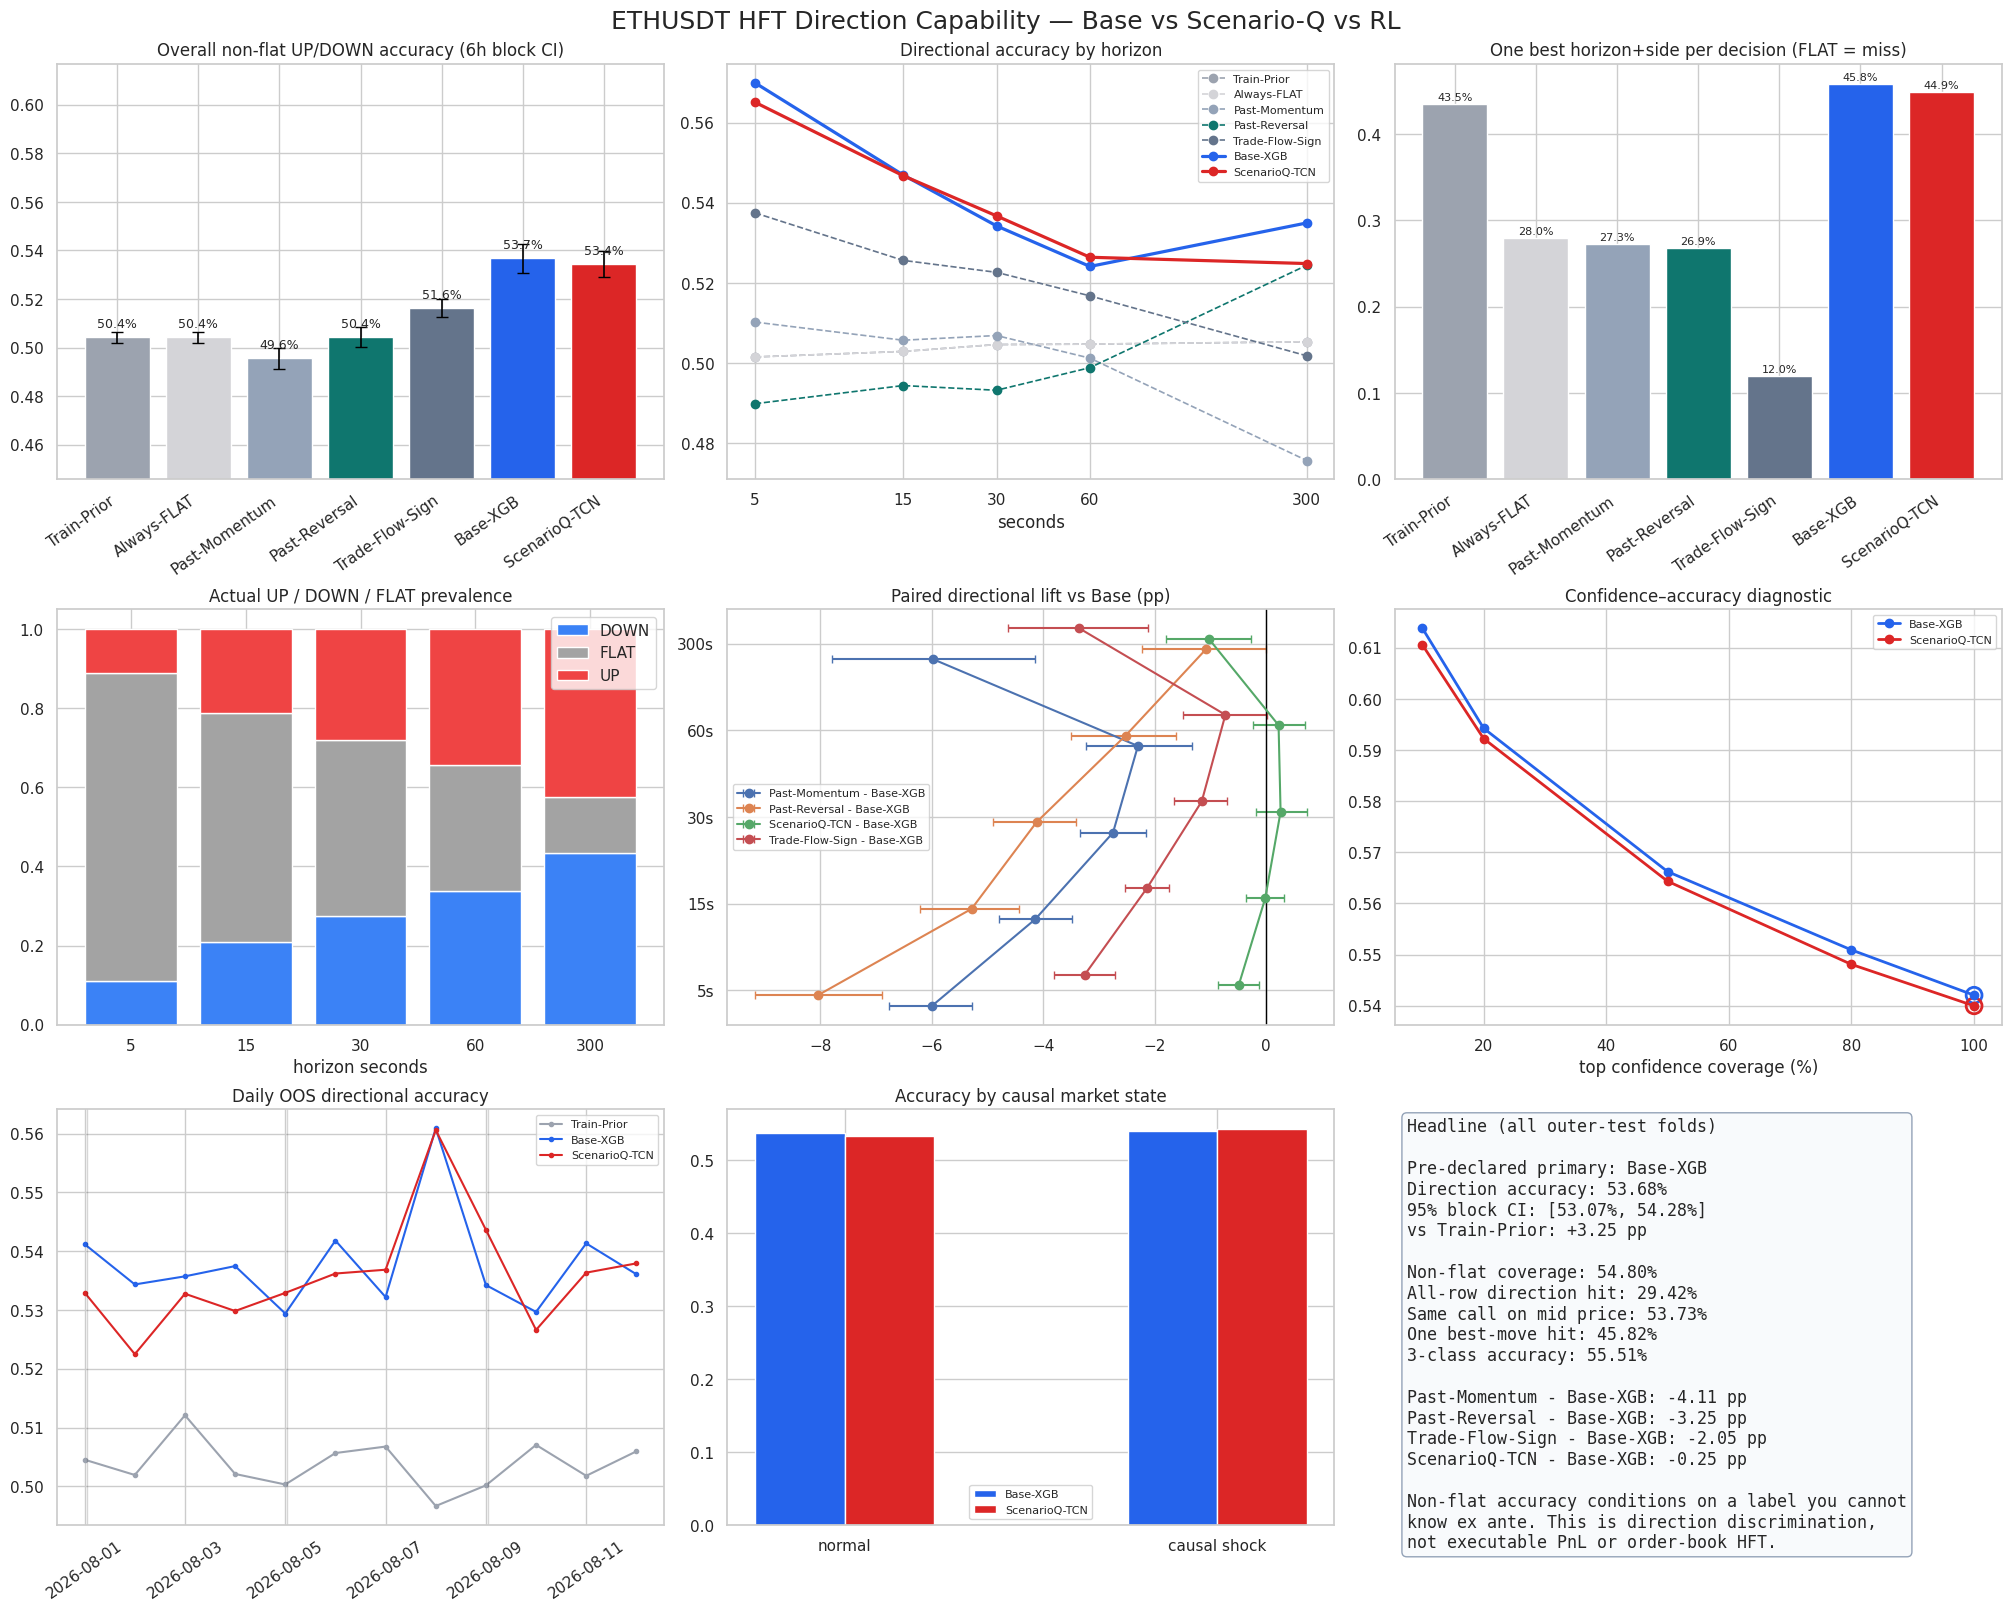

In [ ]:
COLORS = {
    "Train-Prior": "#9ca3af", "Always-FLAT": "#d4d4d8", "Past-Momentum": "#94a3b8",
    "Past-Reversal": "#0f766e", "Trade-Flow-Sign": "#64748b",
    "Base-XGB": "#2563eb", "ScenarioQ-MLP": "#f59e0b", "ScenarioQ-TCN": "#dc2626",
    "RL-DDQN-SMDP": "#7c3aed",
}
PRIMARY_MODELS = [name for name in [
    "Base-XGB", "ScenarioQ-MLP", "ScenarioQ-TCN", "RL-DDQN-SMDP",
] if name in MODEL_ORDER]

fig, axes = plt.subplots(3, 3, figsize=(20, 16), constrained_layout=True)

# 1. Headline directional accuracy + block CI
ax = axes[0, 0]
ordered_head = HEADLINE.set_index("model").loc[MODEL_ORDER].reset_index()
x = np.arange(len(ordered_head))
y = ordered_head.direction_accuracy.to_numpy()
yerr = np.maximum(0, np.vstack([
    y - ordered_head.direction_ci_low.to_numpy(), ordered_head.direction_ci_high.to_numpy() - y
]))
ax.bar(x, y, color=[COLORS[m] for m in ordered_head.model])
ax.errorbar(x, y, yerr=yerr, fmt="none", color="black", capsize=4, lw=1.2)
for i, value in enumerate(y): ax.text(i, value + 0.004, f"{value:.1%}", ha="center", fontsize=9)
ax.set_xticks(x, ordered_head.model, rotation=35, ha="right")
ax.set_ylim(max(0.35, y.min() - .05), min(1, y.max() + .08))
ax.set_title("Overall non-flat UP/DOWN accuracy (6h block CI)")

# 2. Horizon curves
ax = axes[0, 1]
for model_name in MODEL_ORDER:
    data = METRICS_BY_HORIZON.loc[METRICS_BY_HORIZON.model.eq(model_name)]
    ax.plot(data.horizon_seconds, data.direction_accuracy, marker="o",
            lw=2.3 if model_name in PRIMARY_MODELS else 1.2,
            ls="-" if model_name in PRIMARY_MODELS else "--",
            color=COLORS[model_name], label=model_name)
ax.set_xscale("log"); ax.set_xticks(HORIZONS, HORIZONS)
ax.set_title("Directional accuracy by horizon"); ax.set_xlabel("seconds"); ax.legend(fontsize=8)

# 3. One selected horizon+side per decision
ax = axes[0, 2]
selected_plot = BEST_MOVE_METRICS.set_index("model").loc[MODEL_ORDER].reset_index()
ax.bar(np.arange(len(selected_plot)), selected_plot.selected_scenario_accuracy,
       color=[COLORS[name] for name in selected_plot.model])
for i, value in enumerate(selected_plot.selected_scenario_accuracy):
    ax.text(i, value + .004, f"{value:.1%}", ha="center", fontsize=8)
ax.set_xticks(np.arange(len(selected_plot)), selected_plot.model, rotation=35, ha="right")
ax.set_title("One best horizon+side per decision (FLAT = miss)")

# 4. Actual class prevalence
ax = axes[1, 0]
prevalence_plot = METRICS_BY_HORIZON.loc[METRICS_BY_HORIZON.model.eq("Base-XGB")].set_index("horizon_seconds")
bottom = np.zeros(len(prevalence_plot))
for label, column, color in [("DOWN", "down_prevalence", "#3b82f6"), ("FLAT", "flat_prevalence", "#a3a3a3"), ("UP", "up_prevalence", "#ef4444")]:
    values = prevalence_plot[column].to_numpy()
    ax.bar(np.arange(len(values)), values, bottom=bottom, label=label, color=color); bottom += values
ax.set_xticks(np.arange(len(prevalence_plot)), prevalence_plot.index)
ax.set_title("Actual UP / DOWN / FLAT prevalence"); ax.set_xlabel("horizon seconds"); ax.legend()

# 5. Paired differences
ax = axes[1, 1]
diff_plot = PAIRED_DIFFERENCES.copy()
diff_plot = diff_plot.loc[diff_plot.horizon_seconds.ne("overall")]
comparison_groups = list(diff_plot.groupby("comparison", observed=True))
comparison_offsets = np.linspace(-0.18, 0.18, max(len(comparison_groups), 1))
for offset, (comparison, data) in zip(comparison_offsets, comparison_groups):
    data = data.sort_values("horizon_seconds")
    ax.errorbar(
        data.mean_difference_pp, np.arange(len(data)) + offset,
        xerr=np.vstack([data.mean_difference_pp - data.ci_low_pp, data.ci_high_pp - data.mean_difference_pp]),
        marker="o", capsize=3, label=comparison,
    )
ax.axvline(0, color="black", lw=1)
ax.set_yticks(np.arange(len(HORIZONS)), [f"{h}s" for h in HORIZONS])
ax.set_title("Paired directional lift vs Base (pp)"); ax.legend(fontsize=8)

# 6. Confidence diagnostic, averaged equally over horizons
ax = axes[1, 2]
curve_plot = CONFIDENCE_CURVE.groupby(["model", "coverage"], observed=True).accuracy.mean().reset_index()
for model_name in PRIMARY_MODELS:
    data = curve_plot.loc[curve_plot.model.eq(model_name)].sort_values("coverage")
    ax.plot(100 * data.coverage, data.accuracy, marker="o", lw=2, color=COLORS[model_name], label=model_name)
    full = data.loc[data.coverage.eq(1.0)]
    if len(full): ax.scatter([100], full.accuracy, s=130, facecolors="none", edgecolors=COLORS[model_name], lw=2)
ax.set_title("Confidence–accuracy diagnostic"); ax.set_xlabel("top confidence coverage (%)"); ax.legend(fontsize=8)

# 7. Daily stability
ax = axes[2, 0]
for model_name in [name for name in ["Train-Prior", *PRIMARY_MODELS] if name in MODEL_ORDER]:
    data = ROLLING_DAILY.loc[ROLLING_DAILY.model.eq(model_name)]
    ax.plot(data.utc_day, data.accuracy, marker=".", lw=1.5, color=COLORS[model_name], label=model_name)
for fold in FOLDS: ax.axvline(fold["test_start"], color="black", alpha=.16, lw=1)
ax.set_title("Daily OOS directional accuracy"); ax.tick_params(axis="x", rotation=35); ax.legend(fontsize=8)

# 8. Normal vs causal shock state
ax = axes[2, 1]
shock_plot = SHOCK_METRICS.groupby(["model", "shock_flag"], observed=True).apply(
    lambda g: np.average(g.accuracy, weights=g.n)
).rename("accuracy").reset_index()
width = min(.24, .78 / max(len(PRIMARY_MODELS), 1)); locations = np.arange(2)
for j, model_name in enumerate(PRIMARY_MODELS):
    data = shock_plot.loc[shock_plot.model.eq(model_name)].set_index("shock_flag").reindex([False, True])
    ax.bar(locations + (j - (len(PRIMARY_MODELS)-1)/2)*width, data.accuracy, width, color=COLORS[model_name], label=model_name)
ax.set_xticks(locations, ["normal", "causal shock"]); ax.set_title("Accuracy by causal market state"); ax.legend(fontsize=8)

# 9. Interpretation card
# J (review 3.3): the card reports the *pre-declared* incumbent, never the argmax
# of outer-test accuracy.  Challengers appear only as paired differences.
ax = axes[2, 2]; ax.axis("off")
base = HEADLINE.loc[HEADLINE.model.eq("Base-XGB")].iloc[0]
overall_differences = PAIRED_DIFFERENCES.loc[PAIRED_DIFFERENCES.horizon_seconds.eq("overall")]
challenger_lines = "".join(
    f"{row.comparison}: {row.mean_difference_pp:+.2f} pp\n"
    for _, row in overall_differences.iterrows()
)
base_move_value = BEST_MOVE_METRICS.set_index("model").loc["Base-XGB", "selected_scenario_accuracy"]
mid_accuracy = float(METRICS_OVERALL.set_index("model").loc["Base-XGB", "mid_direction_accuracy"])
card = (
    f"Headline (all outer-test folds)\n\n"
    f"Pre-declared primary: Base-XGB\n"
    f"Direction accuracy: {base.direction_accuracy:.2%}\n"
    f"95% block CI: [{base.direction_ci_low:.2%}, {base.direction_ci_high:.2%}]\n"
    f"vs Train-Prior: {base.direction_lift_vs_train_prior_pp:+.2f} pp\n\n"
    f"Non-flat coverage: {base.nonflat_coverage:.2%}\n"
    f"All-row direction hit: {base.unconditional_direction_hit:.2%}\n"
    f"Same call on mid price: {mid_accuracy:.2%}\n"
    f"One best-move hit: {base_move_value:.2%}\n"
    f"3-class accuracy: {base.class3_accuracy:.2%}\n\n"
    f"{challenger_lines}\n"
    "Non-flat accuracy conditions on a label you cannot\nknow ex ante. This is direction discrimination,\nnot executable PnL or order-book HFT."
)
ax.text(.02, .98, card, va="top", family="monospace", fontsize=12,
        bbox=dict(boxstyle="round", facecolor="#f8fafc", edgecolor="#94a3b8"))

fig.suptitle("ETHUSDT HFT Direction Capability — Base vs Scenario-Q vs RL", fontsize=18)
fig.savefig(OUTPUT / "hft_direction_dashboard.png", dpi=170, bbox_inches="tight")
plt.show()

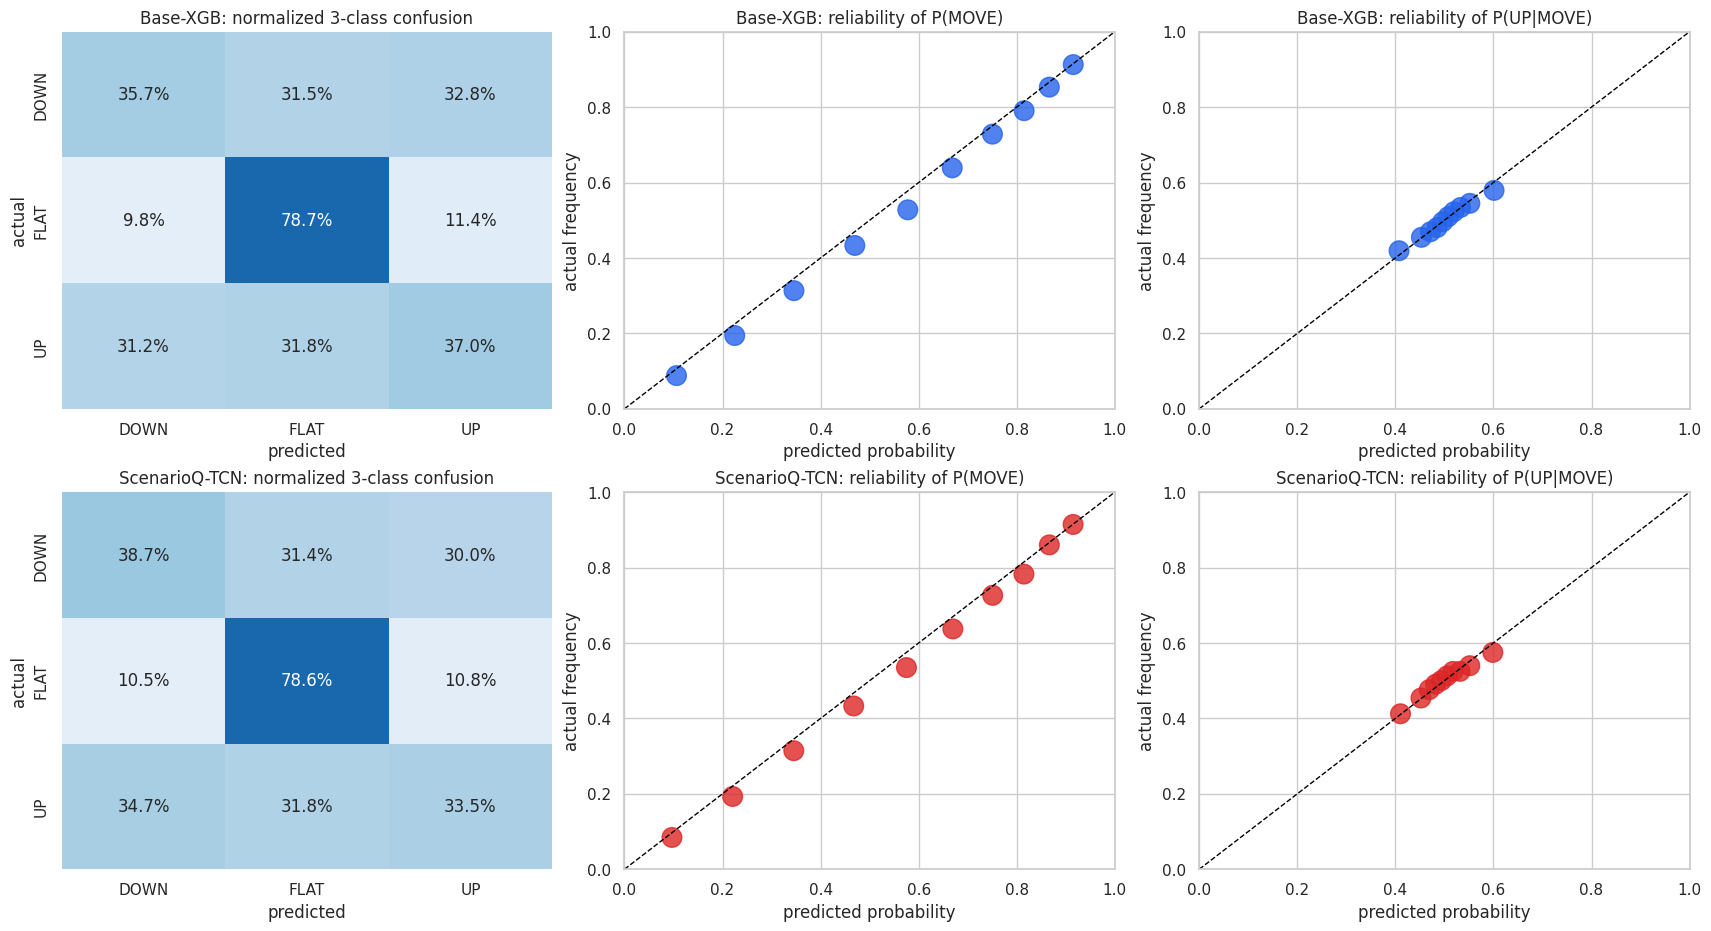

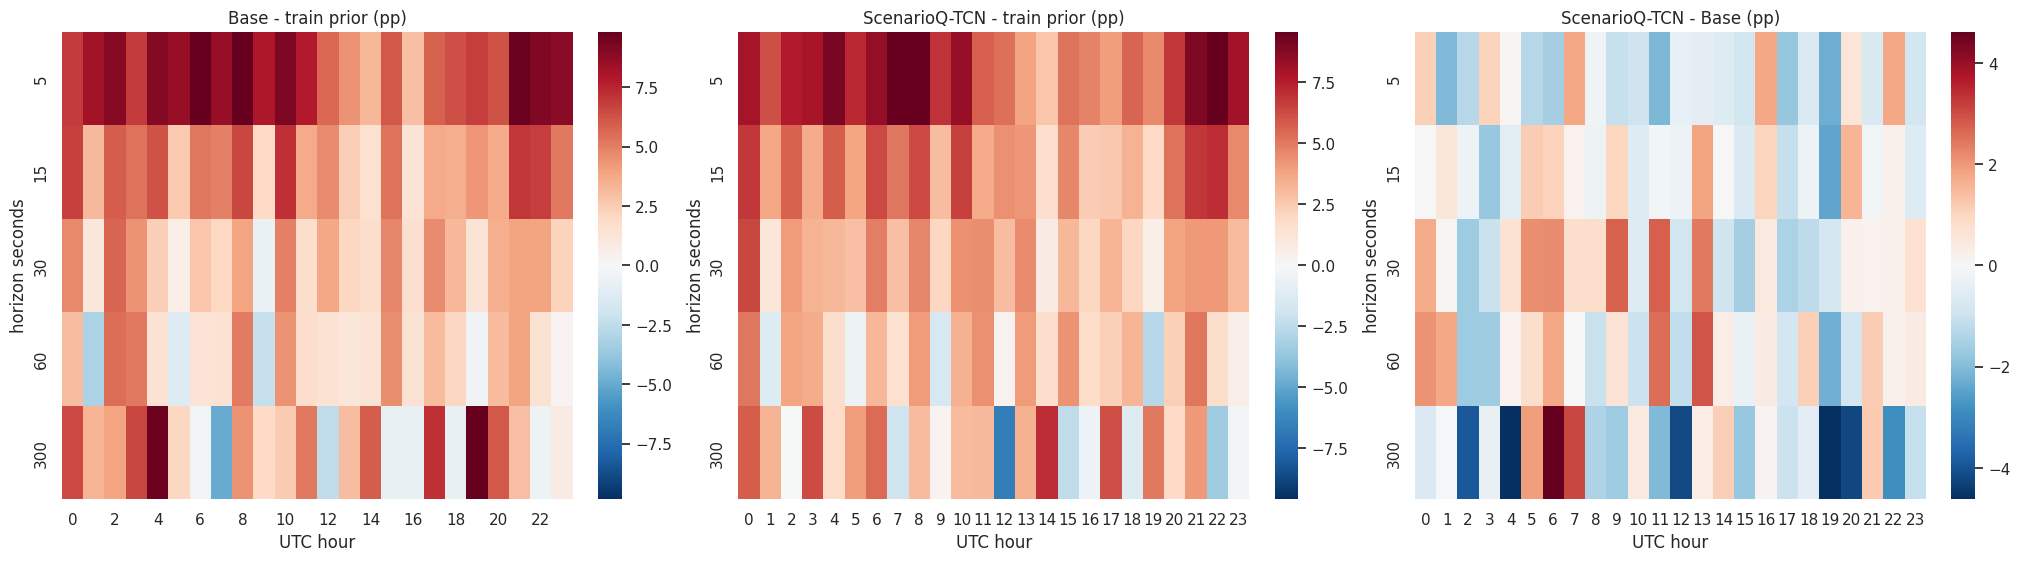

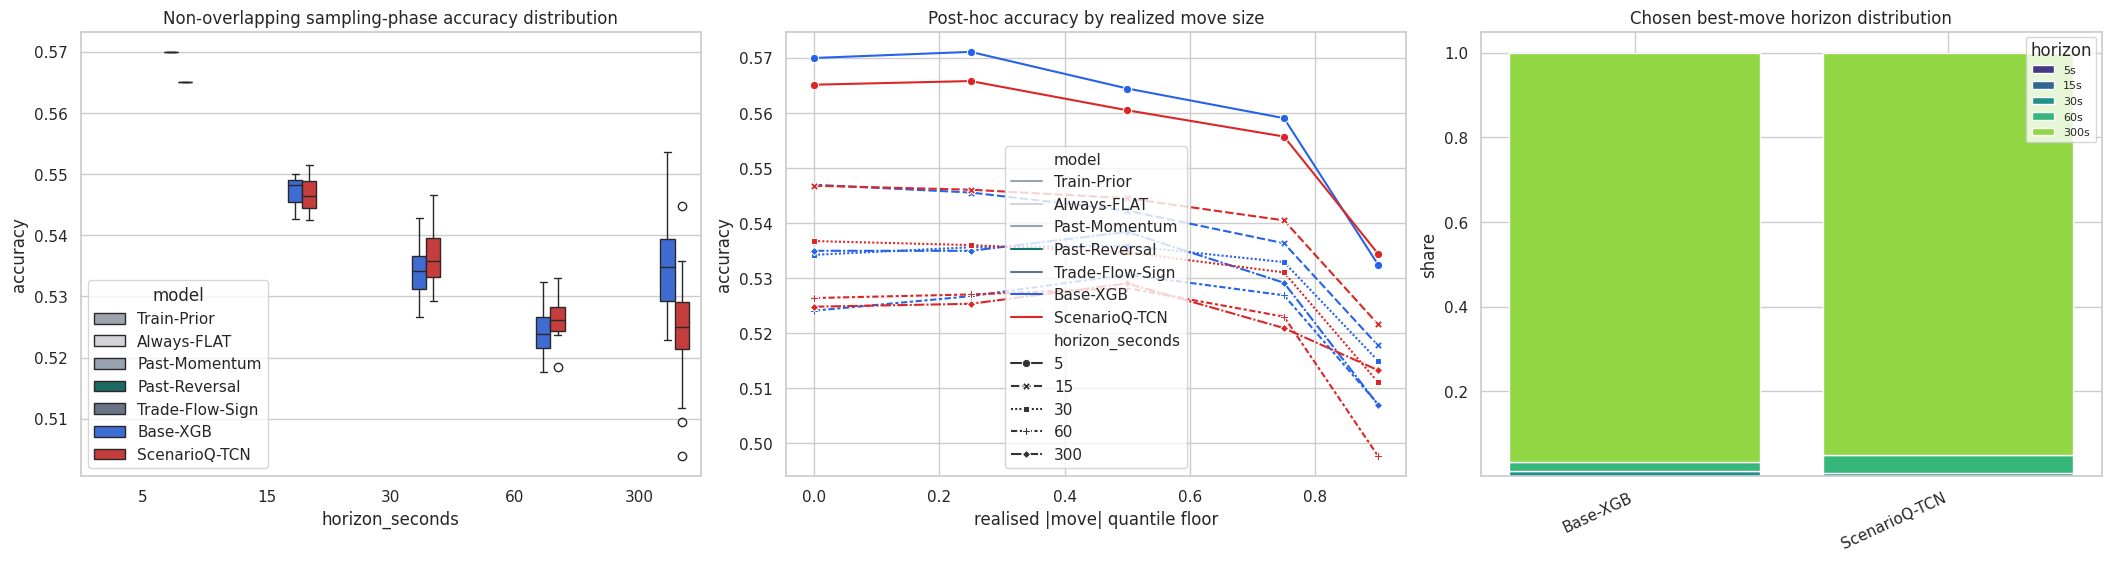

In [ ]:
fig, axes = plt.subplots(len(PRIMARY_MODELS), 3, figsize=(17, 4.6 * len(PRIMARY_MODELS)), squeeze=False, constrained_layout=True)
for row, model_name in enumerate(PRIMARY_MODELS):
    frame = OOS.loc[OOS.model.eq(model_name)]
    matrix = confusion_matrix(frame.actual_class, frame.predicted_class, labels=[DOWN, FLAT, UP], normalize="true")
    sns.heatmap(matrix, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[row, 0], cbar=False)
    axes[row, 0].set_title(f"{model_name}: normalized 3-class confusion")
    axes[row, 0].set_xlabel("predicted"); axes[row, 0].set_ylabel("actual")

    for col, target in [(1, "MOVE"), (2, "UP|MOVE")]:
        data = CALIBRATION_BINS.loc[(CALIBRATION_BINS.model.eq(model_name)) & (CALIBRATION_BINS.target.eq(target))]
        axes[row, col].plot([0, 1], [0, 1], color="black", ls="--", lw=1)
        size = 25 + 175 * data.n / max(data.n.max(), 1)
        axes[row, col].scatter(data.mean_probability, data.actual_rate, s=size, alpha=.8, color=COLORS[model_name])
        axes[row, col].set_xlim(0, 1); axes[row, col].set_ylim(0, 1)
        axes[row, col].set_xlabel("predicted probability"); axes[row, col].set_ylabel("actual frequency")
        axes[row, col].set_title(f"{model_name}: reliability of P({target})")
fig.savefig(OUTPUT / "hft_calibration_confusion.png", dpi=170, bbox_inches="tight")
plt.show()


base_hour = HOUR_METRICS.loc[HOUR_METRICS.model.eq("Base-XGB")].pivot(index="horizon_seconds", columns="utc_hour", values="accuracy")
tcn_hour = HOUR_METRICS.loc[HOUR_METRICS.model.eq("ScenarioQ-TCN")].pivot(index="horizon_seconds", columns="utc_hour", values="accuracy")
prior_hour = HOUR_METRICS.loc[HOUR_METRICS.model.eq("Train-Prior")].pivot(index="horizon_seconds", columns="utc_hour", values="accuracy")
heatmap_specs = [
    (100 * (base_hour - prior_hour), "Base - train prior (pp)"),
    (100 * (tcn_hour - prior_hour), "ScenarioQ-TCN - train prior (pp)"),
    (100 * (tcn_hour - base_hour), "ScenarioQ-TCN - Base (pp)"),
]
if "RL-DDQN-SMDP" in MODEL_ORDER:
    rl_hour = HOUR_METRICS.loc[HOUR_METRICS.model.eq("RL-DDQN-SMDP")].pivot(
        index="horizon_seconds", columns="utc_hour", values="accuracy"
    )
    heatmap_specs.append((100 * (rl_hour - base_hour), "RL-DDQN-SMDP - Base (pp)"))
fig, axes = plt.subplots(1, len(heatmap_specs), figsize=(6.7 * len(heatmap_specs), 5.5), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (data, title) in zip(axes, heatmap_specs):
    limit = max(0.5, float(np.nanquantile(np.abs(data.to_numpy()), .98)))
    sns.heatmap(data, cmap="RdBu_r", center=0, vmin=-limit, vmax=limit, ax=ax)
    ax.set_title(title); ax.set_xlabel("UTC hour"); ax.set_ylabel("horizon seconds")
fig.savefig(OUTPUT / "hft_horizon_utc_heatmaps.png", dpi=170, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(21, 5.5), constrained_layout=True)
sns.boxplot(
    data=PHASE_METRICS.loc[PHASE_METRICS.model.isin(PRIMARY_MODELS)],
    x="horizon_seconds", y="accuracy", hue="model", palette=COLORS, ax=axes[0],
)
axes[0].set_title("Non-overlapping sampling-phase accuracy distribution")
sns.lineplot(
    data=MOVE_SENSITIVITY.loc[MOVE_SENSITIVITY.model.isin(PRIMARY_MODELS)],
    x="move_quantile", y="accuracy", hue="model", style="horizon_seconds",
    palette=COLORS, markers=True, ax=axes[1],
)
axes[1].set_title("Post-hoc accuracy by realized move size")
axes[1].set_xlabel("realised |move| quantile floor")
distribution = BEST_MOVE_DISTRIBUTION.loc[BEST_MOVE_DISTRIBUTION.model.isin(PRIMARY_MODELS)].pivot(
    index="model", columns="horizon_seconds", values="share"
).fillna(0).reindex(PRIMARY_MODELS)
bottom = np.zeros(len(distribution))
palette = sns.color_palette("viridis", n_colors=len(distribution.columns))
for color, horizon in zip(palette, distribution.columns):
    values = distribution[horizon].to_numpy()
    axes[2].bar(np.arange(len(distribution)), values, bottom=bottom, color=color, label=f"{horizon}s")
    bottom += values
axes[2].set_xticks(np.arange(len(distribution)), distribution.index, rotation=25, ha="right")
axes[2].set_title("Chosen best-move horizon distribution")
axes[2].set_ylabel("share"); axes[2].legend(title="horizon", fontsize=8)
fig.savefig(OUTPUT / "hft_robustness_diagnostics.png", dpi=170, bbox_inches="tight")
plt.show()


if len(RL_LEARNING_CURVES):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)
    for fold_id, data in RL_LEARNING_CURVES.groupby("fold", observed=True):
        data = data.sort_values("update")
        axes[0].plot(data["update"], data.td_loss, marker="o", label=f"replay f{fold_id}")
        axes[0].plot(data["update"], data.validation_bellman_loss, marker="x", ls="--", label=f"validation f{fold_id}")
        axes[1].plot(data["update"], data.validation_fixed_direction_accuracy, marker="o", label=f"fixed keys f{fold_id}")
        axes[1].plot(data["update"], data.validation_policy_accuracy, marker="x", ls="--", label=f"native path f{fold_id}")
    axes[0].set_title("Double-DQN replay vs fixed validation Bellman loss"); axes[0].set_xlabel("optimizer update")
    axes[0].set_ylabel("Huber TD loss"); axes[0].legend()
    axes[1].set_title("Validation direction accuracy"); axes[1].set_xlabel("optimizer update")
    axes[1].set_ylabel("accuracy on actual non-flat rows"); axes[1].legend()
    native_distribution = RL_NATIVE_POLICY_ROWS.horizon_seconds.value_counts(normalize=True).sort_index()
    axes[2].bar(native_distribution.index.astype(str), native_distribution.values, color=COLORS["RL-DDQN-SMDP"])
    axes[2].set_title("Native RL selected-horizon distribution")
    axes[2].set_xlabel("chosen horizon seconds"); axes[2].set_ylabel("path share")
    fig.suptitle("RL training and native sequential-policy diagnostics", fontsize=16)
    fig.savefig(OUTPUT / "hft_rl_ddqn_diagnostics.png", dpi=170, bbox_inches="tight")
    plt.show()

## 12. 자동 선택된 OOS 가격 경로와 scenario map

보기 좋은 사례를 수동으로 고르지 않는다. 30초 horizon(없으면 중앙 horizon)에서 아래 네 그룹의 **중앙 confidence** 표본을 자동 선택한다.

- 둘 다 정답
- 둘 다 오답
- Base만 정답
- ScenarioQ-TCN만 정답

개별 경로는 설명용이며 공식 정확도 계산에는 전혀 영향을 주지 않는다.

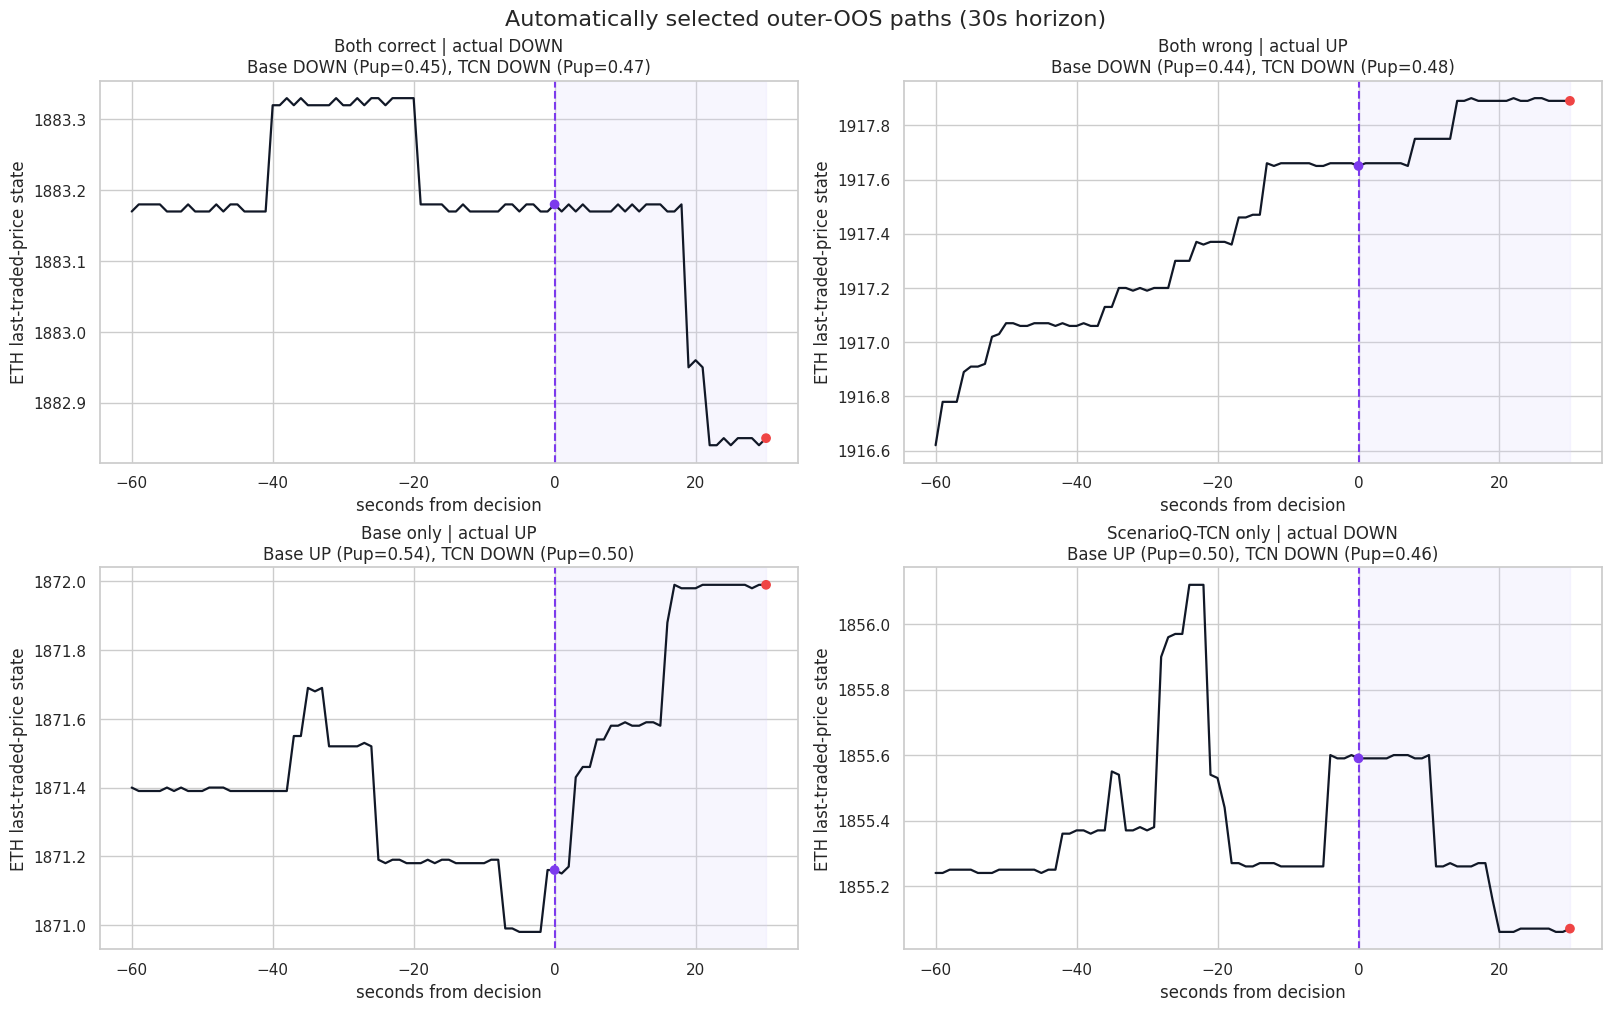

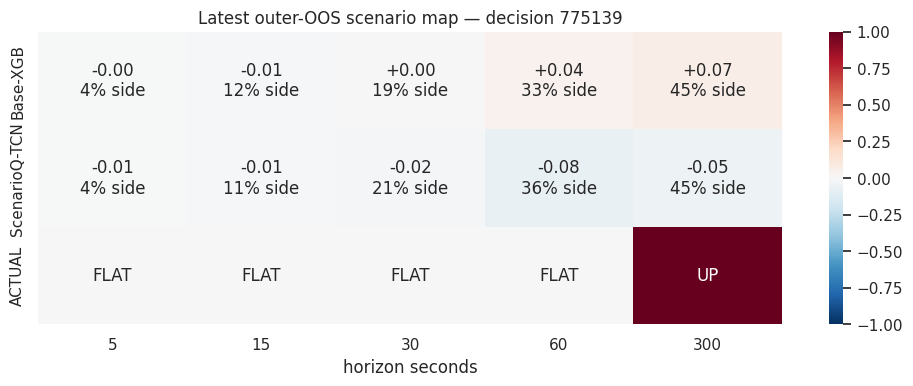

In [ ]:
example_horizon = 30 if 30 in HORIZONS else int(HORIZONS[len(HORIZONS) // 2])
base_example = OOS.loc[(OOS.model.eq("Base-XGB")) & (OOS.horizon_seconds.eq(example_horizon)) & OOS.nonflat, [
    "fold", "decision_id", "position", "information_end", "actual_class",
    "forced_direction", "direction_correct", "direction_confidence", "p_up_given_move",
]].rename(columns={
    "forced_direction": "base_direction", "direction_correct": "base_correct",
    "direction_confidence": "base_confidence", "p_up_given_move": "base_p_up",
})
tcn_example = OOS.loc[(OOS.model.eq("ScenarioQ-TCN")) & (OOS.horizon_seconds.eq(example_horizon)) & OOS.nonflat, [
    "fold", "decision_id", "forced_direction", "direction_correct", "direction_confidence", "p_up_given_move",
]].rename(columns={
    "forced_direction": "tcn_direction", "direction_correct": "tcn_correct",
    "direction_confidence": "tcn_confidence", "p_up_given_move": "tcn_p_up",
})
examples = base_example.merge(tcn_example, on=["fold", "decision_id"], validate="one_to_one")
examples["mean_confidence"] = (examples.base_confidence + examples.tcn_confidence) / 2
conditions = {
    "Both correct": examples.base_correct & examples.tcn_correct,
    "Both wrong": (~examples.base_correct) & (~examples.tcn_correct),
    "Base only": examples.base_correct & (~examples.tcn_correct),
    "ScenarioQ-TCN only": (~examples.base_correct) & examples.tcn_correct,
}


def median_confidence_row(frame):
    if frame.empty:
        return None
    target = frame.mean_confidence.median()
    return frame.iloc[int(np.argmin(np.abs(frame.mean_confidence.to_numpy() - target)))]


chosen_examples = {name: median_confidence_row(examples.loc[mask]) for name, mask in conditions.items()}
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
history_seconds = min(60, CFG.lookback_seconds - 1)
for ax, (category, row) in zip(axes.ravel(), chosen_examples.items()):
    if row is None:
        ax.axis("off"); ax.text(.5, .5, f"{category}\n(no OOS sample)", ha="center", va="center"); continue
    position = int(row.position)
    start = max(0, position - history_seconds)
    end = min(CLOCK_LENGTH - 1, position + example_horizon)
    rel = np.arange(start, end + 1) - position
    price = ETH_PRICE_PATH[start:end + 1]
    ax.plot(rel, price, color="#111827", lw=1.6)
    ax.axvline(0, color="#7c3aed", ls="--", lw=1.5, label="decision")
    ax.axvspan(0, example_horizon, color="#ddd6fe", alpha=.22)
    actual_name = CLASS_NAMES[int(row.actual_class)]
    base_name = CLASS_NAMES[int(row.base_direction)]
    tcn_name = CLASS_NAMES[int(row.tcn_direction)]
    ax.scatter([0, example_horizon], [price[position-start], price[-1]], color=["#7c3aed", "#ef4444"], zorder=3)
    ax.set_title(
        f"{category} | actual {actual_name}\n"
        f"Base {base_name} (Pup={row.base_p_up:.2f}), TCN {tcn_name} (Pup={row.tcn_p_up:.2f})"
    )
    ax.set_xlabel("seconds from decision"); ax.set_ylabel("ETH last-traded-price state")
fig.suptitle(f"Automatically selected outer-OOS paths ({example_horizon}s horizon)", fontsize=16)
fig.savefig(OUTPUT / "hft_oos_example_paths.png", dpi=170, bbox_inches="tight")
plt.show()


latest_decision = int(OOS.decision_id.max())
scenario_models = [name for name in [
    "Base-XGB", "ScenarioQ-MLP", "ScenarioQ-TCN", "RL-DDQN-SMDP",
] if name in PRIMARY_MODELS]
latest = OOS.loc[OOS.decision_id.eq(latest_decision) & OOS.model.isin(scenario_models)].copy()
latest["direction_score"] = latest.p_up - latest.p_down
score_map = latest.pivot(index="model", columns="horizon_seconds", values="direction_score").reindex(scenario_models)
actual_map = latest.drop_duplicates("horizon_seconds").set_index("horizon_seconds").actual_class.reindex(HORIZONS)
actual_score = actual_map.map({DOWN: -1.0, FLAT: 0.0, UP: 1.0}).to_numpy()[None, :]
plot_map = pd.concat([score_map, pd.DataFrame(actual_score, index=["ACTUAL"], columns=HORIZONS)])
annotation = plot_map.copy().astype(object)
for model_name in scenario_models:
    rows = latest.loc[latest.model.eq(model_name)].set_index("horizon_seconds")
    annotation.loc[model_name] = [
        f"{plot_map.loc[model_name, h]:+.2f}\n{max(rows.loc[h, 'p_up'], rows.loc[h, 'p_down']):.0%} side"
        for h in HORIZONS
    ]
annotation.loc["ACTUAL"] = [CLASS_NAMES[int(actual_map.loc[h])] for h in HORIZONS]
fig, ax = plt.subplots(figsize=(12, 3.8))
sns.heatmap(plot_map, annot=annotation, fmt="", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title(f"Latest outer-OOS scenario map — decision {latest_decision}")
ax.set_xlabel("horizon seconds"); ax.set_ylabel("")
fig.savefig(OUTPUT / "hft_latest_scenario_map.png", dpi=180, bbox_inches="tight")
plt.show()

## 13. 거래비용 포함 research PnL proxy

보고서 권고에 따라 헤드라인 순서를 바꿨다. 정확도가 아니라 다음 순서로 읽는다.

1. **Break-even 왕복비용** — 각 전략의 net PnL이 0이 되는 비용. 가장 해석하기 쉬운 단일 숫자다.
2. **Net PnL per turnover** — "정확도 극대화"가 아니라 이쪽이 다음 버전의 목적함수여야 한다.
3. **DP oracle 대비 regret** — 모든 정책이 regret 100% 근처면 한계는 학습기가 아니라 **state**다.
4. **위험 지표** — 일별 Sharpe/Sortino, MDD, 최악의 날/6시간 블록, 블록 CVaR 5%.
5. **trade price vs 틱룰 mid** — 같은 의사결정을 두 가격으로 평가한 격차 = 바운스 오염.
6. **Edge decile 신뢰도** — 예측 edge가 높은 구간에서 실현수익이 실제로 단조 증가하는가.
7. **Seed·γ 분산** — 단일 seed 결과가 만들어내던 착시의 크기.

`Always-Flat`, `Always-Long`, `Always-Short`가 모두 표에 있으므로 이제 "전략이 드리프트/캐리 대비
무언가를 했는가"를 처음으로 판정할 수 있다.


Outer-test research P&L at the assumed 8.00 bp round trip
`break_even_round_trip_bps` is the cost at which each strategy's net P&L reaches zero.


,strategy,decisions,net_pnl_bps,gross_pnl_bps,transaction_cost_bps,funding_bps,inventory_penalty_bps,mean_net_bps_per_decision,net_pnl_per_turnover_bps,break_even_round_trip_bps,time_in_market,turnover_units,position_changes,active_direction_hit,max_drawdown_bps,daily_sharpe_annualized,daily_sortino_annualized,worst_day_bps,worst_block_bps,cvar5_block_bps
5,DP-Oracle-Hindsight,204082,"+30,510.7","+54,019.2","23,480.0",28.4,0.0,+0.1495,+5.1977,+18.395,80.22%,"5,870",3632,46.90%,-8.0,+42.00,+nan,+283.9,+33.5,+42.9
10,QR-DDQN-CVaR,204082,+358.5,+572.7,208.0,6.2,0.0,+0.0018,+6.8933,+21.787,17.59%,52,52,40.84%,-154.2,+10.71,+41.98,-30.2,-94.6,-60.0
0,Always-Flat,204082,+0.0,+0.0,0.0,0.0,0.0,+0.0000,+nan,+nan,0.00%,0,0,nan%,+0.0,+nan,+nan,+0.0,+0.0,+0.0
6,EdgeThreshold,204082,+0.0,+0.0,0.0,0.0,0.0,+0.0000,+nan,+nan,0.00%,0,0,nan%,+0.0,+nan,+nan,+0.0,+0.0,+0.0
4,CostAware-Hybrid,204082,+0.0,+0.0,0.0,0.0,0.0,+0.0000,+nan,+nan,0.00%,0,0,nan%,+0.0,+nan,+nan,+0.0,+0.0,+0.0
7,Hysteresis,204082,-4.3,+3.8,8.0,0.0,0.0,-0.0000,-2.1260,+3.748,0.01%,2,2,26.32%,-25.0,-5.52,+nan,-4.3,-4.3,-1.4
9,PnL-DDQN,204082,-604.2,+20.9,616.0,9.1,0.0,-0.0030,-3.9232,+0.154,25.70%,154,152,41.17%,-634.5,-9.62,-10.84,-284.6,-125.9,-104.6
8,OneStep-MPC,204082,"-2,192.3",+10.9,"2,200.0",3.2,0.0,-0.0107,-3.9859,+0.028,9.09%,550,539,26.31%,"-2,213.0",-6.34,-3.02,"-1,913.1",-726.5,-560.3
1,Always-Long,204082,"-6,810.4",+97.0,"6,872.0",35.4,0.0,-0.0334,-3.9642,+0.072,100.00%,"1,718",1694,36.47%,"-6,827.7",-17.63,-18.03,"-1,860.8",-787.0,-669.8
2,Always-Short,204082,"-7,004.4",-97.0,"6,872.0",35.4,0.0,-0.0343,-4.0771,-0.154,100.00%,"1,718",1694,35.18%,"-7,106.1",-19.17,-19.36,"-1,913.1",-726.5,-606.2


Same decisions, trade price vs tick-rule mid (review 4.2). A large positive gap means the trade-price P&L is capturing bid-ask bounce that is not executable.


,strategy,net_pnl_bps_trade,break_even_round_trip_bps_trade,net_pnl_bps_mid,break_even_round_trip_bps_mid,net_pnl_gap_bps
9,QR-DDQN-CVaR,+358.5,+21.787,+358.7,+21.795,-0.2
4,CostAware-Hybrid,+0.0,+nan,+0.0,+nan,+0.0
0,Always-Flat,+0.0,+nan,+0.0,+nan,+0.0
5,EdgeThreshold,+0.0,+nan,+0.0,+nan,+0.0
6,Hysteresis,-4.3,+3.748,-4.3,+3.748,+0.0
8,PnL-DDQN,-604.2,+0.154,-604.2,+0.154,-0.0
7,OneStep-MPC,"-2,192.3",+0.028,"-2,192.0",+0.029,-0.3
1,Always-Long,"-6,810.4",+0.072,"-6,810.1",+0.072,-0.3
2,Always-Short,"-7,004.4",-0.154,"-7,004.7",-0.155,+0.3
10,ScenarioQ-TCN-5s,"-625,439.8",+0.186,"-624,522.6",+0.197,-917.2


Regret against the exact DP switching oracle (hindsight ceiling, not a strategy).
If every learned policy sits near 100% regret, the limitation is the state, not the learner.


...

,edge_decile,n,mean_predicted_edge_bps,mean_realized_bps,traded_share,mean_net_pnl_bps,realized_minus_predicted_bps
0,0,20409,-0.1793,-0.2227,0.0%,+0.0000,-0.0434
1,1,20408,-0.0579,-0.0833,0.0%,+0.0000,-0.0254
2,2,20408,-0.0325,-0.0556,0.0%,+0.0000,-0.0231
3,3,20408,-0.0177,-0.0253,0.0%,+0.0000,-0.0076
4,4,20408,-0.0045,-0.0083,0.0%,+0.0000,-0.0038
5,5,20408,+0.0098,+0.0093,0.0%,+0.0000,-0.0005
6,6,20408,+0.0249,+0.0196,0.0%,+0.0000,-0.0053
7,7,20408,+0.0451,+0.0622,0.0%,+0.0000,+0.0171
8,8,20408,+0.0824,+0.0962,0.0%,+0.0000,+0.0138
9,9,20409,+0.1963,+0.2126,0.0%,+0.0000,+0.0163


Seed and discount dispersion on policy_validation (review 3.4 / research P0-P1).
V1 reported one seed at gamma=0.99; the min-max column is the size of that illusion.


,kind,fold,gamma,seeds,score_median,score_min,score_max,validation_pnl_median,validation_pnl_min,validation_pnl_max
0,mean,0,0.900000,2,-27.7,-33.9,-21.4,+202.2,+186.6,+217.8
1,mean,0,0.950000,2,+42.1,+17.2,+67.0,+328.1,+318.8,+337.4
2,mean,0,0.970000,2,+28.1,-68.1,+124.3,+306.4,+146.6,+466.1
3,mean,0,0.990000,5,+40.3,-3.8,+105.3,+157.8,+140.3,+442.6
4,mean,1,0.900000,2,-18.0,-20.8,-15.2,+168.2,+163.0,+173.4
5,mean,1,0.950000,2,+33.8,+28.6,+39.1,+231.9,+216.4,+247.4
6,mean,1,0.970000,5,+46.2,-30.9,+100.1,+208.6,+72.6,+261.9
7,mean,1,0.990000,2,-80.8,-93.0,-68.6,+96.0,+70.8,+121.2
8,mean,2,0.900000,2,-1.1,-1.1,-1.1,+8.8,+8.8,+8.8
9,mean,2,0.950000,2,-0.5,-1.1,+0.0,+4.4,+0.0,+8.8


Base<->TCN gate on the outer test (review 2.2).


,horizon_seconds,gate_p01,gate_median,gate_p99,gate_saturated_share
0,5,0.206,0.360,0.979,6.5%
1,15,0.090,0.334,0.982,3.7%
2,30,0.059,0.332,0.993,3.8%
3,60,0.045,0.350,0.991,4.2%
4,300,0.053,0.398,0.972,4.6%


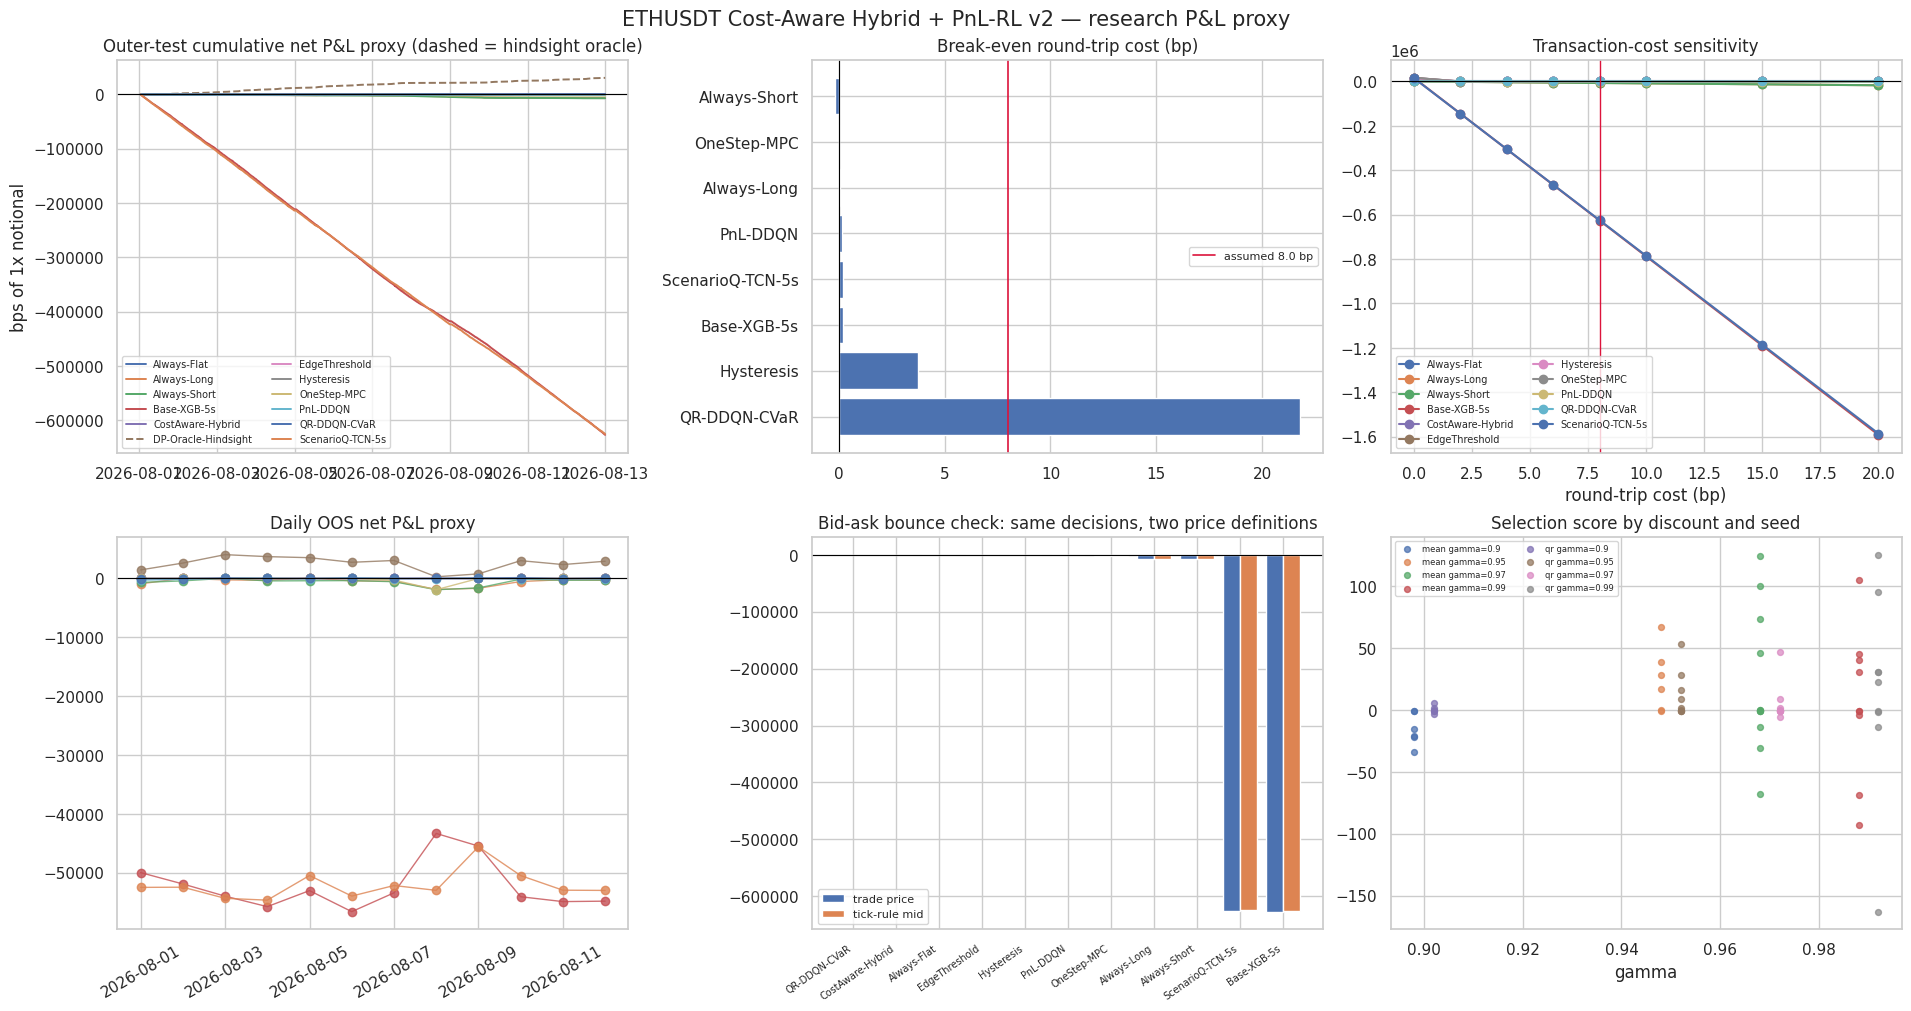

In [ ]:
if len(PNL_POLICY_ROWS):
    for frame in (PNL_POLICY_ROWS, PNL_MID_POLICY_ROWS):
        frame["information_end"] = pd.to_datetime(frame.information_end, utc=True)
    PNL_POLICY_ROWS = PNL_POLICY_ROWS.sort_values(["strategy", "information_end", "fold"]).reset_index(drop=True)
    PNL_MID_POLICY_ROWS = PNL_MID_POLICY_ROWS.sort_values(["strategy", "information_end", "fold"]).reset_index(drop=True)

    PNL_METRICS = summarize_pnl_paths(PNL_POLICY_ROWS, CFG)
    PNL_METRICS_MID = summarize_pnl_paths(PNL_MID_POLICY_ROWS, CFG)
    PNL_METRICS_BY_FOLD = pd.concat([
        summarize_pnl_paths(g, CFG).assign(fold=int(fold_id))
        for fold_id, g in PNL_POLICY_ROWS.groupby("fold", observed=True)
    ], ignore_index=True)
    PNL_DAILY = (
        PNL_POLICY_ROWS.assign(date=PNL_POLICY_ROWS.information_end.dt.floor("D"))
        .groupby(["strategy", "date"], observed=True)
        .agg(net_pnl_bps=("net_pnl_bps", "sum"), gross_pnl_bps=("gross_pnl_bps", "sum"),
             turnover=("turnover", "sum"),
             time_in_market=("target_position", lambda x: float(np.mean(np.asarray(x) != 0))))
        .reset_index()
    )
    COST_SENSITIVITY_AGG = (
        COST_SENSITIVITY.groupby(["strategy", "round_trip_cost_bps"], observed=True)
        .agg(net_pnl_bps=("net_pnl_bps", "sum"), gross_pnl_bps=("gross_pnl_bps", "sum"),
             transaction_cost_bps=("transaction_cost_bps", "sum"),
             turnover_units=("turnover_units", "sum"), decisions=("decisions", "sum"))
        .reset_index()
    ) if len(COST_SENSITIVITY) else pd.DataFrame()

    # The report's recommended headline ordering: net P&L per unit turnover and the
    # break-even cost, not raw accuracy.
    print(f"\nOuter-test research P&L at the assumed {CFG.research_round_trip_cost_bps:.2f} bp round trip")
    print("`break_even_round_trip_bps` is the cost at which each strategy's net P&L reaches zero.")
    display(PNL_METRICS.sort_values("net_pnl_bps", ascending=False).style.format({
        "net_pnl_bps": "{:+,.1f}", "gross_pnl_bps": "{:+,.1f}",
        "transaction_cost_bps": "{:,.1f}", "funding_bps": "{:,.1f}",
        "inventory_penalty_bps": "{:,.1f}",
        "mean_net_bps_per_decision": "{:+.4f}", "net_pnl_per_turnover_bps": "{:+.4f}",
        "break_even_round_trip_bps": "{:+.3f}",
        "time_in_market": "{:.2%}", "active_direction_hit": "{:.2%}",
        "turnover_units": "{:,.0f}", "max_drawdown_bps": "{:+,.1f}",
        "daily_sharpe_annualized": "{:+.2f}", "daily_sortino_annualized": "{:+.2f}",
        "worst_day_bps": "{:+,.1f}", "worst_block_bps": "{:+,.1f}", "cvar5_block_bps": "{:+,.1f}",
    }))

    # K: the identical decisions repriced on the tick-rule mid.
    MID_COMPARISON = PNL_METRICS[["strategy", "net_pnl_bps", "break_even_round_trip_bps"]].merge(
        PNL_METRICS_MID[["strategy", "net_pnl_bps", "break_even_round_trip_bps"]],
        on="strategy", suffixes=("_trade", "_mid"),
    )
    MID_COMPARISON["net_pnl_gap_bps"] = MID_COMPARISON.net_pnl_bps_trade - MID_COMPARISON.net_pnl_bps_mid
    print("Same decisions, trade price vs tick-rule mid (review 4.2). A large positive gap "
          "means the trade-price P&L is capturing bid-ask bounce that is not executable.")
    display(MID_COMPARISON.sort_values("net_pnl_bps_trade", ascending=False).style.format({
        "net_pnl_bps_trade": "{:+,.1f}", "net_pnl_bps_mid": "{:+,.1f}",
        "net_pnl_gap_bps": "{:+,.1f}",
        "break_even_round_trip_bps_trade": "{:+.3f}", "break_even_round_trip_bps_mid": "{:+.3f}",
    }))

    # Research P0: regret against the exact hindsight switching optimum.
    if len(DP_REGRET):
        DP_REGRET_OVERALL = DP_REGRET.groupby("strategy", observed=True).agg(
            net_pnl_bps=("net_pnl_bps", "sum"), oracle_net_pnl_bps=("oracle_net_pnl_bps", "sum"),
            regret_bps=("regret_bps", "sum"),
        ).reset_index()
        DP_REGRET_OVERALL["regret_share_of_oracle"] = (
            DP_REGRET_OVERALL.regret_bps / DP_REGRET_OVERALL.oracle_net_pnl_bps
        )
        print("Regret against the exact DP switching oracle (hindsight ceiling, not a strategy).")
        print("If every learned policy sits near 100% regret, the limitation is the state, not the learner.")
        display(DP_REGRET_OVERALL.sort_values("regret_bps").style.format({
            "net_pnl_bps": "{:+,.1f}", "oracle_net_pnl_bps": "{:+,.1f}",
            "regret_bps": "{:+,.1f}", "regret_share_of_oracle": "{:.1%}",
        }))
    else:
        DP_REGRET_OVERALL = pd.DataFrame()

    # Research P1: does a higher predicted edge actually deliver a higher realised one?
    hybrid_rows = PNL_POLICY_ROWS.loc[
        PNL_POLICY_ROWS.strategy.eq("CostAware-Hybrid") & PNL_POLICY_ROWS.predicted_edge_bps_5s.notna()
    ].copy()
    if len(hybrid_rows):
        hybrid_rows["edge_decile"] = pd.qcut(
            hybrid_rows.predicted_edge_bps_5s.rank(method="first"),
            q=min(CFG.edge_reliability_bins, hybrid_rows.predicted_edge_bps_5s.nunique()),
            labels=False, duplicates="drop",
        )
        EDGE_RELIABILITY = hybrid_rows.groupby("edge_decile", observed=True).agg(
            n=("predicted_edge_bps_5s", "size"),
            mean_predicted_edge_bps=("predicted_edge_bps_5s", "mean"),
            mean_realized_bps=("realized_bps", "mean"),
            traded_share=("target_position", lambda x: float(np.mean(np.asarray(x) != 0))),
            mean_net_pnl_bps=("net_pnl_bps", "mean"),
        ).reset_index()
        EDGE_RELIABILITY["realized_minus_predicted_bps"] = (
            EDGE_RELIABILITY.mean_realized_bps - EDGE_RELIABILITY.mean_predicted_edge_bps
        )
        edge_rank_correlation = float(
            hybrid_rows.predicted_edge_bps_5s.corr(hybrid_rows.realized_bps, method="spearman")
        )
        print(f"Predicted-edge reliability (Spearman vs realised 5s return: {edge_rank_correlation:+.4f}).")
        print("A usable edge model needs `mean_realized_bps` to rise monotonically with the decile.")
        display(EDGE_RELIABILITY.style.format({
            "mean_predicted_edge_bps": "{:+.4f}", "mean_realized_bps": "{:+.4f}",
            "realized_minus_predicted_bps": "{:+.4f}", "traded_share": "{:.1%}",
            "mean_net_pnl_bps": "{:+.4f}",
        }))
    else:
        EDGE_RELIABILITY = pd.DataFrame()
        edge_rank_correlation = np.nan

    # H: what a single seed would have told you, versus the spread across seeds.
    if len(SEED_DISPERSION):
        SEED_SUMMARY = SEED_DISPERSION.groupby(["kind", "fold", "gamma"], observed=True).agg(
            seeds=("seed", "size"),
            score_median=("selection_score", "median"),
            score_min=("selection_score", "min"),
            score_max=("selection_score", "max"),
            validation_pnl_median=("validation_net_pnl_bps", "median"),
            validation_pnl_min=("validation_net_pnl_bps", "min"),
            validation_pnl_max=("validation_net_pnl_bps", "max"),
        ).reset_index()
        print("Seed and discount dispersion on policy_validation (review 3.4 / research P0-P1).")
        print("V1 reported one seed at gamma=0.99; the min-max column is the size of that illusion.")
        display(SEED_SUMMARY.style.format({
            "score_median": "{:+.1f}", "score_min": "{:+.1f}", "score_max": "{:+.1f}",
            "validation_pnl_median": "{:+.1f}", "validation_pnl_min": "{:+.1f}",
            "validation_pnl_max": "{:+.1f}",
        }))
    else:
        SEED_SUMMARY = pd.DataFrame()

    if len(GATE_DIAGNOSTICS):
        print("Base<->TCN gate on the outer test (review 2.2).")
        display(GATE_DIAGNOSTICS.groupby("horizon_seconds", observed=True).agg(
            gate_p01=("gate_p01", "mean"), gate_median=("gate_median", "mean"),
            gate_p99=("gate_p99", "mean"), gate_saturated_share=("gate_saturated_share", "mean"),
        ).reset_index().style.format({
            "gate_p01": "{:.3f}", "gate_median": "{:.3f}", "gate_p99": "{:.3f}",
            "gate_saturated_share": "{:.1%}",
        }))

    fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
    for strategy, g in PNL_POLICY_ROWS.groupby("strategy", observed=True):
        g = g.sort_values("information_end")
        style = "--" if strategy == "DP-Oracle-Hindsight" else "-"
        axes[0, 0].plot(g.information_end, g.net_pnl_bps.cumsum(), style, label=strategy, linewidth=1.4)
    axes[0, 0].axhline(0, color="black", linewidth=0.8)
    axes[0, 0].set_title("Outer-test cumulative net P&L proxy (dashed = hindsight oracle)")
    axes[0, 0].set_ylabel("bps of 1x notional")
    axes[0, 0].legend(fontsize=7, ncol=2)

    tradeable = PNL_METRICS.loc[~PNL_METRICS.strategy.eq("DP-Oracle-Hindsight")]
    order = tradeable.sort_values("break_even_round_trip_bps", ascending=False).strategy.tolist()
    axes[0, 1].barh(order, tradeable.set_index("strategy").loc[order, "break_even_round_trip_bps"])
    axes[0, 1].axvline(CFG.research_round_trip_cost_bps, color="crimson", linewidth=1.2,
                       label=f"assumed {CFG.research_round_trip_cost_bps:.1f} bp")
    axes[0, 1].axvline(0, color="black", linewidth=0.8)
    axes[0, 1].set_title("Break-even round-trip cost (bp)")
    axes[0, 1].legend(fontsize=8)

    if len(COST_SENSITIVITY_AGG):
        for strategy, g in COST_SENSITIVITY_AGG.groupby("strategy", observed=True):
            axes[0, 2].plot(g.round_trip_cost_bps, g.net_pnl_bps, marker="o", label=strategy)
        axes[0, 2].axhline(0, color="black", linewidth=0.8)
        axes[0, 2].axvline(CFG.research_round_trip_cost_bps, color="crimson", linewidth=1.0)
        axes[0, 2].set_title("Transaction-cost sensitivity")
        axes[0, 2].set_xlabel("round-trip cost (bp)")
        axes[0, 2].legend(fontsize=7, ncol=2)

    for strategy, g in PNL_DAILY.groupby("strategy", observed=True):
        axes[1, 0].plot(g.date, g.net_pnl_bps, marker="o", label=strategy, alpha=0.8, linewidth=1.0)
    axes[1, 0].axhline(0, color="black", linewidth=0.8)
    axes[1, 0].set_title("Daily OOS net P&L proxy")
    axes[1, 0].tick_params(axis="x", rotation=30)

    if len(MID_COMPARISON):
        mid_order = MID_COMPARISON.sort_values("net_pnl_bps_trade", ascending=False).strategy.tolist()
        x = np.arange(len(mid_order))
        axes[1, 1].bar(x - 0.2, MID_COMPARISON.set_index("strategy").loc[mid_order, "net_pnl_bps_trade"],
                       width=0.4, label="trade price")
        axes[1, 1].bar(x + 0.2, MID_COMPARISON.set_index("strategy").loc[mid_order, "net_pnl_bps_mid"],
                       width=0.4, label="tick-rule mid")
        axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(mid_order, rotation=35, ha="right", fontsize=7)
        axes[1, 1].axhline(0, color="black", linewidth=0.8)
        axes[1, 1].set_title("Bid-ask bounce check: same decisions, two price definitions")
        axes[1, 1].legend(fontsize=8)

    if len(SEED_DISPERSION):
        for (kind, gamma), g in SEED_DISPERSION.groupby(["kind", "gamma"], observed=True):
            axes[1, 2].scatter(np.full(len(g), gamma) + (0.002 if kind == "qr" else -0.002),
                               g.selection_score, s=18, alpha=0.75, label=f"{kind} gamma={gamma}")
        axes[1, 2].set_title("Selection score by discount and seed")
        axes[1, 2].set_xlabel("gamma")
        handles, labels = axes[1, 2].get_legend_handles_labels()
        if handles:
            axes[1, 2].legend(fontsize=6, ncol=2)

    fig.suptitle("ETHUSDT Cost-Aware Hybrid + PnL-RL v2 — research P&L proxy", fontsize=15)
    fig.savefig(OUTPUT / "hft_costaware_pnl_dashboard.png", dpi=170, bbox_inches="tight")
    plt.show()
else:
    PNL_METRICS = PNL_METRICS_MID = PNL_METRICS_BY_FOLD = PNL_DAILY = pd.DataFrame()
    COST_SENSITIVITY_AGG = MID_COMPARISON = DP_REGRET_OVERALL = pd.DataFrame()
    EDGE_RELIABILITY = SEED_SUMMARY = pd.DataFrame()
    edge_rank_correlation = np.nan
    print("PnL layer disabled or produced no OOS rows.")

## 14. 산출물 저장과 한 줄 결론

In [ ]:
METRICS_OVERALL.to_csv(OUTPUT / "hft_metrics_overall.csv", index=False)
METRICS_BY_HORIZON.to_csv(OUTPUT / "hft_metrics_by_horizon.csv", index=False)
BOOTSTRAP_CI.to_csv(OUTPUT / "hft_block_bootstrap_ci.csv", index=False)
PAIRED_DIFFERENCES.to_csv(OUTPUT / "hft_paired_model_differences.csv", index=False)
CALIBRATION_BINS.to_csv(OUTPUT / "hft_calibration_bins.csv", index=False)
CONFIDENCE_CURVE.to_csv(OUTPUT / "hft_confidence_accuracy.csv", index=False)
SHOCK_METRICS.to_csv(OUTPUT / "hft_shock_metrics.csv", index=False)
HOUR_METRICS.to_csv(OUTPUT / "hft_hour_metrics.csv", index=False)
PHASE_METRICS.to_csv(OUTPUT / "hft_sampling_phase_metrics.csv", index=False)
MOVE_SENSITIVITY.to_csv(OUTPUT / "hft_move_quantile_sensitivity.csv", index=False)
ROLLING_DAILY.to_csv(OUTPUT / "hft_rolling_daily.csv", index=False)
BEST_MOVE_METRICS.to_csv(OUTPUT / "hft_best_move_metrics.csv", index=False)
BEST_MOVE_DISTRIBUTION.to_csv(OUTPUT / "hft_best_move_horizon_distribution.csv", index=False)
BEST_MOVE_ROWS.to_parquet(OUTPUT / "oos_selected_best_moves.parquet", index=False, compression="zstd")
FIT_METADATA.to_csv(OUTPUT / "fit_metadata.csv", index=False)
FOLD_TABLE.to_csv(OUTPUT / "fold_contract.csv", index=False)
ENDPOINT_COVERAGE.to_csv(OUTPUT / "endpoint_coverage.csv", index=False)
TRANSITION_COVERAGE.to_csv(OUTPUT / "rl_transition_coverage.csv", index=False)
FLAT_AVAILABILITY.to_csv(OUTPUT / "flat_label_availability.csv", index=False)
LABEL_AGREEMENT.to_csv(OUTPUT / "trade_vs_mid_label_agreement.csv", index=False)
if len(LEARNING_CURVES):
    LEARNING_CURVES.to_csv(OUTPUT / "scenario_q_learning_curves.csv", index=False)
if len(RL_LEARNING_CURVES):
    RL_LEARNING_CURVES.to_csv(OUTPUT / "rl_ddqn_learning_curves.csv", index=False)
if len(RL_NATIVE_POLICY_ROWS):
    RL_NATIVE_POLICY_ROWS.to_parquet(OUTPUT / "oos_rl_native_policy_path.parquet", index=False, compression="zstd")
    RL_NATIVE_POLICY_SUMMARY.to_csv(OUTPUT / "rl_native_policy_summary.csv", index=False)
    RL_NATIVE_POLICY_BY_HORIZON.to_csv(OUTPUT / "rl_native_policy_by_horizon.csv", index=False)

if len(PNL_POLICY_ROWS):
    PNL_POLICY_ROWS.to_parquet(OUTPUT / "oos_pnl_policy_paths.parquet", index=False, compression="zstd")
    PNL_MID_POLICY_ROWS.to_parquet(OUTPUT / "oos_pnl_policy_paths_mid.parquet", index=False, compression="zstd")
    PNL_METRICS.to_csv(OUTPUT / "pnl_metrics_overall.csv", index=False)
    PNL_METRICS_MID.to_csv(OUTPUT / "pnl_metrics_overall_mid.csv", index=False)
    PNL_METRICS_BY_FOLD.to_csv(OUTPUT / "pnl_metrics_by_fold.csv", index=False)
    PNL_DAILY.to_csv(OUTPUT / "pnl_daily.csv", index=False)
    MID_COMPARISON.to_csv(OUTPUT / "pnl_trade_vs_mid.csv", index=False)
for name, frame in [
    ("pnl_ddqn_learning_curves", PNL_LEARNING_CURVES), ("pnl_cost_sensitivity_by_fold", COST_SENSITIVITY),
    ("pnl_cost_sensitivity_overall", COST_SENSITIVITY_AGG), ("pnl_dp_regret_by_fold", DP_REGRET),
    ("pnl_dp_regret_overall", DP_REGRET_OVERALL), ("pnl_edge_reliability", EDGE_RELIABILITY),
    ("pnl_seed_dispersion", SEED_DISPERSION), ("pnl_seed_summary", SEED_SUMMARY),
    ("hybrid_gate_diagnostics", GATE_DIAGNOSTICS), ("policy_selection_grid", POLICY_SELECTION_GRID),
]:
    if len(frame):
        frame.to_csv(OUTPUT / f"{name}.csv", index=False)

OOS.to_parquet(OUTPUT / "oos_hft_predictions.parquet", index=False, compression="zstd")

# J (review 3.3): the headline predictor is declared before the outer test is read.
# V1 took the argmax of test accuracy over the primary models and then printed that
# model's confidence interval as though it had been pre-specified.  Base-XGB is the
# incumbent; everything else is reported only as a paired difference against it.
PRIMARY_MODEL = "Base-XGB"
assert PRIMARY_MODEL in MODEL_ORDER, "The pre-declared primary model is missing from the ledger"
primary = HEADLINE.loc[HEADLINE.model.eq(PRIMARY_MODEL)].iloc[0]
best_move = BEST_MOVE_METRICS.set_index("model")
challenger_rows = PAIRED_DIFFERENCES.loc[PAIRED_DIFFERENCES.horizon_seconds.eq("overall")]

rl_summary_fields = {}
if "RL-DDQN-SMDP" in MODEL_ORDER:
    rl = HEADLINE.loc[HEADLINE.model.eq("RL-DDQN-SMDP")].iloc[0]
    rl_summary_fields = {
        "rl_ddqn_direction_accuracy": float(rl.direction_accuracy),
        "rl_ddqn_minus_base_pp": float(100 * (rl.direction_accuracy - primary.direction_accuracy)),
    }

pnl_summary_fields = {}
if len(PNL_METRICS):
    tradeable = PNL_METRICS.loc[~PNL_METRICS.strategy.eq("DP-Oracle-Hindsight")]
    best_pnl_row = tradeable.sort_values("net_pnl_bps", ascending=False).iloc[0]
    best_be_row = tradeable.sort_values("break_even_round_trip_bps", ascending=False).iloc[0]
    oracle_row = PNL_METRICS.loc[PNL_METRICS.strategy.eq("DP-Oracle-Hindsight")]
    pnl_summary_fields = {
        "research_round_trip_cost_bps": float(CFG.research_round_trip_cost_bps),
        "best_pnl_strategy": str(best_pnl_row.strategy),
        "best_outer_test_net_pnl_bps": float(best_pnl_row.net_pnl_bps),
        "best_outer_test_time_in_market": float(best_pnl_row.time_in_market),
        "best_outer_test_max_drawdown_bps": float(best_pnl_row.max_drawdown_bps),
        "highest_break_even_strategy": str(best_be_row.strategy),
        "highest_break_even_round_trip_bps": float(best_be_row.break_even_round_trip_bps),
        "dp_oracle_net_pnl_bps": float(oracle_row.net_pnl_bps.iloc[0]) if len(oracle_row) else np.nan,
        "edge_rank_correlation": float(edge_rank_correlation),
        "pnl_interpretation": "research last-trade-price P&L proxy with configurable linear costs; "
                              "no order book, queue, partial fill, latency or market impact",
    }

summary = {
    "created_utc": str(pd.Timestamp.now(tz="UTC")),
    "notebook_version": "V2 (review A-K + research P0/P1 applied)",
    "data_kind": "Binance USD-M aggregate trades aggregated to causal one-second trade-flow states",
    "population": "uniform five-second decisions on valid endpoints",
    "flat_deadzone_bps": float(CFG.flat_deadzone_bps),
    "purge_seconds": int(PURGE_SECONDS),
    "primary_model_predeclared": PRIMARY_MODEL,
    "primary_nonflat_direction_accuracy": float(primary.direction_accuracy),
    "primary_direction_ci_95": [float(primary.direction_ci_low), float(primary.direction_ci_high)],
    "primary_nonflat_coverage": float(primary.nonflat_coverage),
    "primary_unconditional_direction_hit": float(primary.unconditional_direction_hit),
    "primary_direction_lift_vs_train_prior_pp": float(primary.direction_lift_vs_train_prior_pp),
    "primary_class3_lift_vs_always_flat_pp": float(
        METRICS_OVERALL.set_index("model").loc[PRIMARY_MODEL, "class3_lift_vs_always_flat_pp"]),
    "primary_mid_direction_accuracy": float(
        METRICS_OVERALL.set_index("model").loc[PRIMARY_MODEL, "mid_direction_accuracy"]),
    "challenger_paired_differences": json.loads(challenger_rows.to_json(orient="records")),
    "selected_best_move_accuracy": {
        model: float(best_move.loc[model, "selected_scenario_accuracy"])
        for model in MODEL_ORDER if model in best_move.index
    },
    "rl_contract": "fixed 5s discrete-time MDP over target inventory; the market path is "
                   "exogenous, so all nine counterfactual immediate rewards are exact",
    "interpretation": "direction prediction plus configurable-cost research P&L proxy; "
                      "not executable order-book HFT",
    **rl_summary_fields,
    **pnl_summary_fields,
}
with open(OUTPUT / "result_summary.json", "w", encoding="utf-8") as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2, default=float)
with open(OUTPUT / "run_config.json", "w", encoding="utf-8") as handle:
    json.dump({
        "config": asdict(CFG), "purge_seconds": int(PURGE_SECONDS),
        "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                     "sklearn": sklearn.__version__, "xgboost": xgb.__version__, "torch": torch.__version__},
        "state_columns": STATE_COLUMNS, "summary_columns": SUMMARY_COLUMNS,
    }, handle, ensure_ascii=False, indent=2, default=float)

archive_path = shutil.make_archive("/content/eth_hft_costaware_pnl_rl_v2_outputs", "zip", OUTPUT)
print("\n" + "=" * 84)
print(f"PRE-DECLARED PRIMARY      : {PRIMARY_MODEL}  (not chosen on the outer test)")
print(f"NON-FLAT DIRECTION        : {primary.direction_accuracy:.2%} "
      f"[{primary.direction_ci_low:.2%}, {primary.direction_ci_high:.2%}]  "
      f"(conditions on a label you cannot know ex ante)")
print(f"  vs Train-Prior          : {primary.direction_lift_vs_train_prior_pp:+.2f} pp")
print(f"NON-FLAT COVERAGE         : {primary.nonflat_coverage:.2%} at a +/-{CFG.flat_deadzone_bps:.2f} bp dead zone")
print(f"ALL-ROW DIRECTION HIT     : {primary.unconditional_direction_hit:.2%}")
print(f"3-CLASS vs ALWAYS-FLAT    : {summary['primary_class3_lift_vs_always_flat_pp']:+.2f} pp  "
      f"(the ex-ante observable comparison)")
print(f"SAME CALL ON MID PRICE    : {summary['primary_mid_direction_accuracy']:.2%}  "
      f"(gap = bid-ask bounce)")
print("-" * 84)
for _, row in challenger_rows.iterrows():
    print(f"  {row.comparison:<34} {row.mean_difference_pp:+.2f} pp "
          f"[{row.ci_low_pp:+.2f}, {row.ci_high_pp:+.2f}]  P(>0)={row.probability_gt_zero:.1%}")
print("-" * 84)
if len(PNL_METRICS):
    print(f"BEST RESEARCH NET P&L     : {best_pnl_row.strategy} | {best_pnl_row.net_pnl_bps:+,.1f} bp "
          f"@ {CFG.research_round_trip_cost_bps:.2f} bp round trip")
    print(f"HIGHEST BREAK-EVEN COST   : {best_be_row.strategy} | "
          f"{best_be_row.break_even_round_trip_bps:+.3f} bp round trip")
    print(f"DP HINDSIGHT CEILING      : {summary['dp_oracle_net_pnl_bps']:+,.1f} bp "
          f"(oracle; every policy's regret is measured against this)")
    print(f"EDGE RANK CORRELATION     : {edge_rank_correlation:+.4f} (predicted edge vs realised 5s return)")
print("Interpretation: direction capability + configurable-cost research P&L proxy; not executable order-book HFT.")
print("Output archive:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except Exception:
    print("Outside Colab: use the archive path printed above.")


PRE-DECLARED PRIMARY      : Base-XGB  (not chosen on the outer test)
NON-FLAT DIRECTION        : 53.68% [53.07%, 54.28%]  (conditions on a label you cannot know ex ante)
  vs Train-Prior          : +3.25 pp
NON-FLAT COVERAGE         : 54.80% at a +/-1.00 bp dead zone
ALL-ROW DIRECTION HIT     : 29.42%
3-CLASS vs ALWAYS-FLAT    : +10.31 pp  (the ex-ante observable comparison)
SAME CALL ON MID PRICE    : 53.73%  (gap = bid-ask bounce)
------------------------------------------------------------------------------------
  Past-Momentum - Base-XGB           -4.11 pp [-5.02, -3.22]  P(>0)=0.0%
  Past-Reversal - Base-XGB           -3.25 pp [-3.81, -2.70]  P(>0)=0.0%
  Trade-Flow-Sign - Base-XGB         -2.05 pp [-2.71, -1.40]  P(>0)=0.0%
  ScenarioQ-TCN - Base-XGB           -0.25 pp [-0.63, +0.13]  P(>0)=10.2%
------------------------------------------------------------------------------------
BEST RESEARCH NET P&L     : QR-DDQN-CVaR | +358.5 bp @ 8.00 bp round trip
HIGHEST BREAK-EVEN COST  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 해석 체크리스트

- 방향 정확도는 진단이다. **실전 승률로 읽지 않는다.** 헤드라인은 break-even 비용과 regret이다.
- `NON-FLAT DIRECTION`은 실제 라벨이 non-flat인 행에서만 계산되므로 **미래에 조건부**이며 실현
  불가능하다. 같이 찍는 `3-CLASS vs ALWAYS-FLAT`이 사전에 관측 가능한 비교다.
- `SAME CALL ON MID PRICE`와의 격차가 크면 그만큼이 bid-ask bounce다.
- `gate_saturated_share`가 1.0에 가까우면 **하이브리드가 다시 죽은 것**이다. gate 분위수 추정이
  실패했다는 뜻이므로 `hybrid_gate_scale_iqr_fraction`을 먼저 확인한다.
- `research_round_trip_cost_bps`는 사용자의 실제 fee tier·스프레드·슬리피지가 아니다.
  반드시 cost sensitivity와 break-even 비용을 함께 본다.
- DP oracle은 **전략이 아니다.** 미래를 아는 상한이며, regret 분모로만 쓴다.
- seed 분산(`pnl_seed_summary.csv`)의 min–max 폭이 중앙값보다 크면 그 fold의 정책 결론은
  **통계적으로 비어 있다.**
- outer-test fold는 정책 상수 선택·gate 보정·γ·seed·체크포인트 어디에도 쓰이지 않는다.
- last-trade 기반 PnL proxy이므로 order-book queue, partial fill, latency, market impact가 없다.
  funding은 근사로만 들어가 있다.

## 부록: 이 노트북 범위 밖의 로드맵

리서치 보고서의 중기·장기 항목은 **새로운 데이터 소스가 필요해** 여기서 구현하지 않았다.
현재 입력은 aggTrades뿐이고, 아래 항목은 전부 호가·체결 피드백을 요구한다.

### 왜 여기서 멈추는가

지금 구조에서 counterfactual replay가 정확한 이유는 행동이 `{-1, 0, +1}`짜리 1x
mark-to-market 포지션이고 체결을 모델링하지 않기 때문이다. 행동이
`(side, size, market/limit, limit offset)`으로 확장되는 순간, "2틱 아래 지정가 매수가 체결됐는가"는
과거 aggTrades로 알 수 없다. 내 주문이 큐에 들어가면 다른 사건의 체결확률과 impact도 달라진다.
**그 시점부터 counterfactual reward는 더 이상 정답이 아니고**, LOB simulator가 필요해진다.
IQL·CQL 같은 offline RL이 의미를 갖는 것도 그 이후다 — 지금은 모든 이산 행동의 즉시보상이
정확히 계산되므로 OOD action 문제가 거의 없다.

### 중기 (1–3개월, L1/L2 데이터 필요)

| 항목 | 필요 데이터 | 이 노트북에서 바뀔 곳 |
|---|---|---|
| Binance L1/L2 수집 | bookTicker, depth 10–50 levels, update ID 동기화 | `research_round_trip_cost_bps` 상수를 state-dependent 비용 함수로 |
| Execution simulator v1 | L2 + trades | `pnl_components`의 `cost`를 book-walk / probabilistic fill로 |
| Hierarchical alpha/execution | L2 | 5초 target inventory(현재 계층) + 100ms/event execution agent |
| Uncertainty gate | 기존 + rolling residual | 이미 있는 `signed_q05/q95` head에 SPCI/conformal 보정을 얹는다 |
| Regime router | L2/regime | fold 안에서 vol·spread·depth별 sub-policy |

### 장기 (3–12개월)

| 항목 | 성공 조건 |
|---|---|
| Event-driven LOB simulator (queue-reactive / Hawkes) | spread·depth·fill·impact stylized facts 재현 |
| 실제 execution action (market/limit, offset, size, cancel) | simulated implementation shortfall 감소 |
| Distributional offline RL (CODAC 등) | 평균 PnL 유지하면서 tail-loss/MDD 감소 |
| IQL / CQL | action space가 커진 뒤에야 의미 있음 |
| Multi-venue router, multi-agent | action-dependent adverse selection 검증 |

### 연구 위생

- **45일 / 3 fold**에서 알고리즘을 여러 번 바꾸면 researcher overfitting이 커진다.
  개발이 끝난 뒤 **단 한 번만 평가할 완전 잠금 holdout**을 따로 떼어두는 것을 권한다.
- 최종 판단은 backtest가 아니라 **shadow trading**(실시간 데이터 + paper order/fill 로깅)에서 나온다.